In [ ]:
from __future__ import annotations

from pathlib import Path
import os
import warnings
import requests
from pathlib import Path

import pandas as pd
import numpy as np
import re
import math

import geopandas as gpd
from pyproj import Transformer
from shapely.geometry import Point

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from typing import Optional, Tuple, Dict
from datetime import datetime


warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.2f}'.format

# 한글 및 마이너스 깨짐 방지
try:
    mpl.rcParams["font.family"] = "Malgun Gothic"   # Windows
except:
    mpl.rcParams["font.family"] = "AppleGothic"    # Mac

mpl.rcParams["axes.unicode_minus"] = False

In [ ]:
BASE_DIR = os.getcwd()
CSV_FOLDER_DIR = os.path.join(BASE_DIR, "완전최종_전처리완료_CSV모음")
GPKG_FOLDER_DIR = os.path.join(BASE_DIR, "완전최종_전처리완료_GPKG모음")

csv_files = os.listdir(CSV_FOLDER_DIR)
gpkg_files = os.listdir(GPKG_FOLDER_DIR)

In [ ]:
DATA_DIR = os.path.join(GPKG_FOLDER_DIR, "에어비앤비.gpkg")
gdf_airbnb = gpd.read_file(DATA_DIR)

gdf_airbnb.head()

,baths,bedrooms,beds,cleaning_fee,country,currency,extra_guest_fee,guests,instant_book,l90d_avg_rate,...,ttm_avg_rate,ttm_occupancy,ttm_revenue,ttm_revpar,district,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM),geometry
0,6.00,10,10,345745,South Korea,KRW,0,16,False,1202483.26,...,1200588.83,0.70,303017921.00,830186.10,서대문구,126.92,37.57,948882.83,1952301.31,POINT (948882.829 1952301.314)
1,6.00,10,10,345745,South Korea,KRW,0,16,False,1061610.86,...,1155707.69,0.64,267821366.00,733757.20,중구,126.99,37.56,954608.11,1950861.31,POINT (954608.11 1950861.305)
2,3.00,3,4,117553,South Korea,KRW,0,7,True,861940.18,...,844533.19,0.84,253599755.00,694793.80,종로구,126.99,37.58,954615.93,1953510.22,POINT (954615.93 1953510.217)
3,2.00,2,2,38723,South Korea,KRW,0,4,False,1036431.84,...,993005.16,0.69,246109671.00,674273.10,성동구,127.04,37.55,958988.32,1950555.43,POINT (958988.316 1950555.435)
4,1.00,2,2,37340,South Korea,KRW,0,4,False,637032.61,...,722760.07,0.90,237743764.00,651352.80,종로구,126.99,37.58,954973.35,1953045.42,POINT (954973.35 1953045.419)


In [ ]:
gdf_airbnb = gdf_airbnb.dropna(subset=['district'])
gdf_airbnb

,baths,bedrooms,beds,cleaning_fee,country,currency,extra_guest_fee,guests,instant_book,l90d_avg_rate,...,ttm_avg_rate,ttm_occupancy,ttm_revenue,ttm_revpar,district,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM),geometry
0,6.00,10,10,345745,South Korea,KRW,0,16,False,1202483.26,...,1200588.83,0.70,303017921.00,830186.10,서대문구,126.92,37.57,948882.83,1952301.31,POINT (948882.829 1952301.314)
1,6.00,10,10,345745,South Korea,KRW,0,16,False,1061610.86,...,1155707.69,0.64,267821366.00,733757.20,중구,126.99,37.56,954608.11,1950861.31,POINT (954608.11 1950861.305)
2,3.00,3,4,117553,South Korea,KRW,0,7,True,861940.18,...,844533.19,0.84,253599755.00,694793.80,종로구,126.99,37.58,954615.93,1953510.22,POINT (954615.93 1953510.217)
3,2.00,2,2,38723,South Korea,KRW,0,4,False,1036431.84,...,993005.16,0.69,246109671.00,674273.10,성동구,127.04,37.55,958988.32,1950555.43,POINT (958988.316 1950555.435)
4,1.00,2,2,37340,South Korea,KRW,0,4,False,637032.61,...,722760.07,0.90,237743764.00,651352.80,종로구,126.99,37.58,954973.35,1953045.42,POINT (954973.35 1953045.419)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28167,1.00,1,1,0,South Korea,KRW,0,1,False,0.00,...,21242.56,0.00,0.00,0.00,강남구,127.04,37.53,959405.20,1947657.55,POINT (959405.198 1947657.547)
28168,1.00,1,1,0,South Korea,KRW,0,1,False,0.00,...,15818.16,0.00,0.00,0.00,종로구,127.02,37.58,957353.02,1953141.66,POINT (957353.024 1953141.664)
28169,1.00,1,1,0,South Korea,KRW,0,4,False,127495.81,...,121184.27,0.00,0.00,0.00,노원구,127.06,37.63,961158.08,1959350.96,POINT (961158.079 1959350.959)
28170,1.00,1,1,0,South Korea,KRW,0,2,False,0.00,...,136657.87,0.00,0.00,0.00,용산구,126.97,37.55,953338.06,1950625.02,POINT (953338.065 1950625.021)


- 왜도(skewness) 확인

In [ ]:
# skew > 1 이므로 오른쪽으로 치우친 데이터
gdf_airbnb[['ttm_avg_rate', 'ttm_revenue', 'ttm_revpar']].skew()

ttm_avg_rate   15.84
ttm_revenue     3.68
ttm_revpar      3.61
dtype: float64

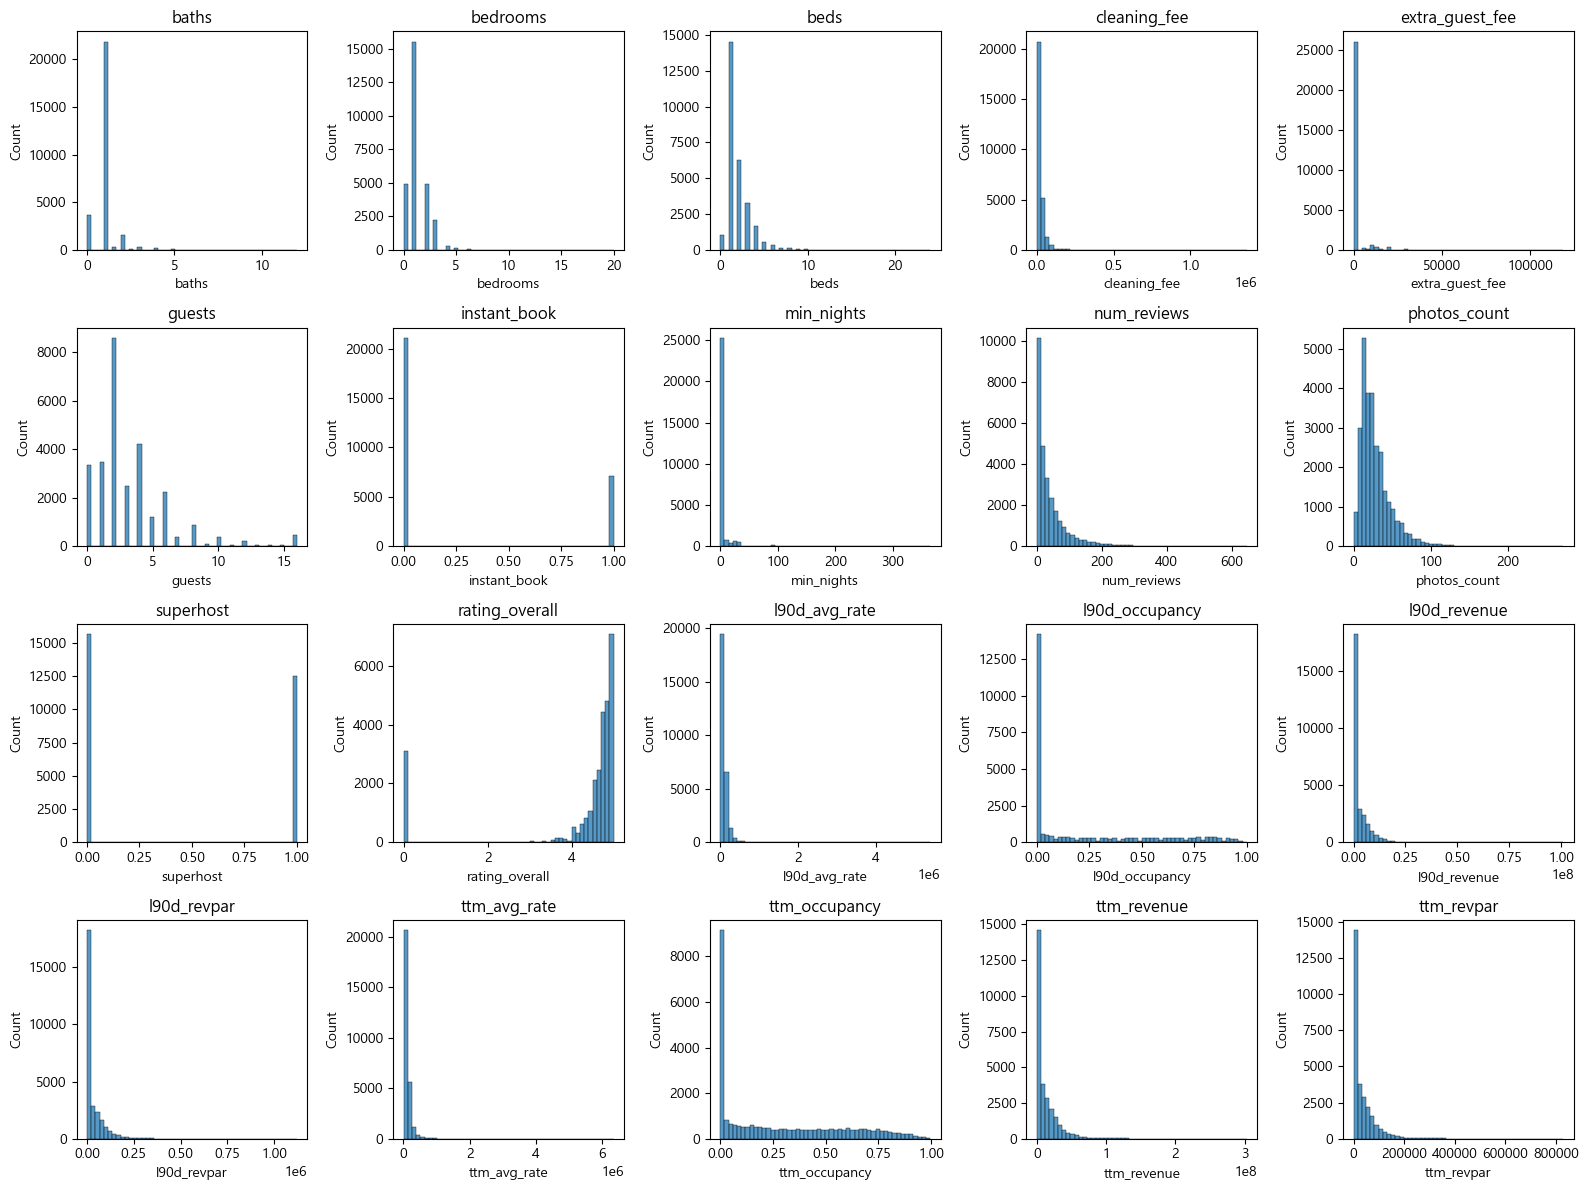

In [ ]:
cols = ['baths', 'bedrooms', 'beds', 'cleaning_fee',
        'extra_guest_fee', 'guests', 'instant_book', 'min_nights',
        'num_reviews', 'photos_count', 'superhost', 'rating_overall',
        'l90d_avg_rate', 'l90d_occupancy', 'l90d_revenue', 'l90d_revpar',
        'ttm_avg_rate', 'ttm_occupancy', 'ttm_revenue', 'ttm_revpar']

n_cols = 5
n_rows = math.ceil(len(cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3*n_rows))
axes = axes.flatten()  # 2차원 → 1차원으로 변환

for i, col in enumerate(cols):
    sns.histplot(gdf_airbnb[col], bins=50, ax=axes[i])
    axes[i].set_title(col)

# 남는 subplot 제거
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
gdf_active_airbnb = gdf_airbnb[(gdf_airbnb["ttm_revpar"]>0) & (gdf_airbnb["ttm_avg_rate"]>0) & (gdf_airbnb["ttm_occupancy"]>0)].copy()
gdf_active_airbnb = gdf_active_airbnb[(gdf_active_airbnb["ttm_occupancy"]>=0) & (gdf_active_airbnb["ttm_occupancy"]<=1)].copy()
gdf_active_airbnb = gdf_active_airbnb.reset_index()
len(gdf_active_airbnb)

20000

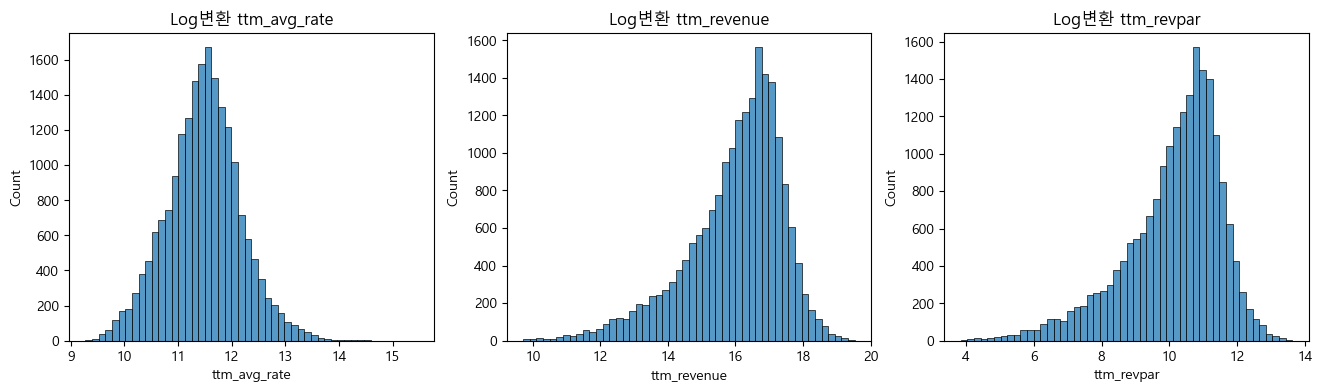

In [ ]:
plt.figure(figsize=(16, 4))

plt.subplot(1,3,1)
sns.histplot(np.log1p(gdf_active_airbnb['ttm_avg_rate']), bins=50)
plt.title("Log변환 ttm_avg_rate")

plt.subplot(1,3,2)
sns.histplot(np.log1p(gdf_active_airbnb['ttm_revenue']), bins=50)
plt.title("Log변환 ttm_revenue")

plt.subplot(1,3,3)
sns.histplot(np.log1p(gdf_active_airbnb['ttm_revpar']), bins=50)
plt.title("Log변환 ttm_revpar")

plt.show()

# 수익성 및 레버 분석
- 매출 0인 데이터 삭제: 해당 데이터의 비중이 30%를 차지해 수익에 영향을 끼치는 레버 특성을 왜곡시킬 수 있음.
- 매출, 객실 요금과 같이 연속 데이터는 로그 스케일 변환: 극단값의 영향력을 줄임.
- 최대값이 정해진 rating_overall, occupancy와 같은 데이터는 로그변환 하지 않음.
- 범주형 데이터는 윈저화: 데이터를 버리지 않으면서, 소수의 튀는 값(이상치)이 전체 분석을 망치는 것을 막기 위함.

In [ ]:
# gdf_airbnb.columns

Index(['baths', 'bedrooms', 'beds', 'cleaning_fee', 'country', 'currency',
       'extra_guest_fee', 'guests', 'instant_book', 'l90d_avg_rate',
       'l90d_occupancy', 'l90d_revenue', 'l90d_revpar', 'listing_type',
       'locality', 'min_nights', 'num_reviews', 'photos_count',
       'rating_overall', 'region', 'room_type', 'superhost', 'ttm_avg_rate',
       'ttm_occupancy', 'ttm_revenue', 'ttm_revpar', 'district', 'X좌표(WGS84)',
       'Y좌표(WGS84)', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)', 'geometry'],
      dtype='object')

In [ ]:
# gdf_active_airbnb = gdf_airbnb[(gdf_airbnb["ttm_revpar"]>0) & (gdf_airbnb["ttm_avg_rate"]>0) & (gdf_airbnb["ttm_occupancy"]>0)].copy()
# gdf_active_airbnb = gdf_active_airbnb[(gdf_active_airbnb["ttm_occupancy"]>=0) & (gdf_active_airbnb["ttm_occupancy"]<=1)].copy()
# gdf_active_airbnb = gdf_active_airbnb.reset_index()
# len(gdf_active_airbnb)

20000

In [ ]:
# 윈저화 함수 정의
def winsorize(s: pd.Series, lo=0, hi=0.99) -> pd.Series:
    a, b = s.quantile(lo), s.quantile(hi)
    return s.clip(a, b)

gdf_active_airbnb_trans = gdf_active_airbnb.copy()

# 1. 로그 변환 대상 (연속형, 롱테일)
log_target_cols = [
    'cleaning_fee', 'extra_guest_fee', 'num_reviews', 'photos_count',
    'l90d_avg_rate', 'l90d_revenue', 'l90d_revpar',
    'ttm_avg_rate', 'ttm_revenue', 'ttm_revpar'
]

# 2. 윈저화 대상 (이산형/단위가 중요한 변수) + 로그 변환 대상
cap_cols = ['baths', 'bedrooms', 'beds', 'min_nights'] + log_target_cols

# 3. 윈저화 적용 (수정됨: gdf_active_airbnb_log[col] 로 변경)
for col in cap_cols:
    w = winsorize(gdf_active_airbnb_trans[col].astype(float), lo=0, hi=0.99)
    gdf_active_airbnb_trans[f'{col}_w'] = w

# 4. 로그 변환 적용(윈저화 후에 로그변환)
for col in log_target_cols:
    w = winsorize(gdf_active_airbnb_trans[col].astype(float), lo=0, hi=0.99)
    gdf_active_airbnb_trans[f'log_{col}'] = np.log1p(w)

# rating은 0/결측이 "리뷰 없음" 의미일 수 있으므로 flag를 분리
gdf_active_airbnb_trans["rating_missing_flag"] = ((gdf_active_airbnb_trans["rating_overall"].isna()) | (gdf_active_airbnb_trans["rating_overall"]<=0)).astype(int)
gdf_active_airbnb_trans["rating_overall_filled"] = gdf_active_airbnb_trans["rating_overall"].fillna(0)

# 5. 히트맵용 최종 컬럼 리스트
final_num_cols = [
    'baths_w', 'bedrooms_w', 'beds_w', 'min_nights_w', 'guests',
    'instant_book', 'superhost', 'rating_overall',
    'log_cleaning_fee', 'log_num_reviews', 'log_photos_count',
    'l90d_occupancy', 'ttm_occupancy',
    'log_l90d_avg_rate', 'log_l90d_revenue', 'log_l90d_revpar',
    'log_ttm_avg_rate', 'log_ttm_revenue', 'log_ttm_revpar'
]

# 6. 상관관계 계산 (매출 0인 데이터 제외하면 더 정확합니다)
# df_for_corr = gdf_airbnb_log[gdf_airbnb_log['ttm_revpar'] > 0]
airbnb_corr = gdf_active_airbnb_trans[final_num_cols].corr()

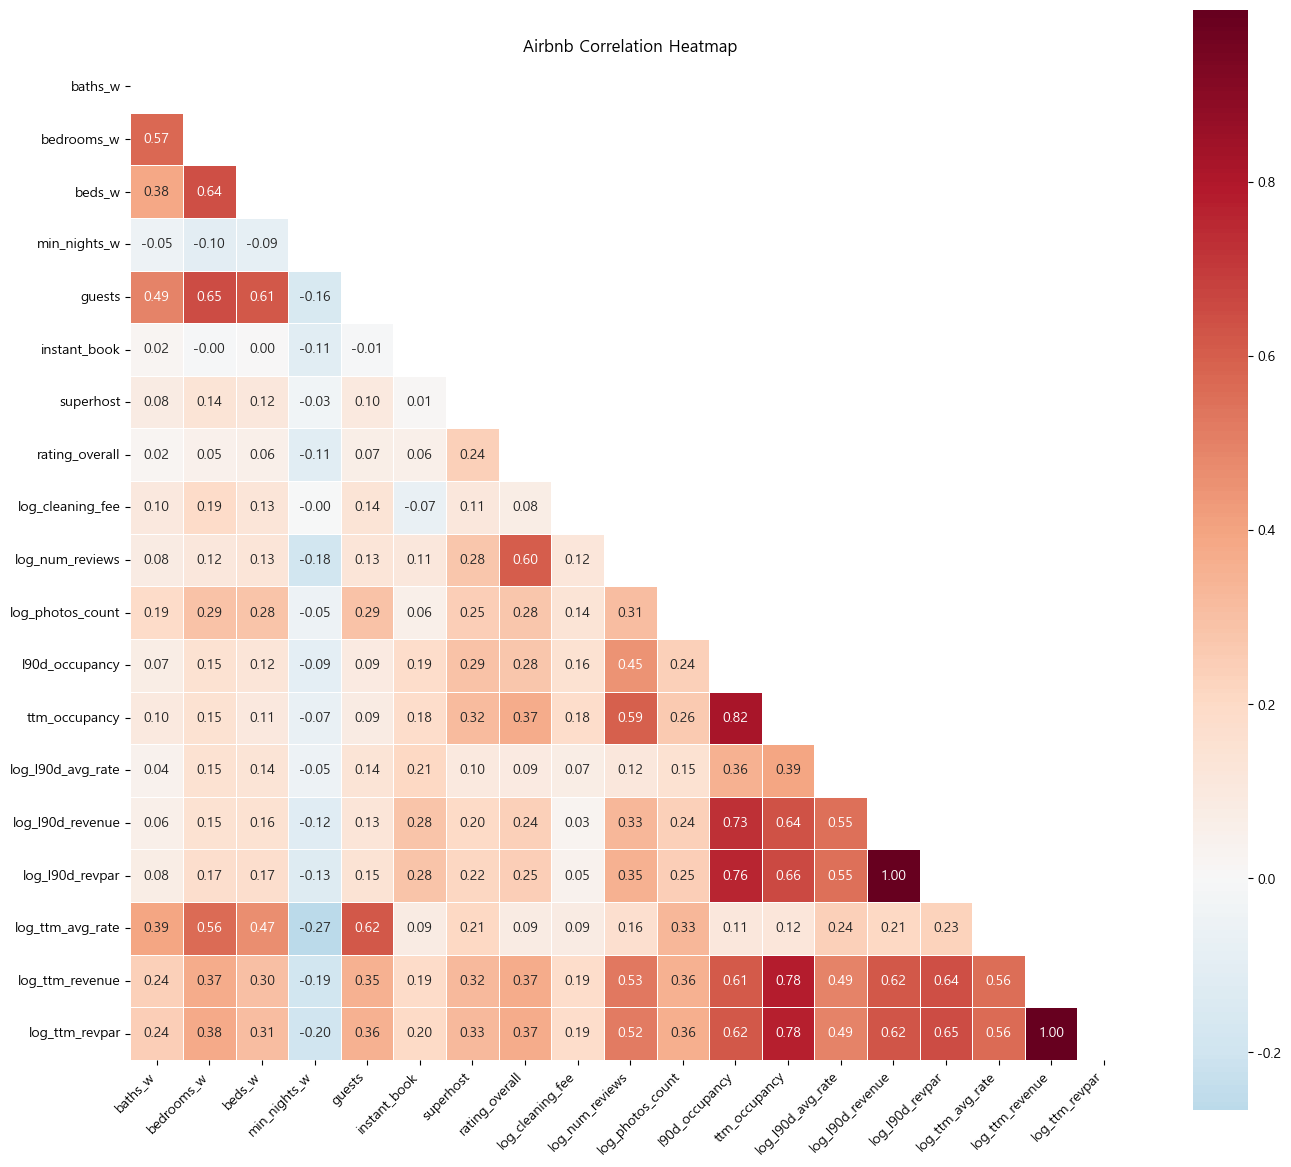

In [ ]:
mask = np.triu(np.ones_like(airbnb_corr, dtype=bool))

plt.figure(figsize=(14, 12))
sns.heatmap(
    airbnb_corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Airbnb Correlation Heatmap")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### 상관관계 인사이트
- 리뷰수 = 0.52로 가장 높은 상관관계
- 사진수, 평점, 슈퍼호스트여부, 최대허용게스트수, 침실수, 침대수가 0.3~0.4 정도의 상관관계를 보임
-> 숙소의 규모에 영향이 있는 요소를 제외한다면 신뢰도 지표가 수익에 가장 큰 요소임을 알 수 있음.

#### 상관관계 인사이트 추가
- 크기를 비교할 수 없는 범주형 데이터인 room type은 박스플롯을 통해 수익과의 관계를 살펴본 결과 entire_home이 가장 좋은 수익 모델로 보여지며 private_room은 hotel_room과 수익성은 비슷하지만 적은 가격으로 높은 점유유을 확보할 수 있다는 점에서 신규 호스팅하기 좋은 모델로 보임.
- 따라서 entire_home과 private_room이 신규 진입을 위한 최적의 room_type임.

#### 전체 숙소 데이터

In [ ]:
room_counts = gdf_active_airbnb.groupby('room_type').size().reset_index(name='count')
room_counts = room_counts.sort_values('count', ascending=False)

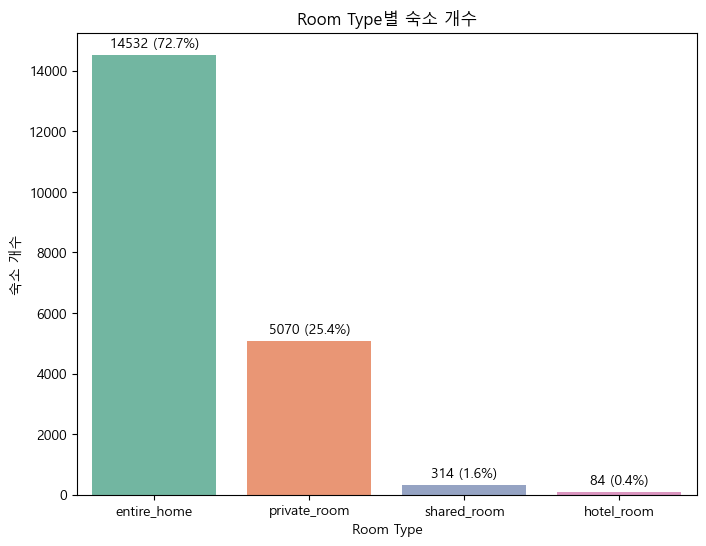

In [ ]:
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    data=room_counts,
    x='room_type',
    y='count',
    palette='Set2'
)

# 전체 합계
total = room_counts['count'].sum()

# 막대 위에 개수 + 퍼센트 표시
for p in ax.patches:
    height = p.get_height()
    percent = height / total * 100

    ax.text(
        p.get_x() + p.get_width()/2,
        height + room_counts['count'].max()*0.01,
        f'{int(height)} ({percent:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Room Type별 숙소 개수')
plt.xlabel('Room Type')
plt.ylabel('숙소 개수')
plt.show()

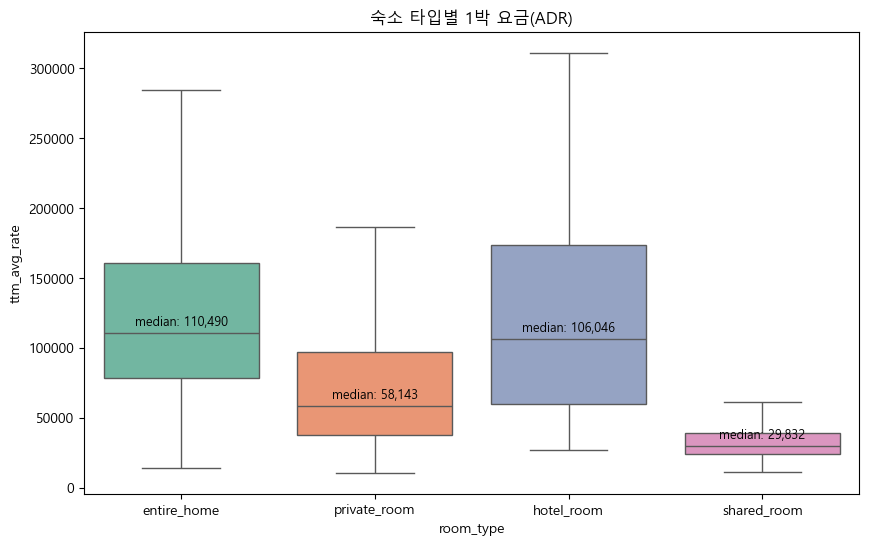

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=gdf_active_airbnb,
    x='room_type',
    y='ttm_avg_rate',
    palette='Set2',
    showfliers=False
)

# 1. 그래프의 X축 순서를 그대로 가져와서 중앙값 계산 (순서 뒤바뀜 방지)
order = [t.get_text() for t in ax.get_xticklabels()]
medians = gdf_active_airbnb.groupby('room_type')['ttm_avg_rate'].median().loc[order]

# 2. 화면에 보이는 Y축 범위를 기준으로 오프셋 설정 (아웃라이어를 제외한 높이 기준)
y_min, y_max = ax.get_ylim()
y_range = y_max - y_min
offset = y_range * 0.01  # 전체 높이의 1%만큼 위로 띄움

# 3. 중앙값 표시
for i, room in enumerate(order):
    median_val = medians[room]

    ax.text(
        i,
        median_val + offset, # 계산된 오프셋 적용
        f'median: {median_val:,.0f}',
        ha='center',
        va='bottom',         # 텍스트의 하단을 기준점으로 설정
        color='black',
        fontsize=9
    )

plt.title('숙소 타입별 1박 요금(ADR)')
plt.show()

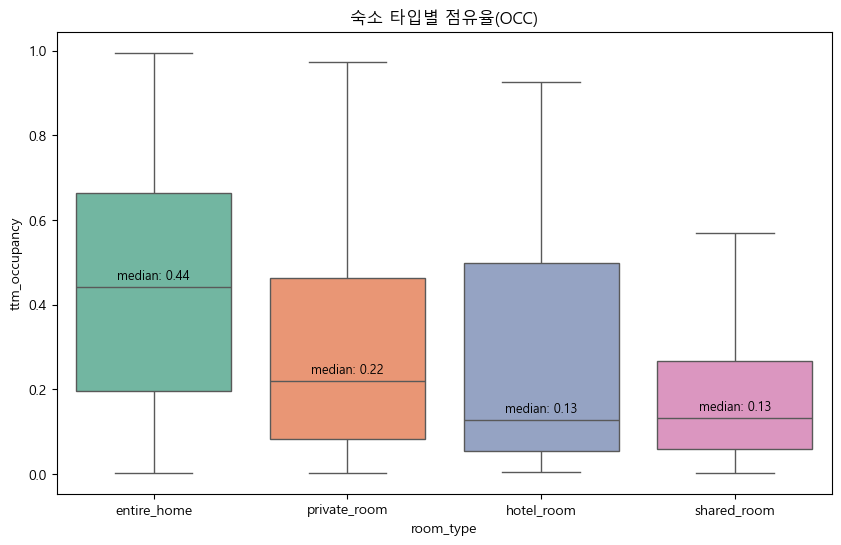

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=gdf_active_airbnb,
    x='room_type',
    y='ttm_occupancy',
    palette='Set2',
    showfliers=False
)

# 1. 그래프의 X축 순서를 그대로 가져와서 중앙값 계산 (순서 뒤바뀜 방지)
order = [t.get_text() for t in ax.get_xticklabels()]
medians = gdf_active_airbnb.groupby('room_type')['ttm_occupancy'].median().loc[order]

# 2. 화면에 보이는 Y축 범위를 기준으로 오프셋 설정 (아웃라이어를 제외한 높이 기준)
y_min, y_max = ax.get_ylim()
y_range = y_max - y_min
offset = y_range * 0.01  # 전체 높이의 1%만큼 위로 띄움

# 3. 중앙값 표시
for i, room in enumerate(order):
    median_val = medians[room]

    ax.text(
        i,
        median_val + offset, # 계산된 오프셋 적용
        f'median: {median_val:,.2f}',
        ha='center',
        va='bottom',         # 텍스트의 하단을 기준점으로 설정
        color='black',
        fontsize=9
    )

plt.title('숙소 타입별 점유율(OCC)')
plt.show()

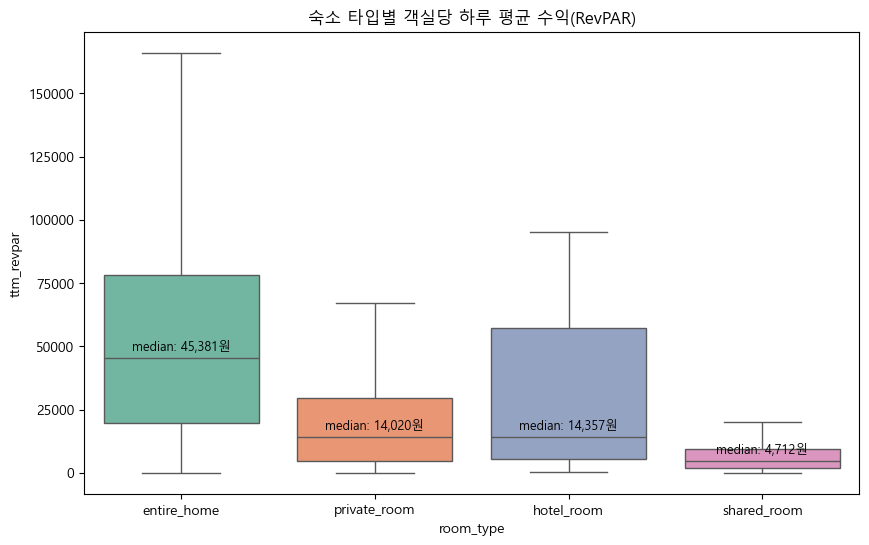

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=gdf_active_airbnb,
    x='room_type',
    y='ttm_revpar',
    palette='Set2',
    showfliers=False
)

# 1. 그래프의 X축 순서를 그대로 가져와서 중앙값 계산 (순서 뒤바뀜 방지)
order = [t.get_text() for t in ax.get_xticklabels()]
medians = gdf_active_airbnb.groupby('room_type')['ttm_revpar'].median().loc[order]

# 2. 화면에 보이는 Y축 범위를 기준으로 오프셋 설정 (아웃라이어를 제외한 높이 기준)
y_min, y_max = ax.get_ylim()
y_range = y_max - y_min
offset = y_range * 0.01  # 전체 높이의 1%만큼 위로 띄움

# 3. 중앙값 표시
for i, room in enumerate(order):
    median_val = medians[room]

    ax.text(
        i,
        median_val + offset, # 계산된 오프셋 적용
        f'median: {median_val:,.0f}원',
        ha='center',
        va='bottom',         # 텍스트의 하단을 기준점으로 설정
        color='black',
        fontsize=9
    )

plt.title('숙소 타입별 객실당 하루 평균 수익(RevPAR)')
plt.show()

전체 숙소 평균 스펙:
  Specification  Average_Value
0         baths           0.98
1      bedrooms           1.27
2          beds           1.94
3        guests           3.34


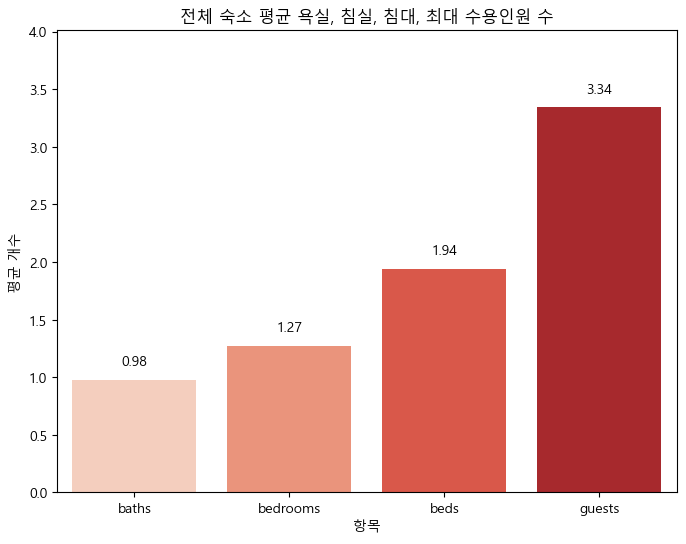

In [ ]:
# 1. 전체 평균 계산 (groupby 제거)
spec_means = (
    gdf_active_airbnb[['baths', 'bedrooms', 'beds', 'guests']]
    .mean()
    .reset_index()
)

# 컬럼명 정리
spec_means.columns = ['Specification', 'Average_Value']

print("전체 숙소 평균 스펙:")
print(spec_means)

# 2. 시각화
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=spec_means,
    x='Specification',
    y='Average_Value',
    palette='Reds'
)

# 3. 막대 위 수치 표시
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + 0.1,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title('전체 숙소 평균 욕실, 침실, 침대, 최대 수용인원 수')
plt.ylabel('평균 개수')
plt.xlabel('항목')
plt.ylim(0, spec_means['Average_Value'].max() * 1.2)
plt.show()

숙소 타입별 평균 스펙:
      room_type  baths  bedrooms  beds  guests
0   entire_home   1.11      1.52  2.11    4.17
1    hotel_room   0.96      0.75  1.89    2.29
2  private_room   0.61      0.62  1.36    1.14
3   shared_room   1.12      0.24  3.30    0.59


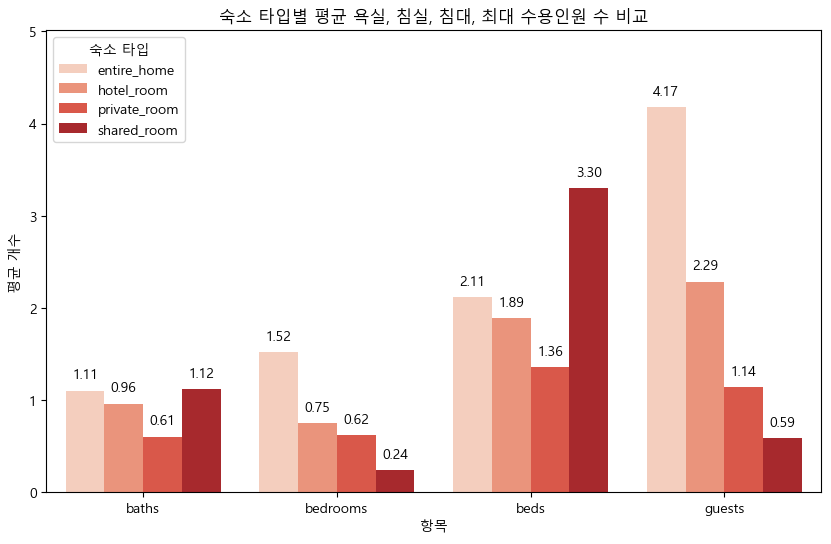

In [ ]:
# 1. room_type별로 그룹화하여 주요 스펙(욕실, 침실, 침대)의 평균 계산
spec_means = gdf_active_airbnb.groupby('room_type')[['baths', 'bedrooms', 'beds', 'guests']].mean().reset_index()

# 2. 결과 수치 출력
print("숙소 타입별 평균 스펙:")
print(spec_means)

# 3. 시각화를 위해 데이터 형태 변환 (Melting)
# 이 과정은 막대 그래프에서 'baths', 'bedrooms', 'beds'를 나란히 보여주기 위해 필요.
melted_specs = spec_means.melt(id_vars='room_type', var_name='Specification', value_name='Average_Value')

# 4. 시각화 (막대 그래프)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=melted_specs,
    x='Specification',
    y='Average_Value',
    hue='room_type',
    palette='Reds'
)

# 5. 막대 위에 실제 수치 표시 (텍스트 라벨링)
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # 0보다 큰 경우에만 표시
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + 0.1,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title('숙소 타입별 평균 욕실, 침실, 침대, 최대 수용인원 수 비교')
plt.ylabel('평균 개수')
plt.xlabel('항목')
plt.ylim(0, melted_specs['Average_Value'].max() * 1.2) # 텍스트 표시 공간 확보
plt.legend(title='숙소 타입')
plt.show()

---

## 숙소 특성(물리적 스펙)과 성과 비교
- guests, bedrooms, beds, baths, room_type
1. 서울지역에서 entire home이 private room 보다 2배 정도의 높은 점유율을 보이며 객실당 평균 수익도 3배 이상의 높은 수익률을 기대할 수 있다.
2. 지난 1년간 가장 좋은 수익과 점유율을 보이는 숙소의 특성을 살펴봄.
- 침대수, 욕실수, 방수는 2개 내외의 방들이 가장 높은 점유율을 보이며 최대 수용 인원은 8인 내외로 설정하는 것이 가장 좋았다.
- 여러 숙소를 운영하는 경우 침대, 욕실 개수 등의 설정을 많게 설정하기에 당연히 개수가 많으면 수익이 높게 나오는 것 처럼 보이는 현상이 있다. 하지만 이는 대규모로 운영하기 때문에 발생하는 현상이기에 기울기를 비교함.
- 기울기가 가파르게 상승하는 지점은 점유율과 같이 2개 내외의 설정값에서 가장 가장 높으며 최대 수용 인원 또한 8명 내외가 가장 높은 수익률을 보임.
3. 최종 결론: 침실, 욕실, 방수는 2개 내외의 숙소 특성에서 가장 높게 나오며 최대 수용인원은 8명이 가장 적당함.

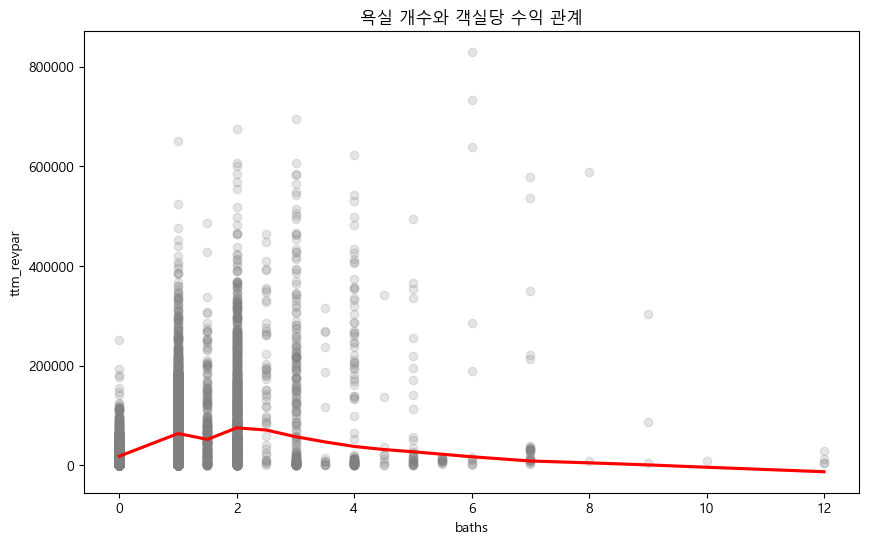

In [ ]:
# lowess=True 옵션 → 데이터의 전체적인 패턴을 부드럽게 그려주는 비선형 회귀 방법
# Lowess 알고리즘은 데이터가 많은 곳의 정보를 더 신뢰
plt.figure(figsize=(10, 6))
sns.regplot(data=gdf_active_airbnb, x='baths', y='ttm_revpar',
            lowess=True,  # 데이터를 부드럽게 이어주는 옵션
            scatter_kws={'alpha':0.2, 'color':'gray'}, # 점은 흐리게
            line_kws={'color':'red'}) # 추세선은 붉게
plt.title("욕실 개수와 객실당 수익 관계")
plt.show()

In [ ]:
import statsmodels.api as sm

def find_optimal_x(category, x, y, frac=0.66):
    """
    LOWESS 기반으로 최고점 x값(최적 x)을 찾는 함수

    Parameters
    ----------
    x : array-like
        독립 변수 (예: 욕실 수)
    y : array-like
        종속 변수 (예: 수익)
    frac : float, optional
        LOWESS 매끄럽기 정도 (기본값 0.66)

    Returns
    -------
    peak_x : float
        추세선이 최고점을 찍는 x값
    """
    # LOWESS 계산
    lowess_values = sm.nonparametric.lowess(y, x, frac=frac)

    # x, y 분리
    lowess_x = lowess_values[:, 0]
    lowess_y = lowess_values[:, 1]

    # 최고점 인덱스
    peak_idx = np.argmax(lowess_y)

    # 최고점 x값 반환
    peak_x = lowess_x[peak_idx]

    return print(f"최적 {category}: {peak_x:.1f}")

In [ ]:
x = gdf_active_airbnb['baths']
y = gdf_active_airbnb['ttm_revpar']

find_optimal_x('baths', x, y)

최적 baths: 2.0


In [ ]:
# 1. 그룹별 통계 계산
bath_stats = gdf_active_airbnb.groupby('baths')['ttm_revpar'].agg(['mean', 'count'])

# 2. 데이터가 최소 10개 이상인 그룹 중에서만 최적점 찾기
min_sample_size = 0
reliable_stats = bath_stats[bath_stats['count'] >= min_sample_size]
reliable_stats
# if not reliable_stats.empty:
#     best_bath = reliable_stats['mean'].idxmax()
#     print(f"신뢰할 수 있는 최적의 욕실 개수 (N>={min_sample_size}): {best_bath}개")
# else:
#     print("충분한 표본을 가진 그룹이 없습니다.")

,mean,count
baths,,
0.00,19336.76,3001
1.00,47668.61,15134
1.50,75788.50,276
2.00,111199.89,1143
2.50,183386.28,49
3.00,150698.82,192
3.50,102794.79,14
4.00,144835.09,90
4.50,64263.03,9


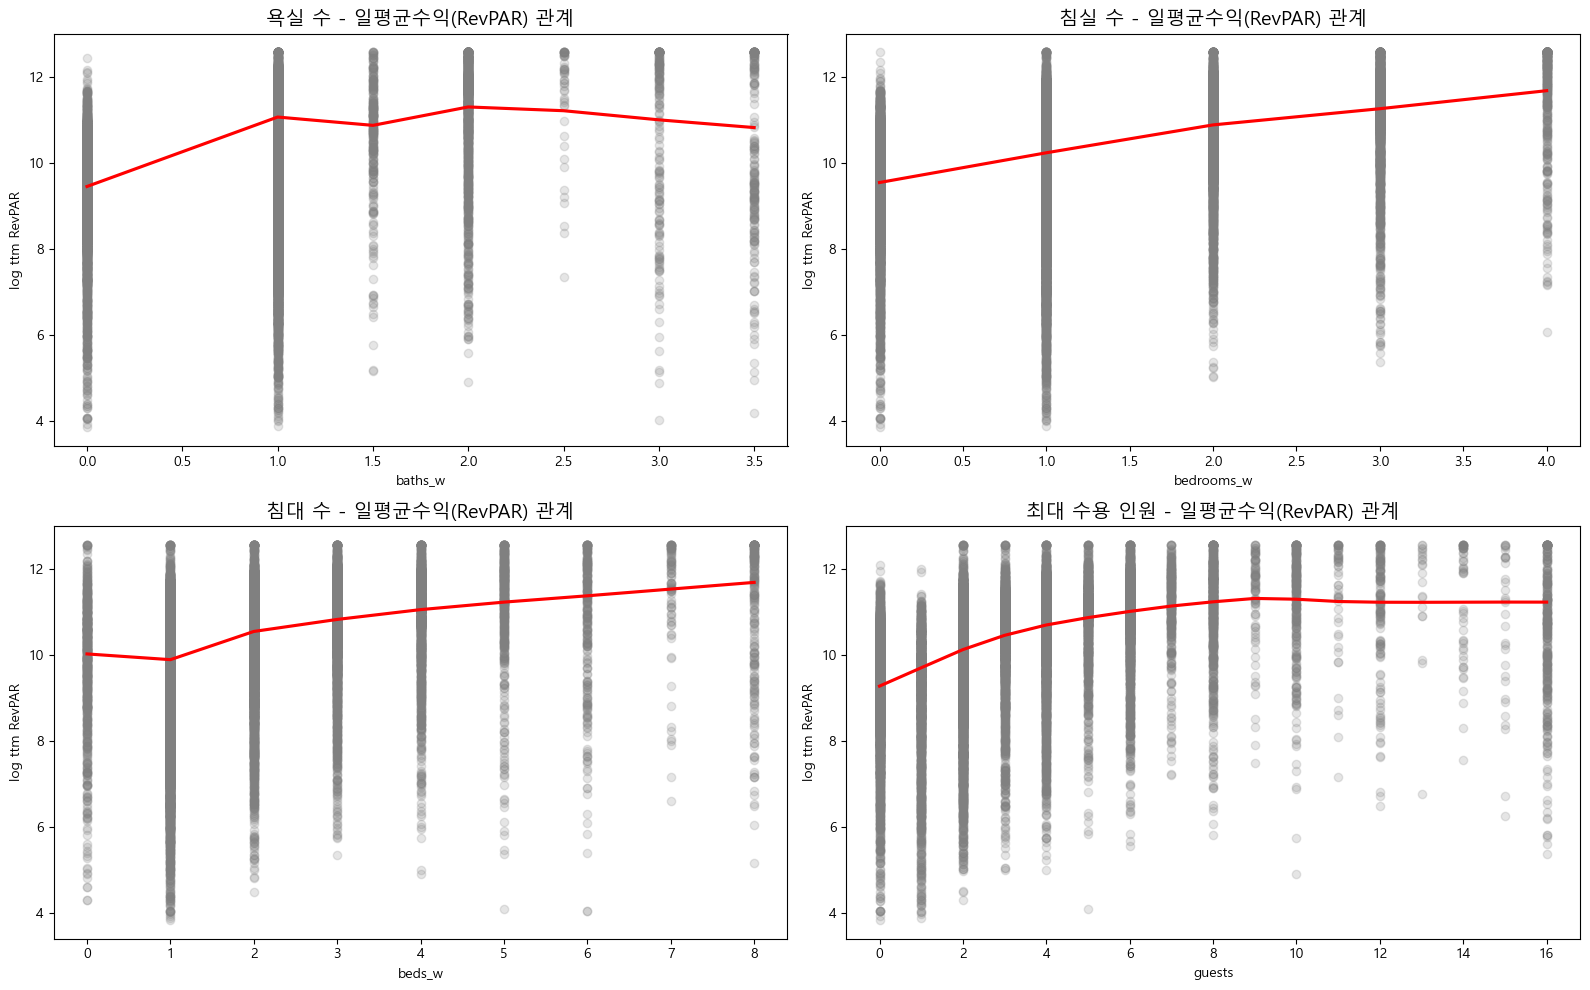

In [ ]:
import math

# 분석할 주요 수치형 컬럼 리스트
features = ['baths_w', 'bedrooms_w', 'beds_w','guests']

# 그래프 레이아웃 설정 (3열로 구성)
n_cols = 2
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()

feature_names_kr = {
    'baths_w': '욕실 수',
    'bedrooms_w': '침실 수',
    'beds_w': '침대 수',
    'guests': '최대 수용 인원'
}

for i, col in enumerate(features):
    # 각 서브플롯에 regplot 그리기
    sns.regplot(
        data=gdf_active_airbnb_trans,
        x=col,
        y='log_ttm_revpar',
        lowess=True,
        scatter_kws={'alpha':0.2, 'color':'gray'},
        line_kws={'color':'red'},
        ax=axes[i]
    )
    axes[i].set_title(f'{feature_names_kr[col]} - 일평균수익(RevPAR) 관계', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log ttm RevPAR')

# 남는 빈 그래프 공간 삭제
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

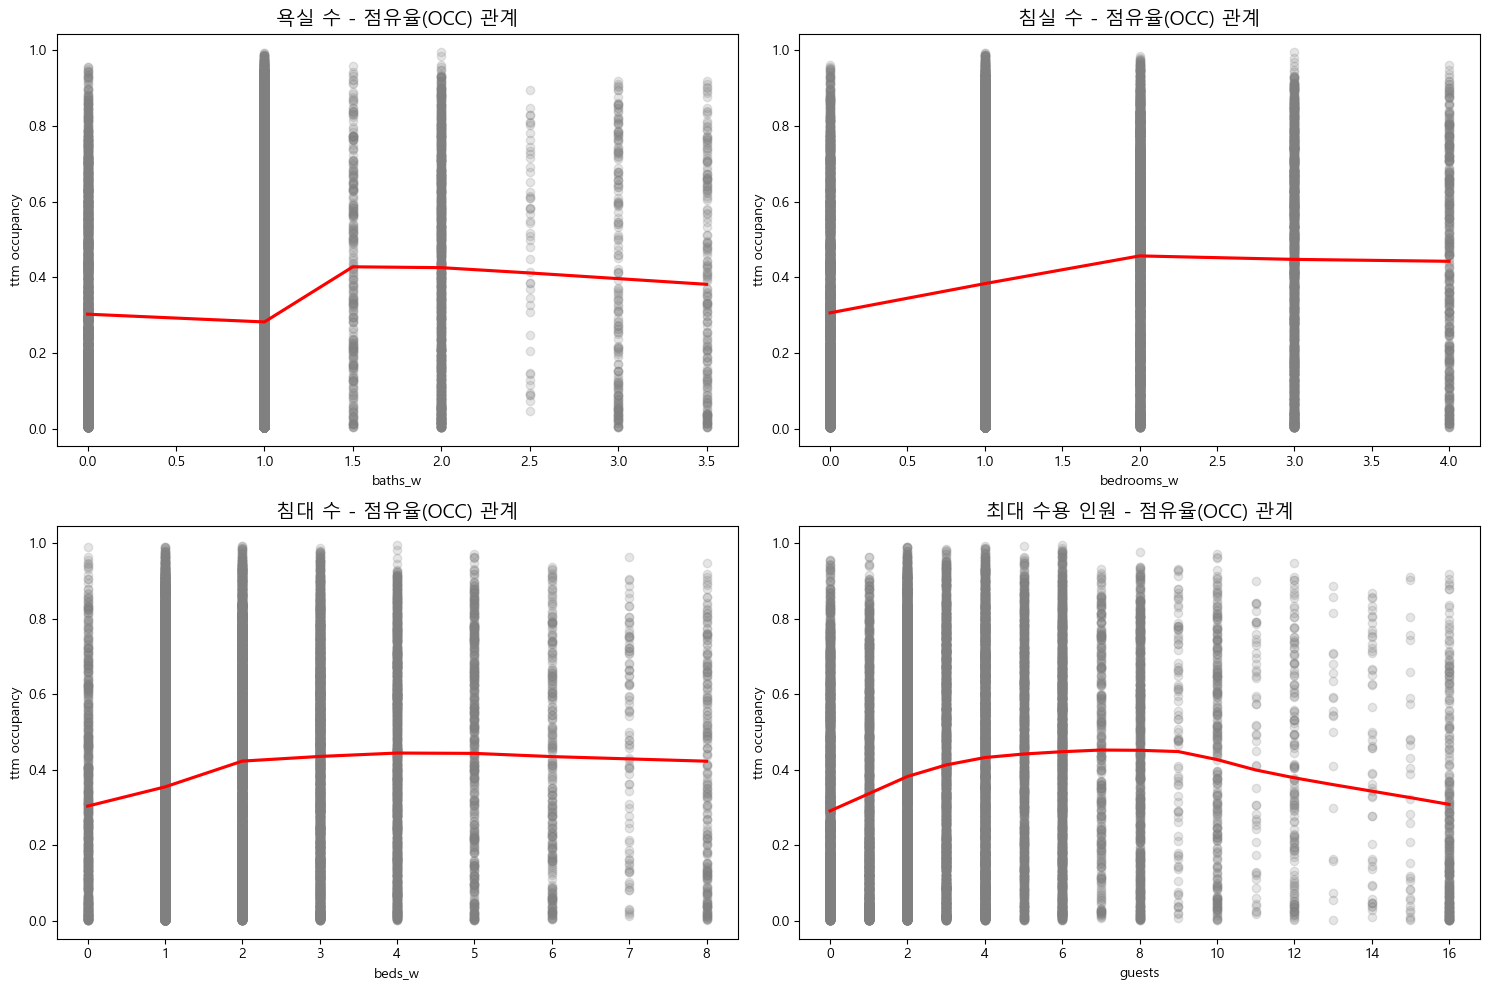

In [ ]:
# 분석할 주요 수치형 컬럼 리스트
features = ['baths_w', 'bedrooms_w', 'beds_w','guests']

# 그래프 레이아웃 설정 (3열로 구성)
n_cols = 2
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

feature_names_kr = {
    'baths_w': '욕실 수',
    'bedrooms_w': '침실 수',
    'beds_w': '침대 수',
    'guests': '최대 수용 인원'
}

for i, col in enumerate(features):
    # 각 서브플롯에 regplot 그리기
    sns.regplot(
        data=gdf_active_airbnb_trans,
        x=col,
        y='ttm_occupancy',
        lowess=True,
        scatter_kws={'alpha':0.2, 'color':'gray'},
        line_kws={'color':'red'},
        ax=axes[i]
    )
    axes[i].set_title(f'{feature_names_kr[col]} - 점유율(OCC) 관계', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('ttm occupancy')

# 남는 빈 그래프 공간 삭제
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

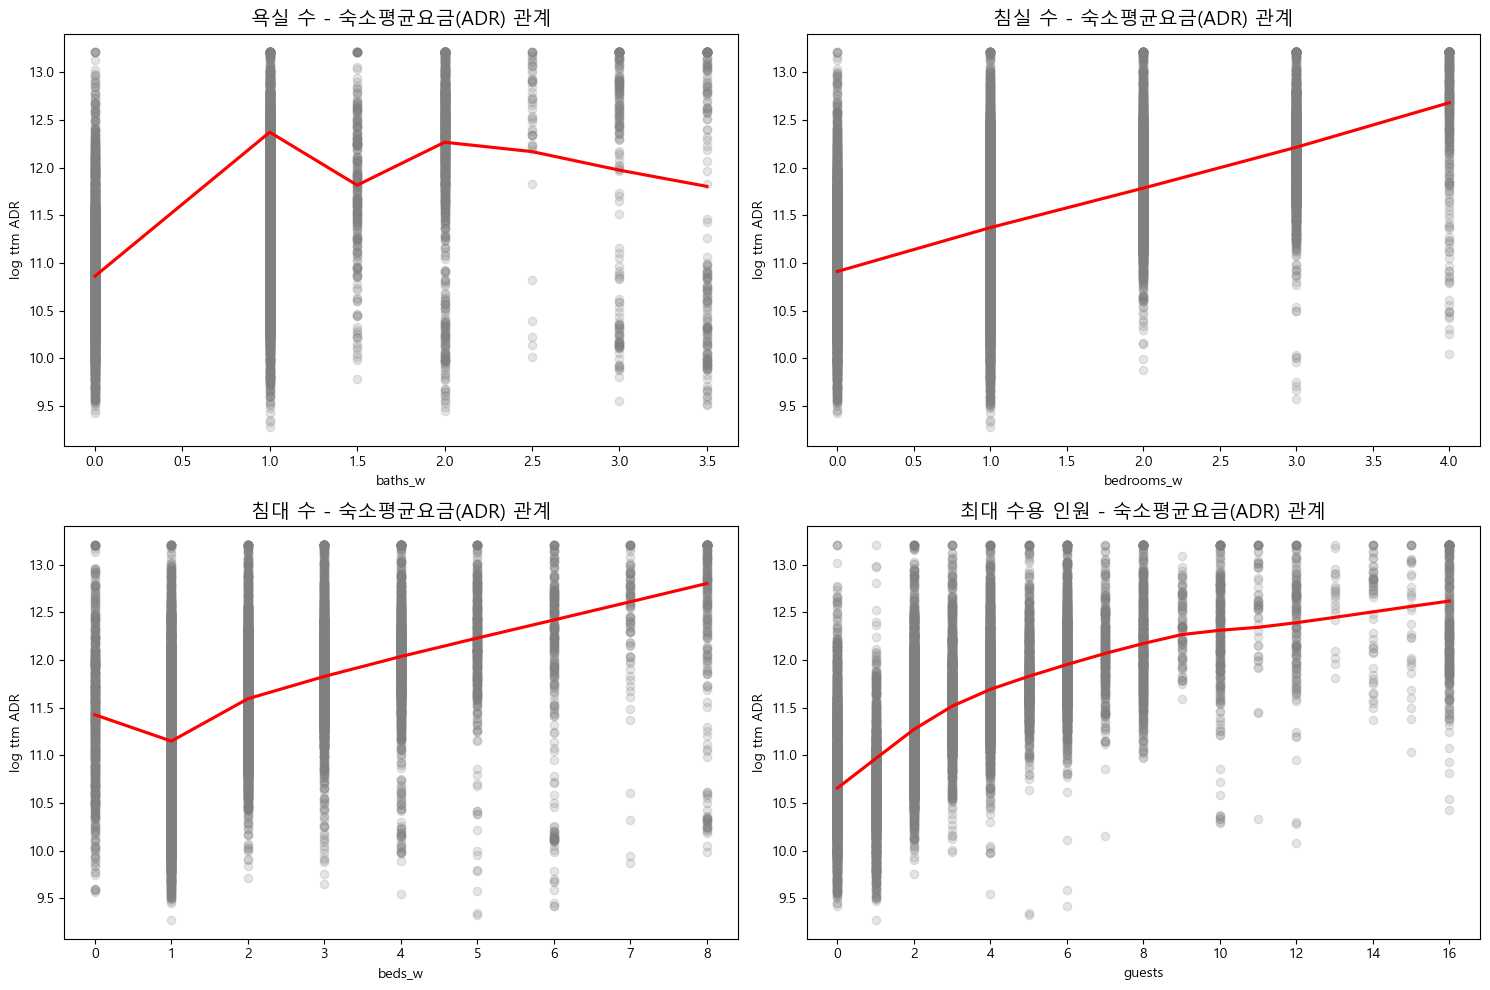

In [ ]:
# 분석할 주요 수치형 컬럼 리스트
features = ['baths_w', 'bedrooms_w', 'beds_w','guests']

# 그래프 레이아웃 설정 (3열로 구성)
n_cols = 2
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

feature_names_kr = {
    'baths_w': '욕실 수',
    'bedrooms_w': '침실 수',
    'beds_w': '침대 수',
    'guests': '최대 수용 인원'
}

for i, col in enumerate(features):
    # 각 서브플롯에 regplot 그리기
    sns.regplot(
        data=gdf_active_airbnb_trans,
        x=col,
        y='log_ttm_avg_rate',
        lowess=True,
        scatter_kws={'alpha':0.2, 'color':'gray'},
        line_kws={'color':'red'},
        ax=axes[i]
    )
    axes[i].set_title(f'{feature_names_kr[col]} - 숙소평균요금(ADR) 관계', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log ttm ADR')

# 남는 빈 그래프 공간 삭제
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

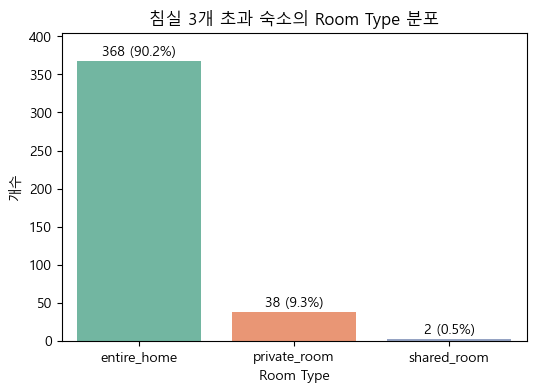

In [ ]:
# 3개 초과 침실 숙소 데이터
bedroom_gt3_counts = gdf_active_airbnb_trans[gdf_active_airbnb_trans['bedrooms'] > 3]['room_type'].value_counts()
bedroom_gt3_ratio = gdf_active_airbnb_trans[gdf_active_airbnb_trans['bedrooms'] > 3]['room_type'].value_counts(normalize=True) * 100

# 그래프 그리기
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=bedroom_gt3_counts.index, y=bedroom_gt3_counts.values, palette='Set2')

# 막대 위에 개수 + 퍼센트 표시
y_offset = bedroom_gt3_counts.max() * 0.01
for i, p in enumerate(ax.patches):
    height = p.get_height()
    room_type = bedroom_gt3_counts.index[i]
    ratio = bedroom_gt3_ratio[room_type]
    ax.text(
        p.get_x() + p.get_width()/2,
        height + y_offset,
        f'{int(height)} ({ratio:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.ylim(0, bedroom_gt3_counts.max() * 1.1)
plt.title('침실 3개 초과 숙소의 Room Type 분포')
plt.ylabel('개수')
plt.xlabel('Room Type')
plt.show()

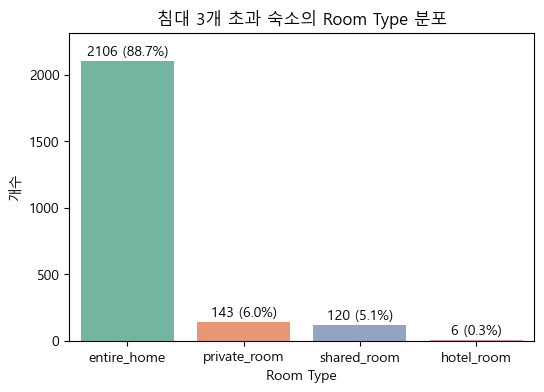

In [ ]:
# 3개 초과 침대 숙소 데이터
bed_gt3_counts = gdf_active_airbnb_trans[gdf_active_airbnb_trans['beds'] > 3]['room_type'].value_counts()
bed_gt3_ratio = gdf_active_airbnb_trans[gdf_active_airbnb_trans['beds'] > 3]['room_type'].value_counts(normalize=True) * 100

# 그래프 그리기
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=bed_gt3_counts.index, y=bed_gt3_counts.values, palette='Set2')

# 막대 위에 개수 + 퍼센트 표시
y_offset = bed_gt3_counts.max() * 0.01
for i, p in enumerate(ax.patches):
    height = p.get_height()
    room_type = bed_gt3_counts.index[i]
    ratio = bed_gt3_ratio[room_type]
    ax.text(
        p.get_x() + p.get_width()/2,
        height + y_offset,
        f'{int(height)} ({ratio:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.ylim(0, bed_gt3_counts.max() * 1.1)
plt.title('침대 3개 초과 숙소의 Room Type 분포')
plt.ylabel('개수')
plt.xlabel('Room Type')
plt.show()

# 리뷰 및 신뢰도와 숙소 성과 비교
- 점유율과 객실 수익을 안정적으로 가져가기 위해서 필요한 노력
- 리뷰 개수: 100개, 최소 사진수: 30개, 평점: 4.9점 내외까지 확보하는 노력이 필요하다.

In [ ]:
gdf_active_airbnb_trans.columns

Index(['index', 'baths', 'bedrooms', 'beds', 'cleaning_fee', 'country',
       'currency', 'extra_guest_fee', 'guests', 'instant_book',
       'l90d_avg_rate', 'l90d_occupancy', 'l90d_revenue', 'l90d_revpar',
       'listing_type', 'locality', 'min_nights', 'num_reviews', 'photos_count',
       'rating_overall', 'region', 'room_type', 'superhost', 'ttm_avg_rate',
       'ttm_occupancy', 'ttm_revenue', 'ttm_revpar', 'district', 'X좌표(WGS84)',
       'Y좌표(WGS84)', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)', 'geometry', 'baths_w',
       'bedrooms_w', 'beds_w', 'min_nights_w', 'cleaning_fee_w',
       'extra_guest_fee_w', 'num_reviews_w', 'photos_count_w',
       'l90d_avg_rate_w', 'l90d_revenue_w', 'l90d_revpar_w', 'ttm_avg_rate_w',
       'ttm_revenue_w', 'ttm_revpar_w', 'log_cleaning_fee',
       'log_extra_guest_fee', 'log_num_reviews', 'log_photos_count',
       'log_l90d_avg_rate', 'log_l90d_revenue', 'log_l90d_revpar',
       'log_ttm_avg_rate', 'log_ttm_revenue', 'log_ttm_revpar',
       'rati

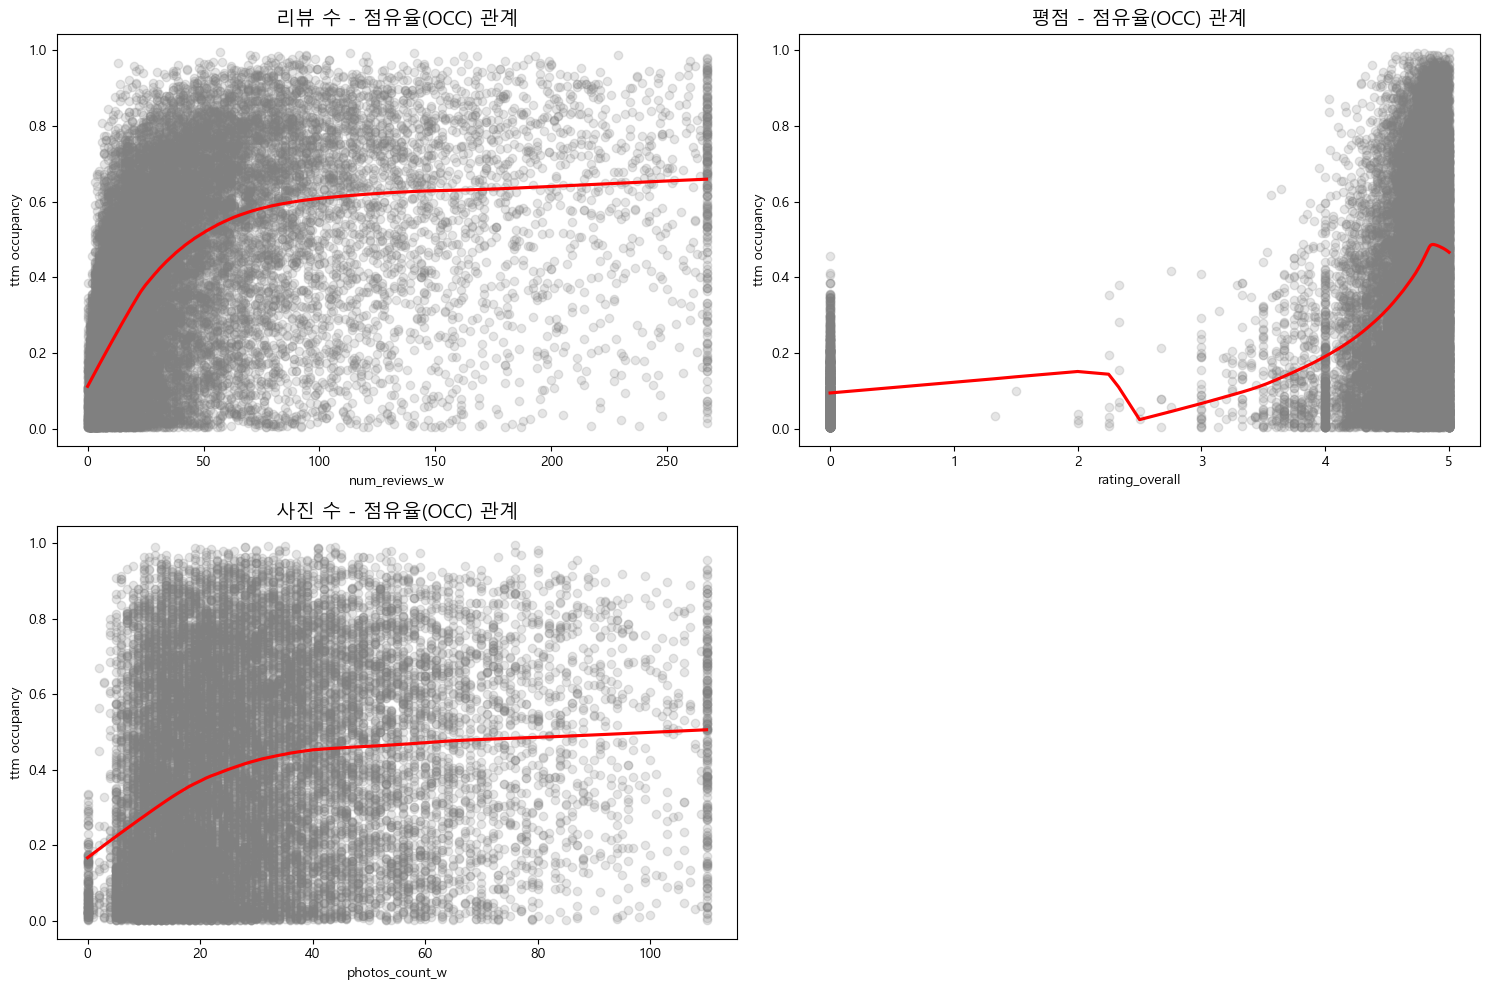

In [ ]:
# 분석할 주요 수치형 컬럼 리스트
features = ['num_reviews_w', 'rating_overall', 'photos_count_w']

# 그래프 레이아웃 설정 (3열로 구성)
n_cols = 2
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

feature_names_kr = {
    'num_reviews_w': '리뷰 수',
    'rating_overall': '평점',
    'photos_count_w': '사진 수'
}

for i, col in enumerate(features):
    # 각 서브플롯에 regplot 그리기
    sns.regplot(
        data=gdf_active_airbnb_trans,
        x=col,
        y='ttm_occupancy',
        lowess=True,
        scatter_kws={'alpha':0.2, 'color':'gray'},
        line_kws={'color':'red'},
        ax=axes[i]
    )
    axes[i].set_title(f'{feature_names_kr[col]} - 점유율(OCC) 관계', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('ttm occupancy')

# 남는 빈 그래프 공간 삭제
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
x = gdf_active_airbnb_trans['rating_overall']
y = gdf_active_airbnb_trans['ttm_occupancy']

find_optimal_x('숙소 평점', x, y)

최적 숙소 평점: 4.9


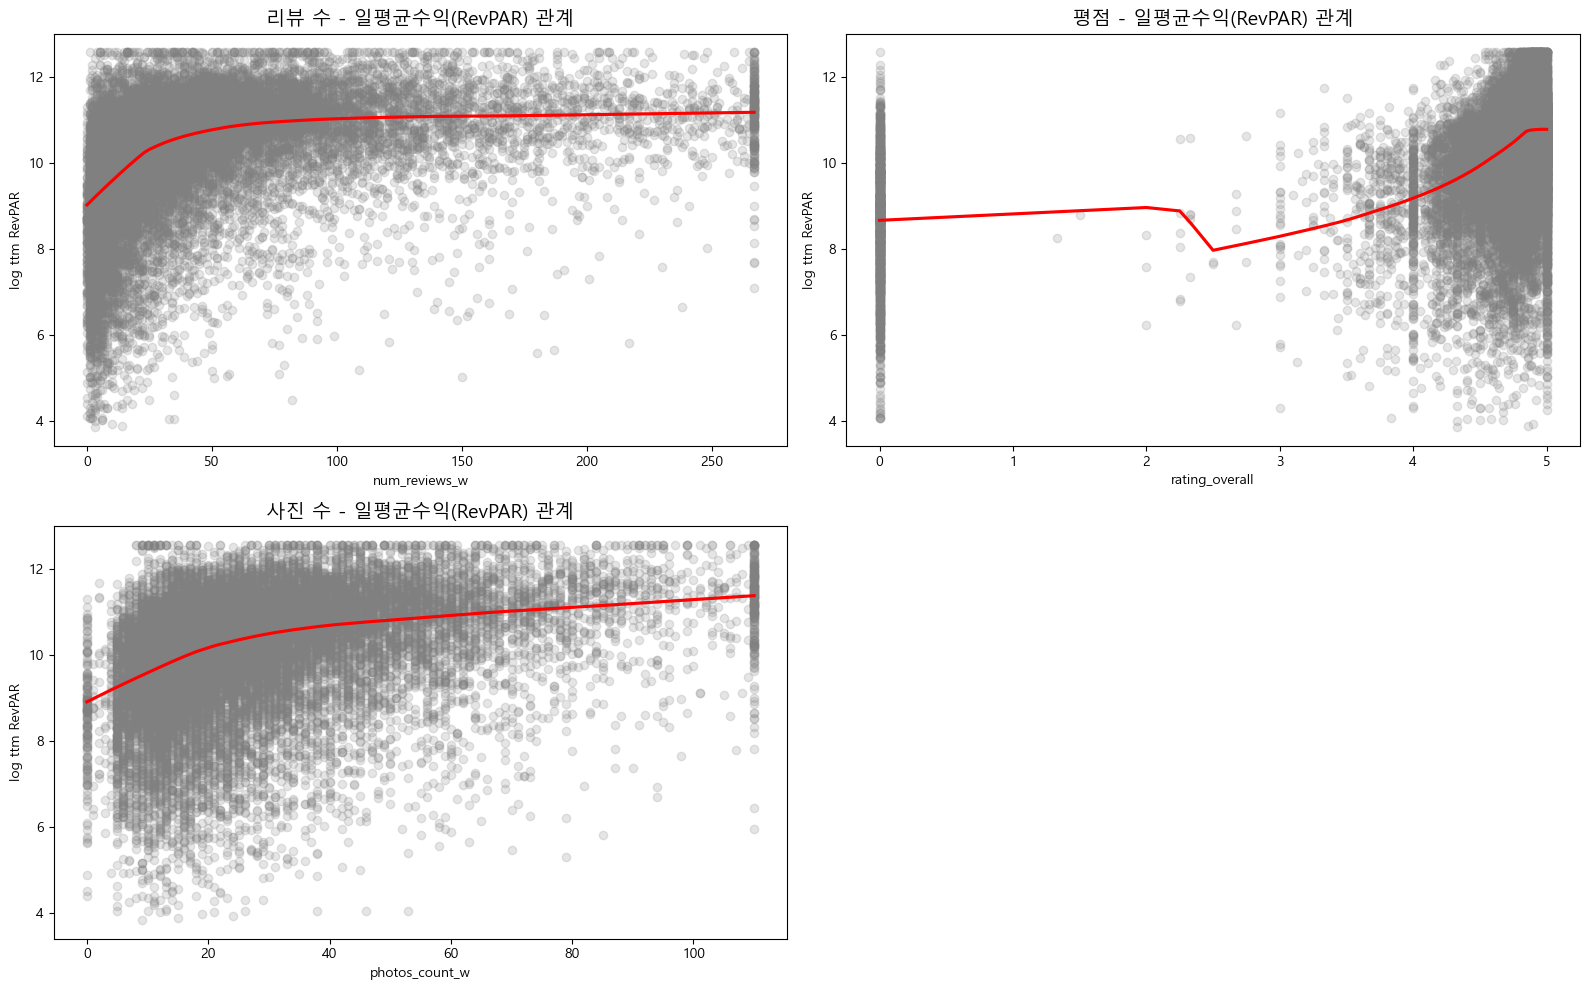

In [ ]:
# 분석할 주요 수치형 컬럼 리스트
features = ['num_reviews_w', 'rating_overall', 'photos_count_w']

# 그래프 레이아웃 설정 (3열로 구성)
n_cols = 2
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()

feature_names_kr = {
    'num_reviews_w': '리뷰 수',
    'rating_overall': '평점',
    'photos_count_w': '사진 수'
}

for i, col in enumerate(features):
    # 각 서브플롯에 regplot 그리기
    sns.regplot(
        data=gdf_active_airbnb_trans,
        x=col,
        y='log_ttm_revpar',
        lowess=True,
        scatter_kws={'alpha':0.2, 'color':'gray'},
        line_kws={'color':'red'},
        ax=axes[i]
    )
    axes[i].set_title(f'{feature_names_kr[col]} - 일평균수익(RevPAR) 관계', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log ttm RevPAR')

# 남는 빈 그래프 공간 삭제
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

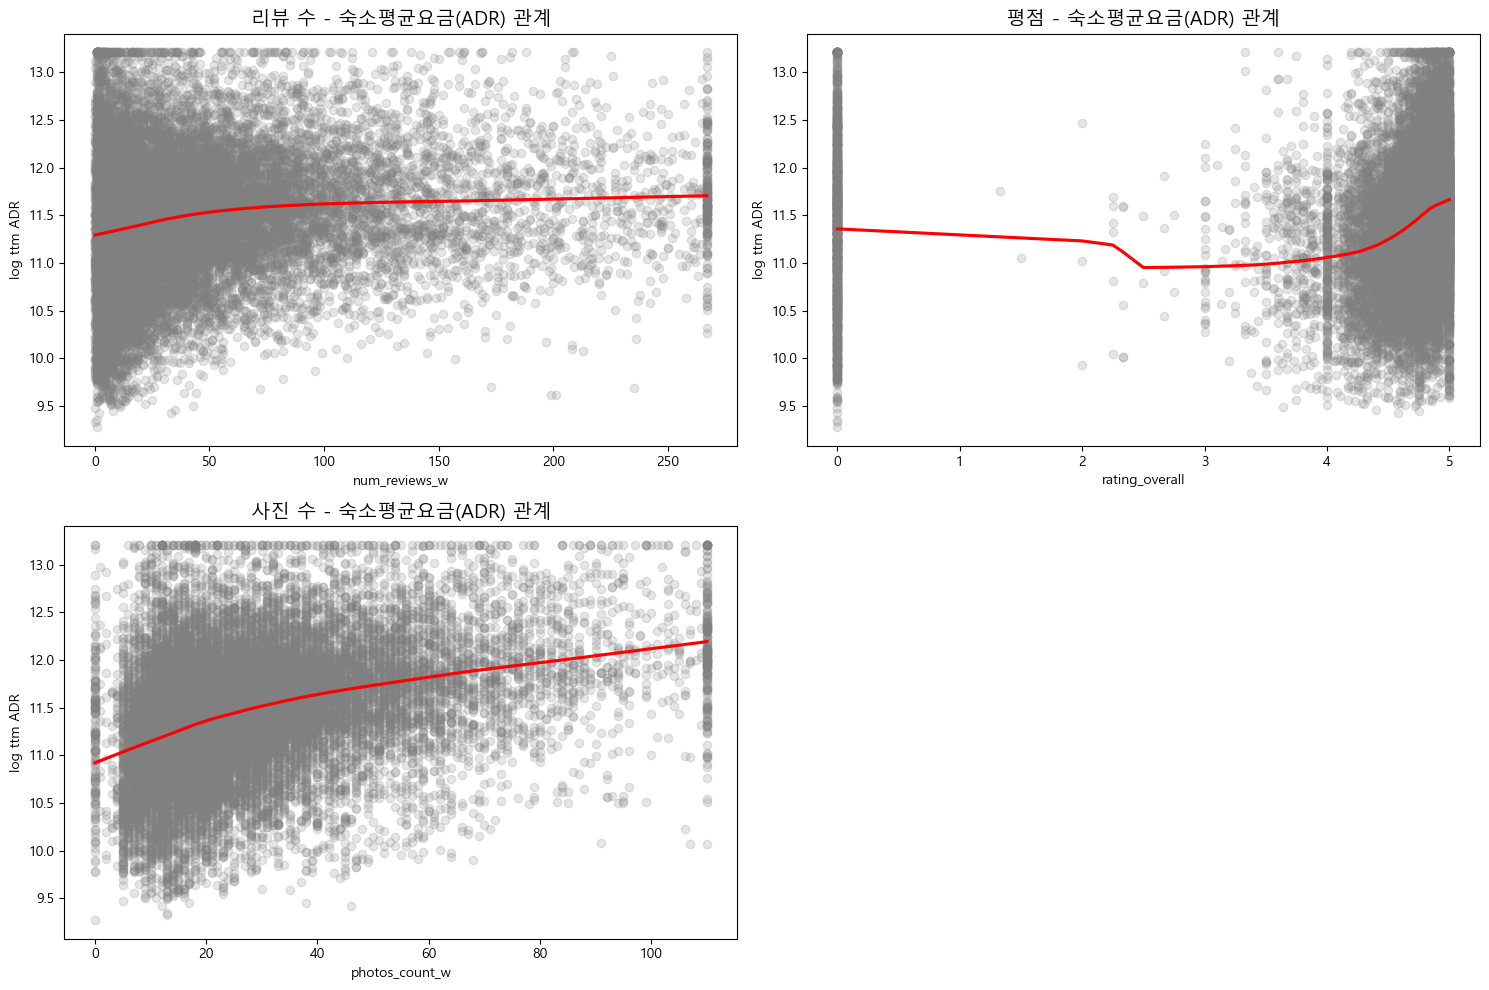

In [ ]:
# 분석할 주요 수치형 컬럼 리스트
features = ['num_reviews_w', 'rating_overall', 'photos_count_w']

# 그래프 레이아웃 설정 (3열로 구성)
n_cols = 2
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

feature_names_kr = {
    'num_reviews_w': '리뷰 수',
    'rating_overall': '평점',
    'photos_count_w': '사진 수'
}

for i, col in enumerate(features):
    # 각 서브플롯에 regplot 그리기
    sns.regplot(
        data=gdf_active_airbnb_trans,
        x=col,
        y='log_ttm_avg_rate',
        lowess=True,
        scatter_kws={'alpha':0.2, 'color':'gray'},
        line_kws={'color':'red'},
        ax=axes[i]
    )
    axes[i].set_title(f'{feature_names_kr[col]} - 숙소평균요금(ADR) 관계', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log ttm ADR')

# 남는 빈 그래프 공간 삭제
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# 운영 전략과 성과 관계
- 슈퍼호스트 여부는 성과와 이어짐.
- 즉시 예약의 경우 일부 높은 수익을 보이는 숙소는 못하게 했지만 평균적으로 설정하는 것이 좋음. → 프리미엄 숙소라면 즉시예약 해제
- 최소 숙박수는 4~5일 정도의 설정이 가장 좋은 운영 전략으로 판단됨.

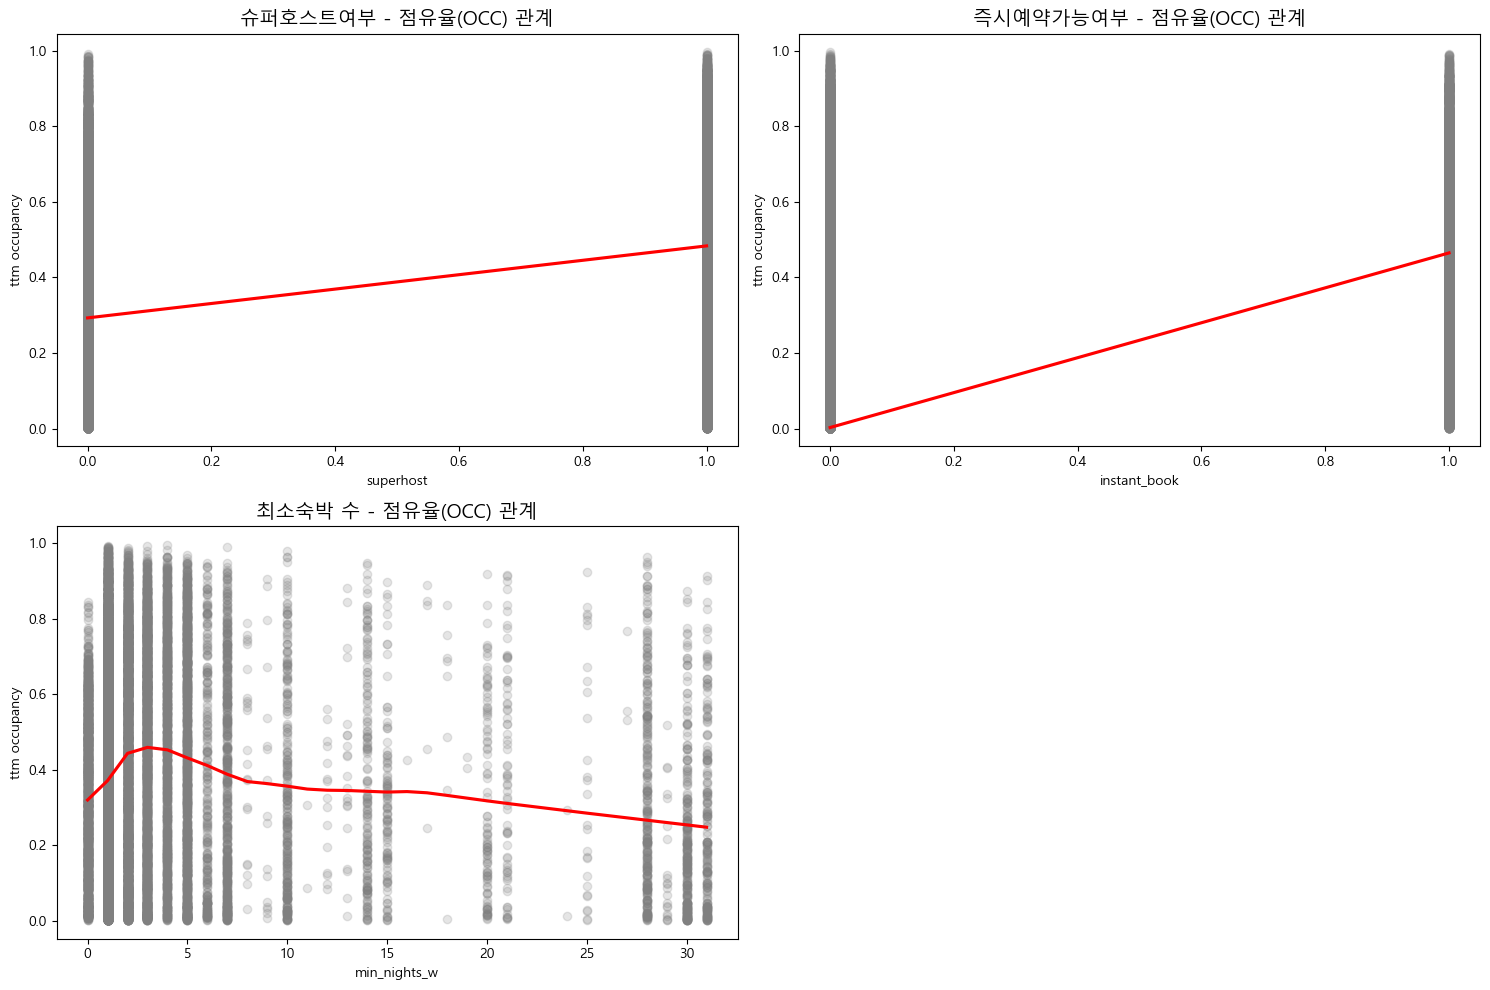

In [ ]:
# 분석할 주요 수치형 컬럼 리스트
features = ['superhost', 'instant_book', 'min_nights_w']

# 그래프 레이아웃 설정 (3열로 구성)
n_cols = 2
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

feature_names_kr = {
    'superhost': '슈퍼호스트여부',
    'instant_book': '즉시예약가능여부',
    'min_nights_w': '최소숙박 수'
}

for i, col in enumerate(features):
    # 각 서브플롯에 regplot 그리기
    sns.regplot(
        data=gdf_active_airbnb_trans,
        x=col,
        y='ttm_occupancy',
        lowess=True,
        scatter_kws={'alpha':0.2, 'color':'gray'},
        line_kws={'color':'red'},
        ax=axes[i]
    )
    axes[i].set_title(f'{feature_names_kr[col]} - 점유율(OCC) 관계', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('ttm occupancy')

# 남는 빈 그래프 공간 삭제
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

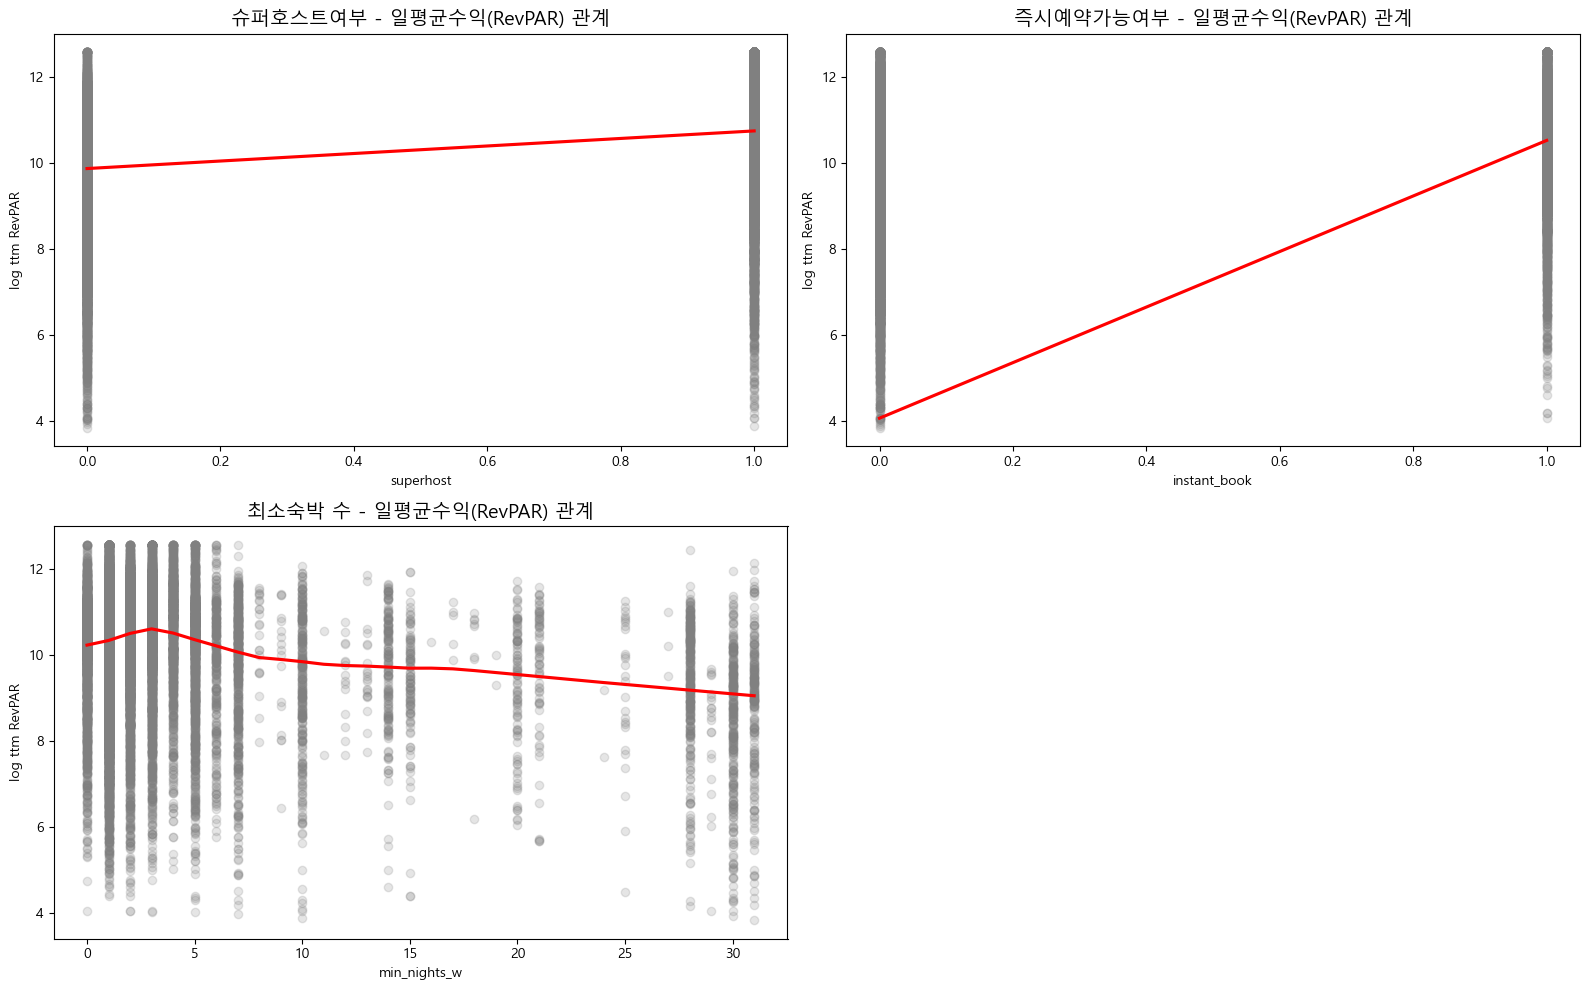

In [ ]:
# 분석할 주요 수치형 컬럼 리스트
features = ['superhost', 'instant_book', 'min_nights_w']

# 그래프 레이아웃 설정 (3열로 구성)
n_cols = 2
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 5))
axes = axes.flatten()

feature_names_kr = {
    'superhost': '슈퍼호스트여부',
    'instant_book': '즉시예약가능여부',
    'min_nights_w': '최소숙박 수'
}

for i, col in enumerate(features):
    # 각 서브플롯에 regplot 그리기
    sns.regplot(
        data=gdf_active_airbnb_trans,
        x=col,
        y='log_ttm_revpar',
        lowess=True,
        scatter_kws={'alpha':0.2, 'color':'gray'},
        line_kws={'color':'red'},
        ax=axes[i]
    )
    axes[i].set_title(f'{feature_names_kr[col]} - 일평균수익(RevPAR) 관계', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log ttm RevPAR')

# 남는 빈 그래프 공간 삭제
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
x = gdf_active_airbnb_trans['min_nights_w']
y = gdf_active_airbnb_trans['log_ttm_revpar']

find_optimal_x('최소숙박', x, y)

최적 최소숙박: 3.0


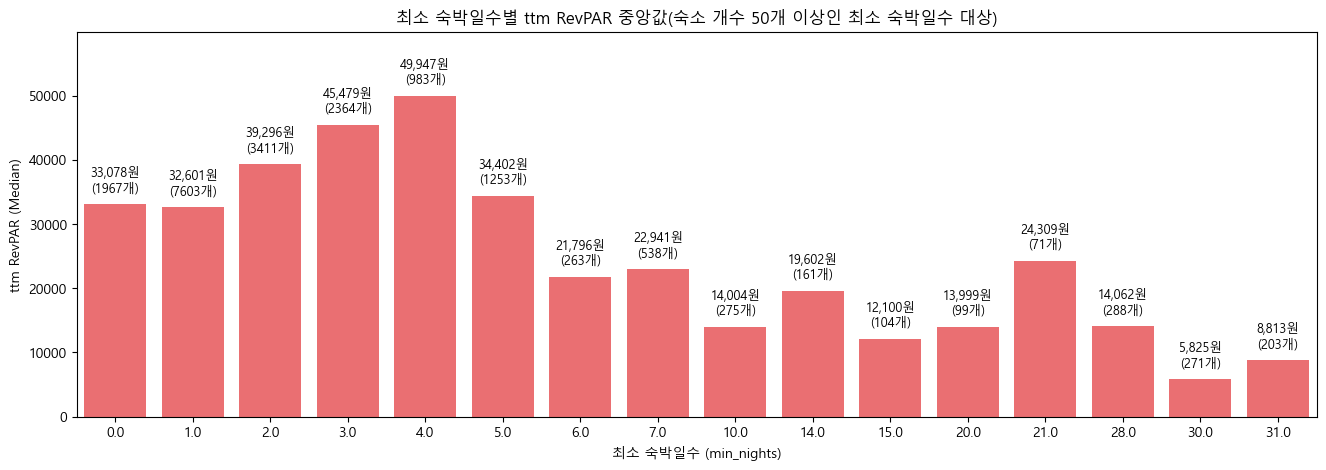

In [ ]:
# 1️⃣ 중앙값 + 개수 같이 계산
revpar_stats = (
    gdf_active_airbnb_trans
    .groupby('min_nights_w')
    .agg(
        median_revpar=('ttm_revpar', 'median'),
        listing_count=('ttm_revpar', 'count')
    )
    .reset_index()
)

# 숙소개수 50개 이상인 것만 필터링
revpar_stats = revpar_stats[revpar_stats['listing_count'] >= 50]

plt.figure(figsize=(16, 5))
ax = sns.barplot(
    data=revpar_stats,
    x='min_nights_w',
    y='median_revpar',
    color='#FF5A5F'
)

# 2️⃣ 텍스트 표시 (값 + 개수)
max_val = revpar_stats['median_revpar'].max()
y_offset = max_val * 0.03

for p, (_, row) in zip(ax.patches, revpar_stats.iterrows()):
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width()/2,
        height + y_offset,
        f'{height:,.0f}원\n({int(row["listing_count"])}개)',
        ha='center',
        va='bottom',
        fontsize=9
    )

# 3️⃣ y축 여유
plt.ylim(0, max_val * 1.2)

plt.title('최소 숙박일수별 ttm RevPAR 중앙값(숙소 개수 50개 이상인 최소 숙박일수 대상)')
plt.xlabel('최소 숙박일수 (min_nights)')
plt.ylabel('ttm RevPAR (Median)')

plt.show()

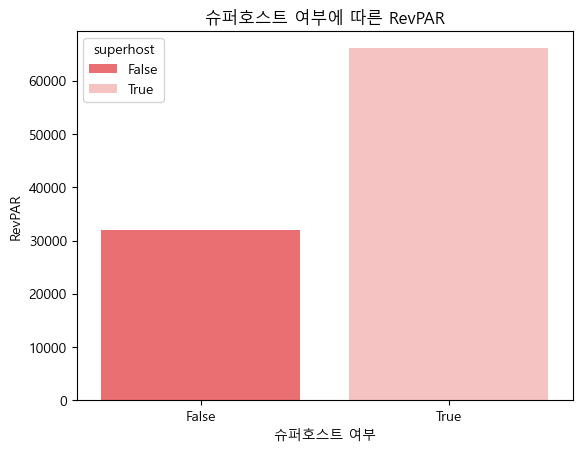

In [ ]:
# 가격을 '저가/중가/고가'로 나누어서 즉시예약 효과 확인
# gdf_airbnb_good['price_tier'] = pd.qcut(gdf_airbnb_good['ttm_avg_rate'], 3, labels=['Low', 'Mid', 'High'])

# Airbnb 색상: 빨강 계열 (연한~진한)
airbnb_palette = ['#FF5A5F', '#FFBABA']

ax = sns.barplot(
    data=gdf_active_airbnb_trans,
    x='superhost',
    y='ttm_revpar',
    hue='superhost',
    palette=airbnb_palette,
    ci=None
)

plt.title('슈퍼호스트 여부에 따른 RevPAR')

plt.ylabel('RevPAR')
plt.xlabel('슈퍼호스트 여부')
plt.show()

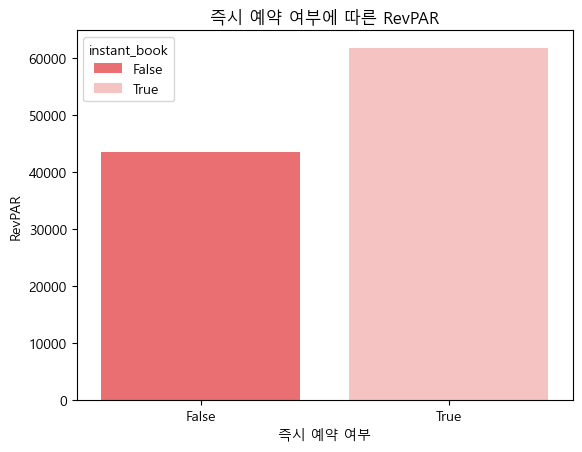

In [ ]:
# Airbnb 색상: 빨강 계열 (연한~진한)
airbnb_palette = ['#FF5A5F', '#FFBABA']

ax = sns.barplot(
    data=gdf_active_airbnb_trans,
    x='instant_book',
    y='ttm_revpar',
    hue='instant_book',
    palette=airbnb_palette,
    ci=None
)

plt.title('즉시 예약 여부에 따른 RevPAR')

plt.ylabel('RevPAR')
plt.xlabel('즉시 예약 여부')
plt.show()

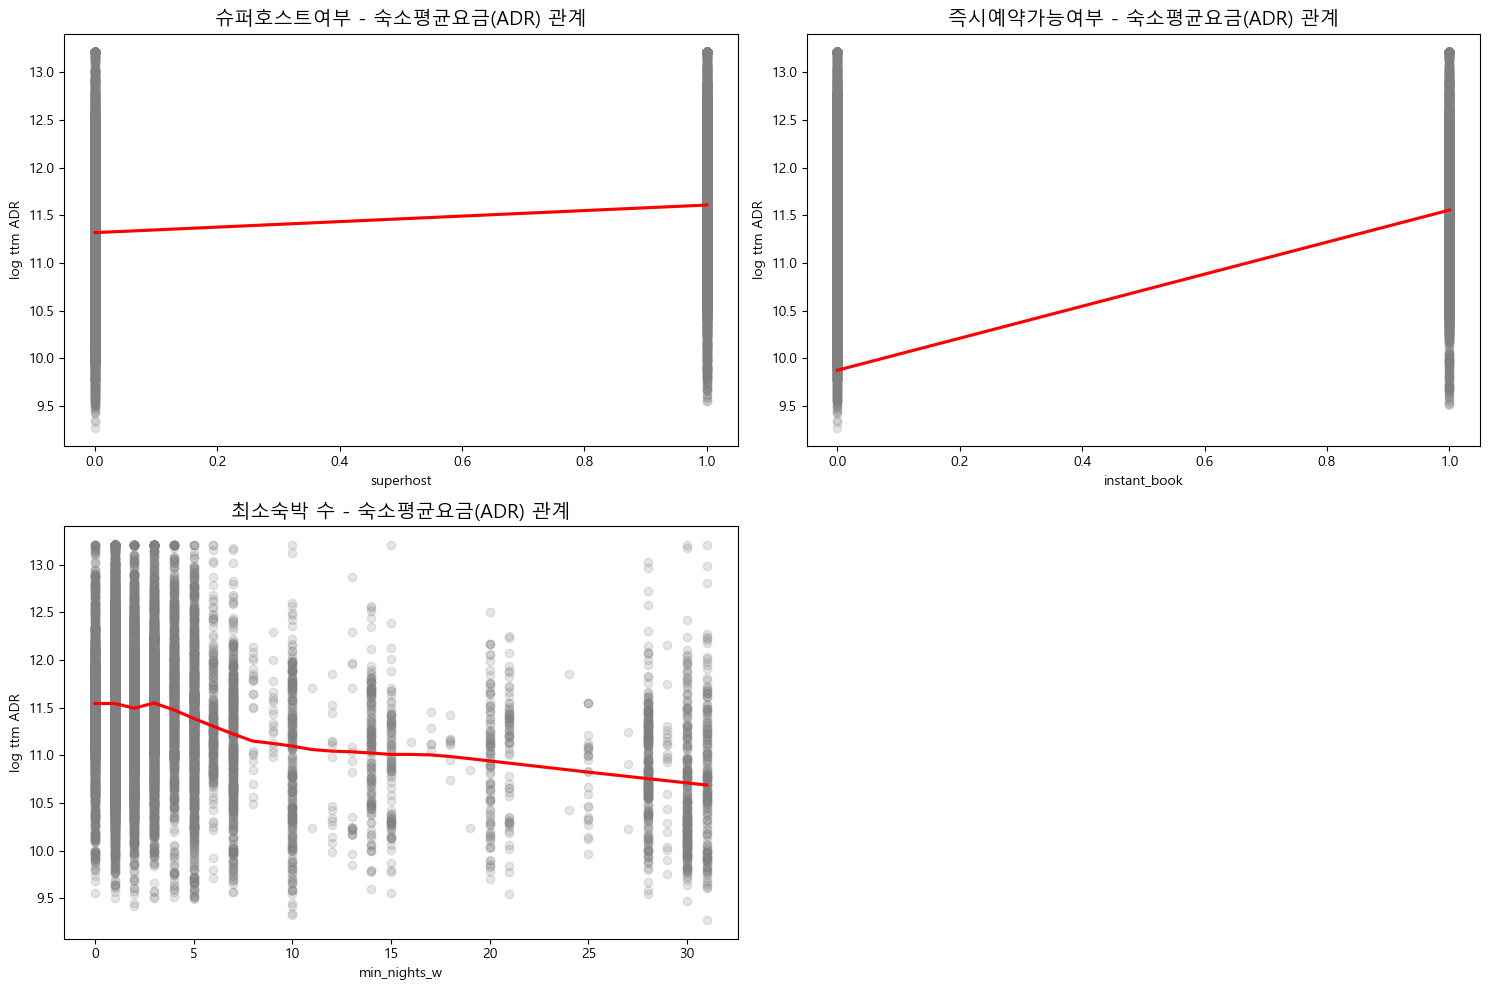

In [ ]:
# 분석할 주요 수치형 컬럼 리스트
features = ['superhost', 'instant_book', 'min_nights_w']

# 그래프 레이아웃 설정 (3열로 구성)
n_cols = 2
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5))
axes = axes.flatten()

feature_names_kr = {
    'superhost': '슈퍼호스트여부',
    'instant_book': '즉시예약가능여부',
    'min_nights_w': '최소숙박 수'
}

for i, col in enumerate(features):
    # 각 서브플롯에 regplot 그리기
    sns.regplot(
        data=gdf_active_airbnb_trans,
        x=col,
        y='log_ttm_avg_rate',
        lowess=True,
        scatter_kws={'alpha':0.2, 'color':'gray'},
        line_kws={'color':'red'},
        ax=axes[i]
    )
    axes[i].set_title(f'{feature_names_kr[col]} - 숙소평균요금(ADR) 관계', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('log ttm ADR')

# 남는 빈 그래프 공간 삭제
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

---

### 객실당 이익 상위 25% vs 나머지 숙소 데이터
1. 두 그룹에서 상위그룹은 룸타입의 차이가 거의 없지만 나머지 그룹에서 entire_room의 수익이 좋음 -> 상위그룹에는 룸타입의 의미가 없다.

In [ ]:
# 2개 그룹
q = gdf_active_airbnb_trans['ttm_revpar'].quantile(0.75)

gdf_active_airbnb_top = gdf_active_airbnb_trans[gdf_active_airbnb_trans['ttm_revpar'] >= q]
gdf_active_airbnb_rest = gdf_active_airbnb_trans[gdf_active_airbnb_trans['ttm_revpar'] < q]

# 2. 그룹 라벨링 revpar 상위 25% 그룹=Premium (Premium vs General)
gdf_active_airbnb_trans['segment'] = np.where(
    gdf_active_airbnb_trans['ttm_revpar'] >= q, 'High-Performing', 'Other'
)
gdf_active_airbnb_trans['segment'].value_counts(normalize=True)

segment
Other             0.75
High-Performing   0.25
Name: proportion, dtype: float64

In [ ]:
# 비교할 지표 정의
compare_features = {
    'ttm_revpar': 'median',       # 성과 차이 확인
    'ttm_occupancy': 'median',    # 점유율 차이
    'ttm_avg_rate': 'median',     # 가격 전략 차이
    'photos_count': 'median',   # 시각적 요소
    'num_reviews': 'median',    # 신뢰도 요소
    'rating_overall': 'median',   # 만족도 요소
    'bedrooms_w': 'median',       # 규모 요소
    'guests': 'median',
    'baths_w': 'median',
    'beds_w': 'median',
    'superhost': 'mean',          # 운영 퀄리티(비율)
    'instant_book': 'mean',        # 예약 편의성(비율)
    'min_nights_w': 'median'
}

# 그룹별 통계 계산
premium_profile = gdf_active_airbnb_trans.groupby('segment').agg(compare_features).reset_index()

# 프리미엄이 일반 대비 얼마나 우수한지 '배수' 계산 (Optional)
# 예: 프리미엄 사진 수가 일반보다 1.5배 많은지 등
display(premium_profile)
premium_profile.to_csv('./두그룹간 지표 비교.csv')

,segment,ttm_revpar,ttm_occupancy,ttm_avg_rate,photos_count,num_reviews,rating_overall,bedrooms_w,guests,baths_w,beds_w,superhost,instant_book,min_nights_w
0,High-Performing,98644.45,0.68,158625.04,36.00,59.50,4.88,2.00,4.00,1.00,2.00,0.75,0.41,2.00
1,Other,21372.55,0.26,80194.14,22.00,20.00,4.74,1.00,2.00,1.00,1.00,0.43,0.30,2.00


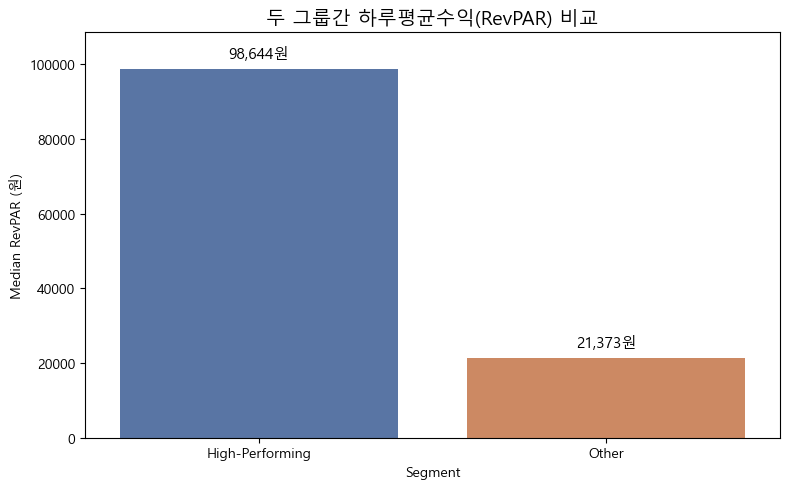

In [ ]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=premium_profile,
    x='segment',
    y='ttm_revpar',
    palette=['#4C72B0', '#DD8452']
)

# 값 라벨 표시
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():,.0f}원",
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        xytext=(0,5),
        textcoords='offset points'
    )

# y축 여유 추가
max_val = premium_profile['ttm_revpar'].max()
plt.ylim(0, max_val * 1.1)

plt.title("두 그룹간 하루평균수익(RevPAR) 비교", fontsize=14)
plt.xlabel("Segment")
plt.ylabel("Median RevPAR (원)")
plt.tight_layout()
plt.show()

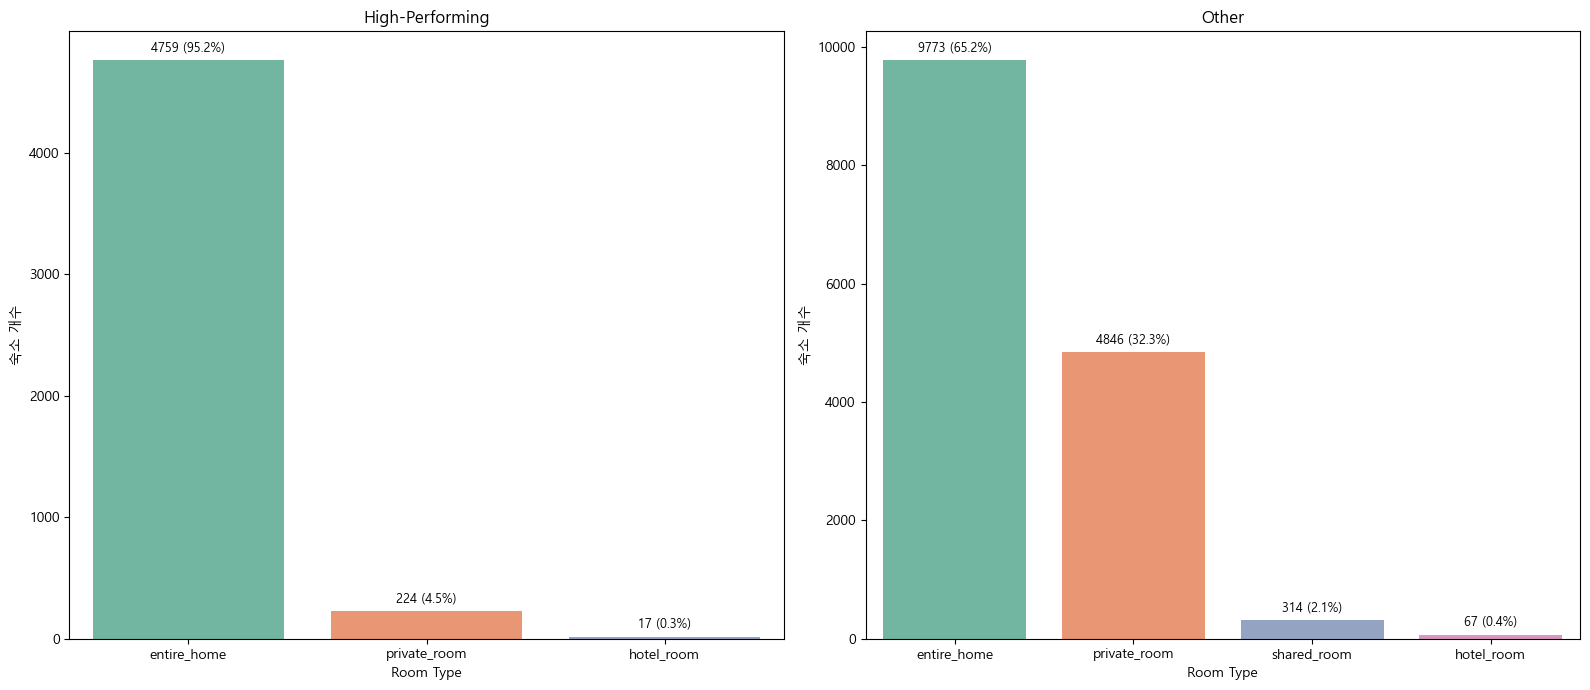

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16,7))

datasets = [
    (gdf_active_airbnb_top, 'High-Performing'),
    (gdf_active_airbnb_rest, 'Other')
]

for ax, (df, title) in zip(axes, datasets):
    room_counts = (
        df.groupby('room_type')
        .size()
        .reset_index(name='count')
        .sort_values('count', ascending=False)
    )

    sns.barplot(
        data=room_counts,
        x='room_type',
        y='count',
        palette='Set2',
        ax=ax
    )

    # 전체 합계
    total = room_counts['count'].sum()

    # 막대 위에 개수 + 퍼센트 표시
    for p in ax.patches:
        height = p.get_height()
        percent = height / total * 100

        ax.text(
            p.get_x() + p.get_width()/2,
            height + room_counts['count'].max()*0.01,
            f'{int(height)} ({percent:.1f}%)',
            ha='center',
            va='bottom',
            fontsize=9
        )

    ax.set_title(title)
    ax.set_xlabel('Room Type')
    ax.set_ylabel('숙소 개수')

plt.tight_layout()
plt.show()

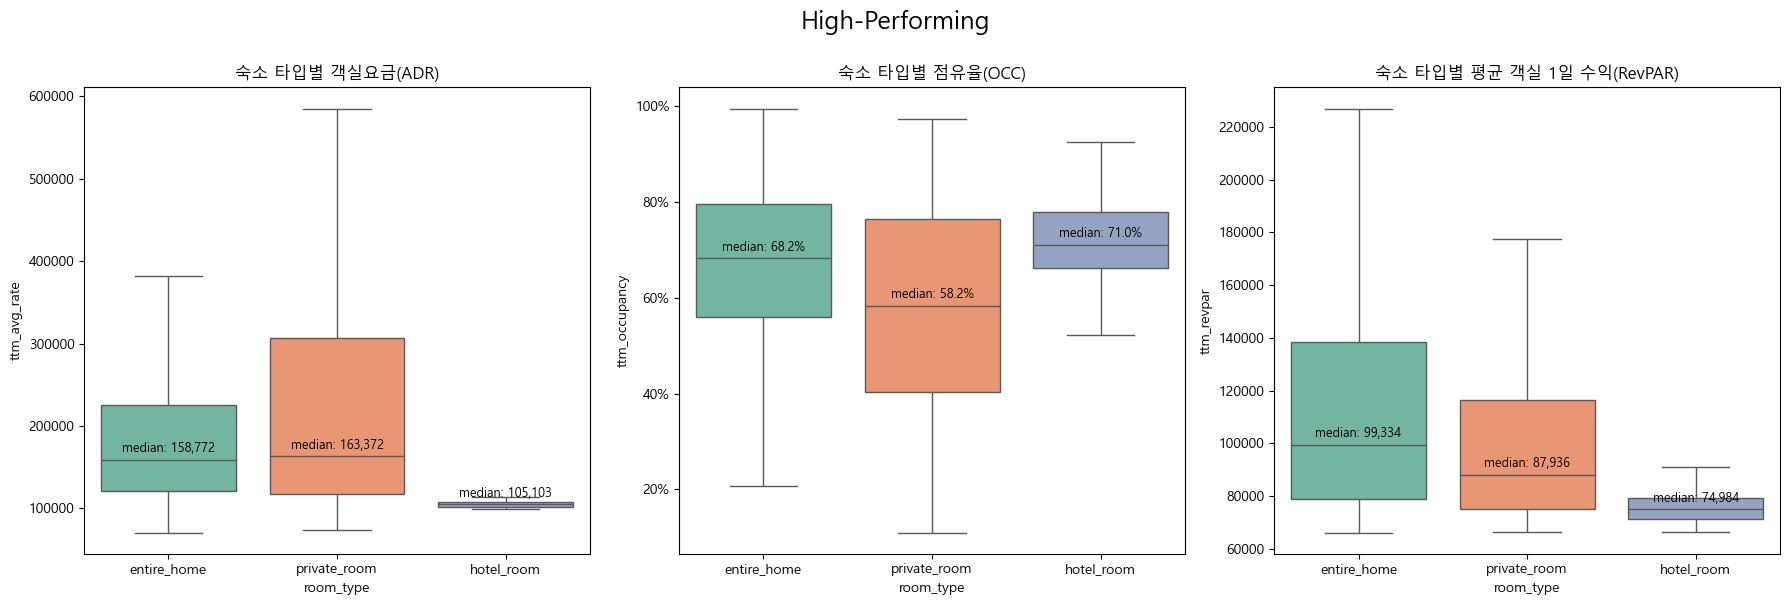

In [ ]:
import matplotlib.ticker as mtick

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

fig.suptitle("High-Performing", fontsize=18, y=1)

y_cols = ['ttm_avg_rate', 'ttm_occupancy', 'ttm_revpar']
titles = [
    '숙소 타입별 객실요금(ADR)',
    '숙소 타입별 점유율(OCC)',
    '숙소 타입별 평균 객실 1일 수익(RevPAR)'
]

for ax, y_col, title in zip(axes, y_cols, titles):

    sns.boxplot(
        data=gdf_active_airbnb_top,
        x='room_type',
        y=y_col,
        palette='Set2',
        showfliers=False,
        ax=ax
    )

    order = [t.get_text() for t in ax.get_xticklabels()]

    medians = (
        gdf_active_airbnb_top
        .groupby('room_type')[y_col]
        .median()
        .loc[order]
    )

    y_min, y_max = ax.get_ylim()
    offset = (y_max - y_min) * 0.01

    for i, room in enumerate(order):
        median_val = medians[room]

        # 점유율일 경우 %
        if y_col == 'ttm_occupancy':
            label = f'median: {median_val:.1%}'
        else:
            label = f'median: {median_val:,.0f}'

        ax.text(
            i,
            median_val + offset,
            label,
            ha='center',
            va='bottom',
            color='black',
            fontsize=9
        )

    # 점유율 축을 %로 변환
    if y_col == 'ttm_occupancy':
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    ax.set_title(title)

plt.tight_layout()
plt.show()

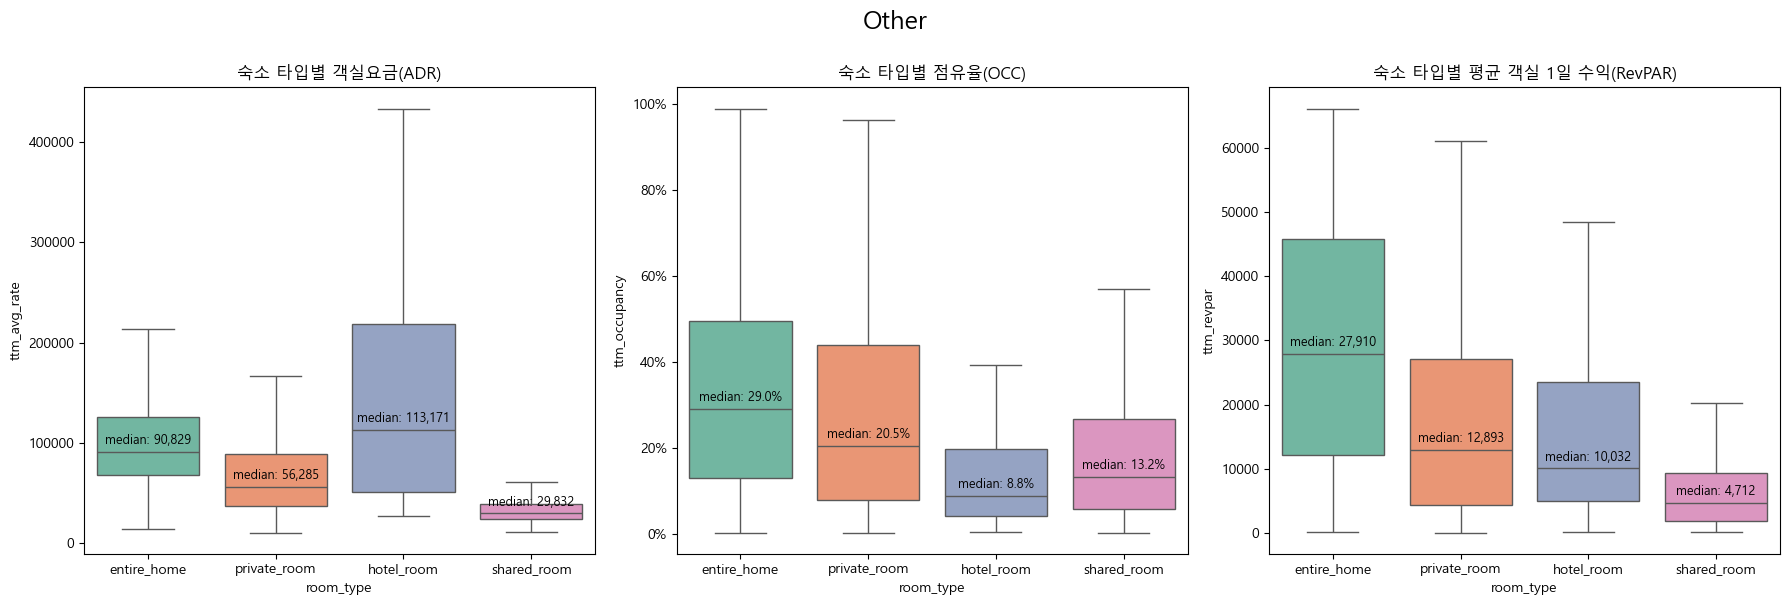

In [ ]:
import matplotlib.ticker as mtick

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Other", fontsize=18, y=1)

y_cols = ['ttm_avg_rate', 'ttm_occupancy', 'ttm_revpar']
titles = [
    '숙소 타입별 객실요금(ADR)',
    '숙소 타입별 점유율(OCC)',
    '숙소 타입별 평균 객실 1일 수익(RevPAR)'
]

for ax, y_col, title in zip(axes, y_cols, titles):

    sns.boxplot(
        data=gdf_active_airbnb_rest,
        x='room_type',
        y=y_col,
        palette='Set2',
        showfliers=False,
        ax=ax
    )

    order = [t.get_text() for t in ax.get_xticklabels()]

    medians = (
        gdf_active_airbnb_rest
        .groupby('room_type')[y_col]
        .median()
        .loc[order]
    )

    y_min, y_max = ax.get_ylim()
    offset = (y_max - y_min) * 0.01

    for i, room in enumerate(order):
        median_val = medians[room]

        # 점유율일 경우 %
        if y_col == 'ttm_occupancy':
            label = f'median: {median_val:.1%}'
        else:
            label = f'median: {median_val:,.0f}'

        ax.text(
            i,
            median_val + offset,
            label,
            ha='center',
            va='bottom',
            color='black',
            fontsize=9
        )

    # 점유율 축을 %로 변환
    if y_col == 'ttm_occupancy':
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    ax.set_title(title)

plt.tight_layout()
plt.show()

전체 숙소 평균 스펙:
  Specification  Average_Value
0         baths           0.89
1      bedrooms           1.05
2          beds           1.66
3        guests           2.71


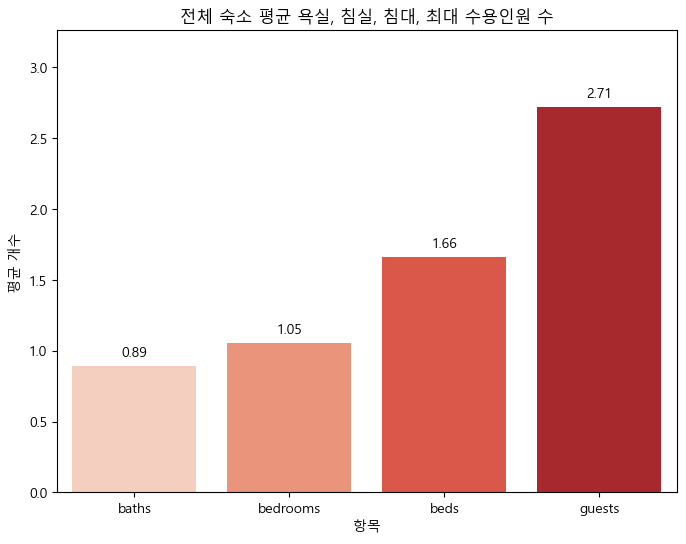

In [ ]:
# 1. 전체 평균 계산 (groupby 제거)
spec_means = (
    gdf_active_airbnb_rest[['baths', 'bedrooms', 'beds', 'guests']]
    .mean()
    .reset_index()
)

# 컬럼명 정리
spec_means.columns = ['Specification', 'Average_Value']

print("전체 숙소 평균 스펙:")
print(spec_means)

# 2. 시각화
plt.figure(figsize=(8, 6))
ax = sns.barplot(
    data=spec_means,
    x='Specification',
    y='Average_Value',
    palette='Reds'
)

# 3. 막대 위 수치 표시
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + 0.05,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title('전체 숙소 평균 욕실, 침실, 침대, 최대 수용인원 수')
plt.ylabel('평균 개수')
plt.xlabel('항목')
plt.ylim(0, spec_means['Average_Value'].max() * 1.2)
plt.show()

숙소 타입별 평균 스펙:
      room_type  baths  bedrooms  beds  guests
0   entire_home   1.03      1.31  1.77    3.61
1    hotel_room   1.01      0.75  1.93    2.34
2  private_room   0.59      0.59  1.33    1.05
3   shared_room   1.12      0.24  3.30    0.59


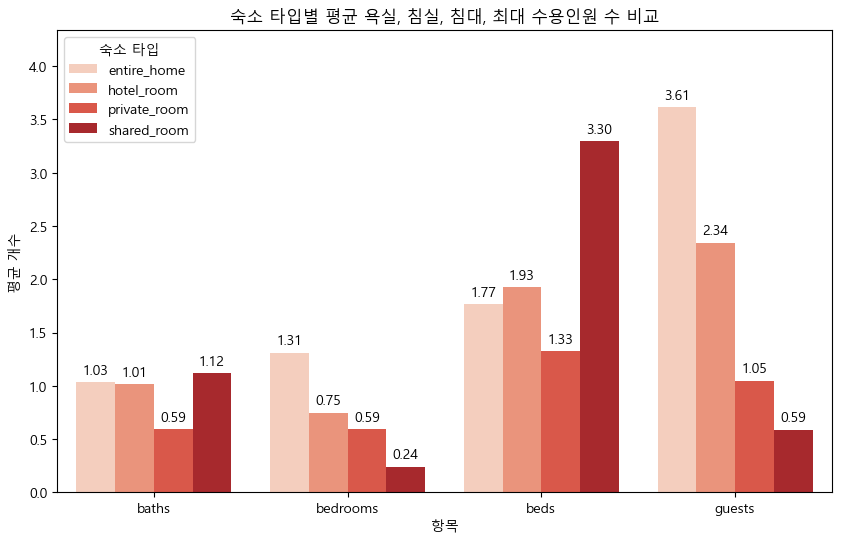

In [ ]:
# 1. room_type별로 그룹화하여 주요 스펙(욕실, 침실, 침대)의 평균 계산
spec_means = gdf_active_airbnb_rest.groupby('room_type')[['baths', 'bedrooms', 'beds', 'guests']].mean().reset_index()

# 2. 결과 수치 출력
print("숙소 타입별 평균 스펙:")
print(spec_means)

# 3. 시각화를 위해 데이터 형태 변환 (Melting)
# 이 과정은 막대 그래프에서 'baths', 'bedrooms', 'beds'를 나란히 보여주기 위해 필요.
melted_specs = spec_means.melt(id_vars='room_type', var_name='Specification', value_name='Average_Value')

# 4. 시각화 (막대 그래프)
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=melted_specs,
    x='Specification',
    y='Average_Value',
    hue='room_type',
    palette='Reds'
)

# 5. 막대 위에 실제 수치 표시 (텍스트 라벨링)
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # 0보다 큰 경우에만 표시
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + 0.05,
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title('숙소 타입별 평균 욕실, 침실, 침대, 최대 수용인원 수 비교')
plt.ylabel('평균 개수')
plt.xlabel('항목')
plt.ylim(0, melted_specs['Average_Value'].max() * 1.2) # 텍스트 표시 공간 확보
plt.legend(title='숙소 타입')
plt.show()

커널 밀도함수를 통해 분포 비교

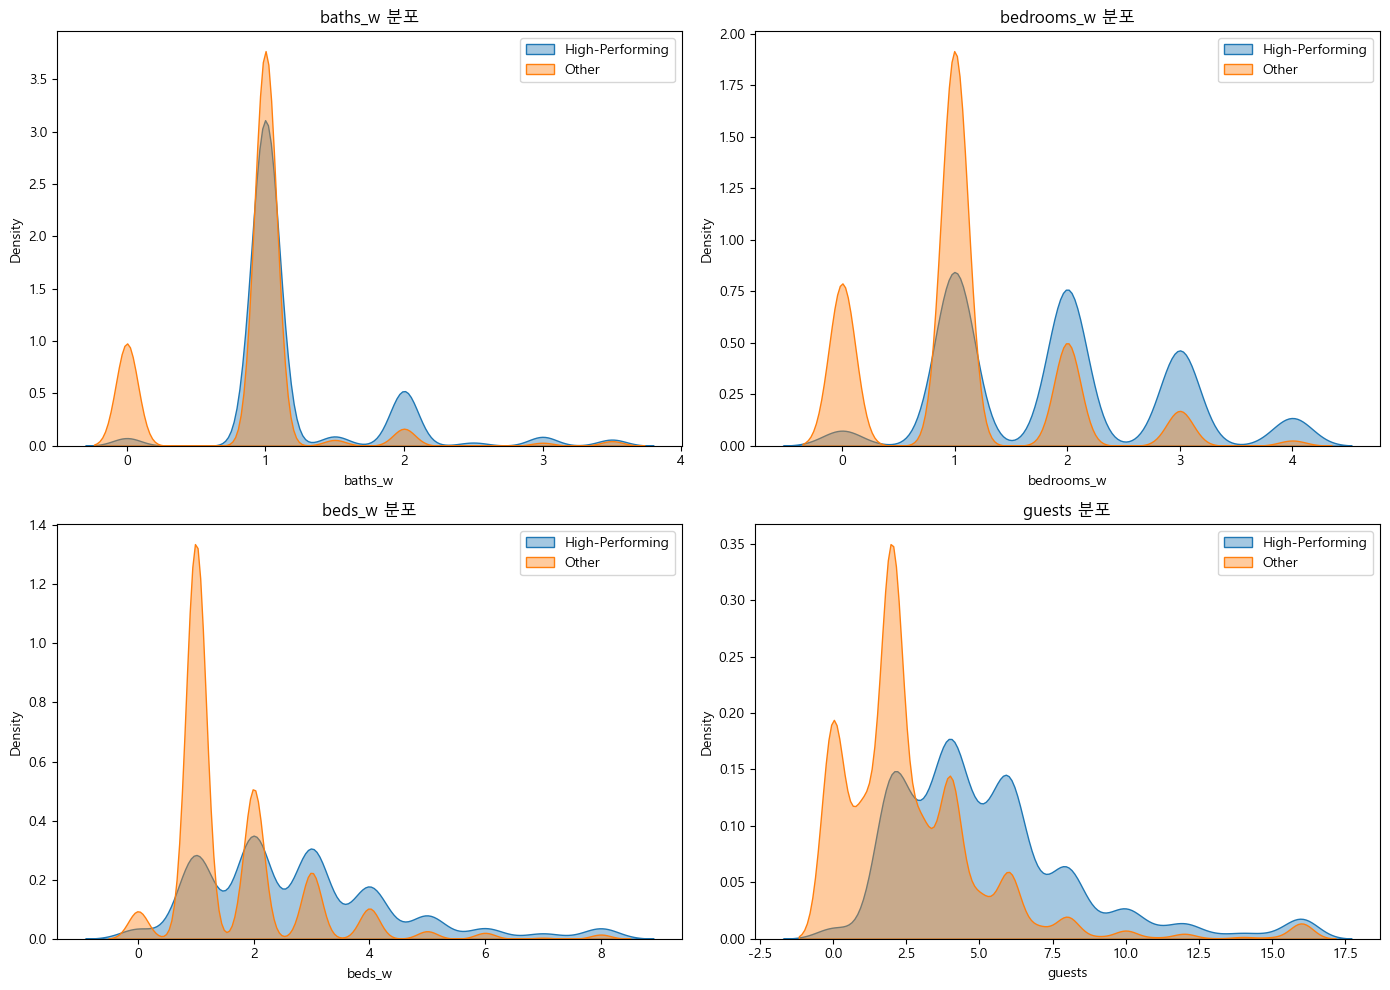

In [ ]:
features = ['baths_w', 'bedrooms_w', 'beds_w', 'guests']

n_cols = 2
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(features):

    sns.kdeplot(
        data=gdf_active_airbnb_top,
        x=col,
        label='High-Performing',
        fill=True,
        alpha=0.4,
        ax=axes[i]
    )

    sns.kdeplot(
        data=gdf_active_airbnb_rest,
        x=col,
        label='Other',
        fill=True,
        alpha=0.4,
        ax=axes[i]
    )

    axes[i].set_title(f'{col} 분포')
    axes[i].legend()

# 남는 subplot 제거
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

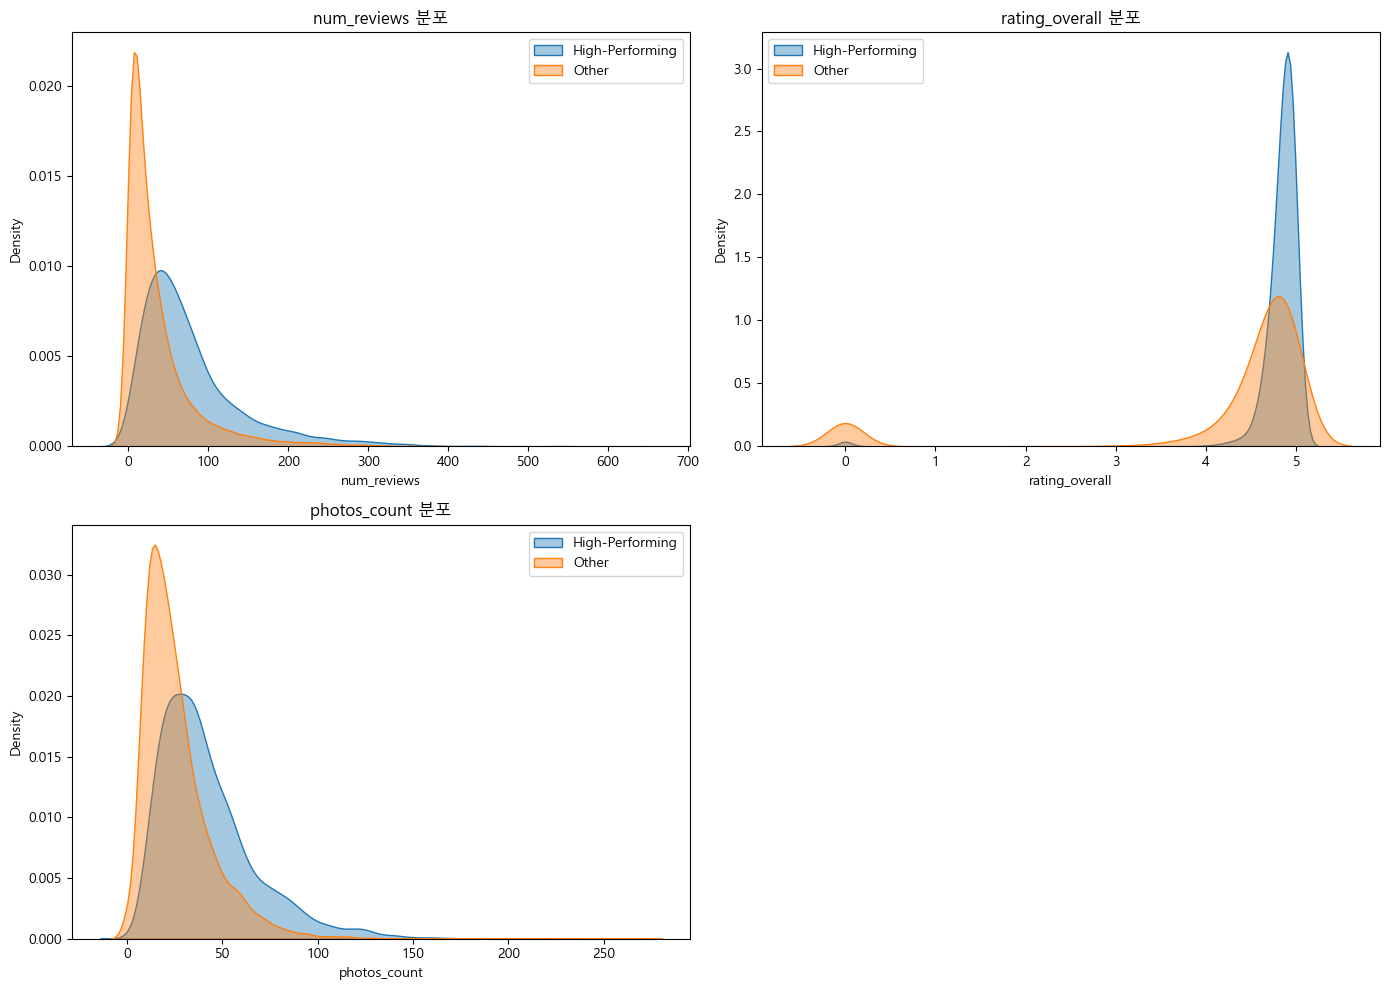

In [ ]:
features = ['num_reviews', 'rating_overall', 'photos_count']

n_cols = 2
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(features):

    sns.kdeplot(
        data=gdf_active_airbnb_top,
        x=col,
        label='High-Performing',
        fill=True,
        alpha=0.4,
        ax=axes[i]
    )

    sns.kdeplot(
        data=gdf_active_airbnb_rest,
        x=col,
        label='Other',
        fill=True,
        alpha=0.4,
        ax=axes[i]
    )

    axes[i].set_title(f'{col} 분포')
    axes[i].legend()

# 남는 subplot 제거
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

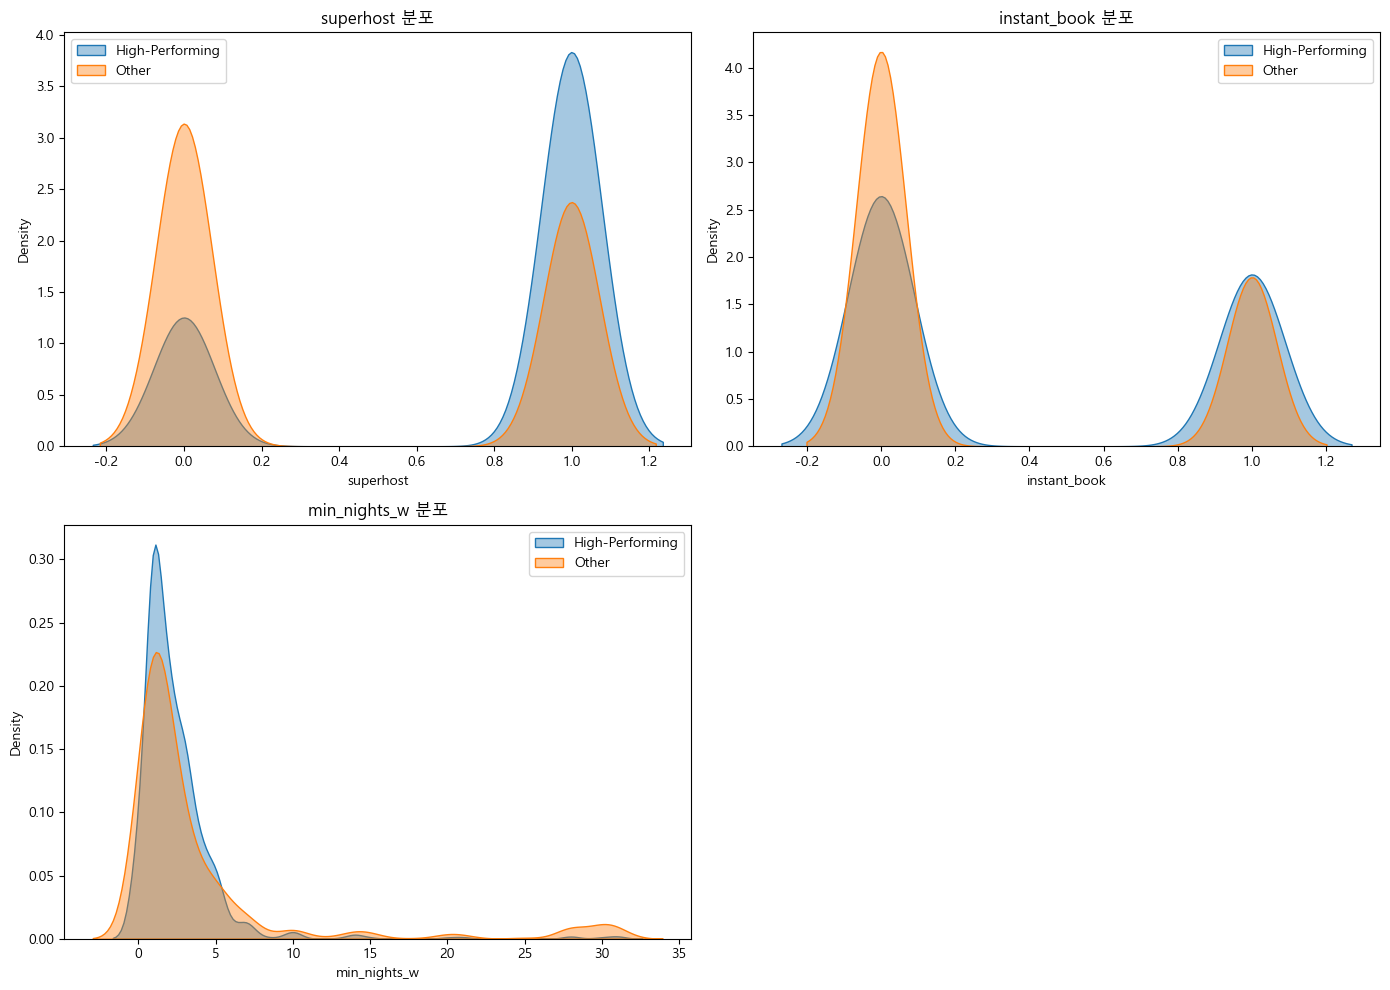

In [ ]:
features = ['superhost', 'instant_book', 'min_nights_w']

n_cols = 2
n_rows = math.ceil(len(features) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(features):

    sns.kdeplot(
        data=gdf_active_airbnb_top,
        x=col,
        label='High-Performing',
        fill=True,
        alpha=0.4,
        ax=axes[i]
    )

    sns.kdeplot(
        data=gdf_active_airbnb_rest,
        x=col,
        label='Other',
        fill=True,
        alpha=0.4,
        ax=axes[i]
    )

    axes[i].set_title(f'{col} 분포')
    axes[i].legend()

# 남는 subplot 제거
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### 자치구별로 수익 발생 숙소 차이가 있을까?

In [ ]:
# # 매출 발생, 미발생 컬럼 추가
# gdf_active_airbnb['revenue_flag'] = gdf_active_airbnb['ttm_revpar'].apply(
#     lambda x: 'RevPAR 상위 25%' if x >= q else 'RevPAR 하위 75%'
# )

1. 자치구별 수익 유불리 지역 확인
- 마포구, 종로구, 중구, 용산구, 성동구, 강남구가 높은 수익을 창출하는 지역

In [ ]:
# 자치구 불러오기
gdf_gu = gpd.read_file('./병합완료/서울시 상권분석서비스(영역-자치구)/서울시 상권분석서비스(영역-자치구).shp')
gdf_gu.columns

Index(['SIGNGU_CD', 'SIGNGU_NM', 'XCNTS_VALU', 'YDNTS_VALU', 'RELM_AR',
       'geometry'],
      dtype='object')

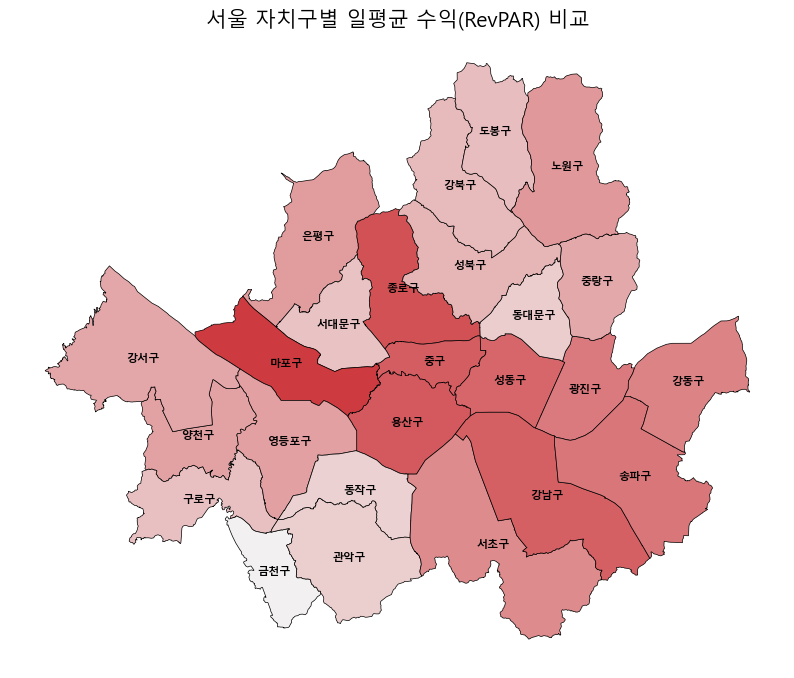

In [ ]:
# 자치구별 revpar 중앙값
gu_revpar = (
    gdf_active_airbnb_trans
    .groupby('district')['ttm_revpar']
    .median()
    .reset_index()
)

gu_revpar.sort_values('ttm_revpar', ascending=False)

# shp와 merge
gdf_map = gdf_gu.merge(
    gu_revpar,
    left_on='SIGNGU_NM',
    right_on='district',
    how='left'
)

# -------------------------------
# 지도 시각화
# -------------------------------

# 컬러맵: Airbnb 느낌, 연핑크~진핑크
cmap = sns.light_palette("#CD3A3F", as_cmap=True)

fig, ax = plt.subplots(figsize=(10,10))
fig.patch.set_alpha(0)   # 전체 배경 투명
ax.set_facecolor('none') # 축 배경 제거

# 자치구별 RevPAR
gdf_map.plot(
    column='ttm_revpar',
    cmap=cmap,
    linewidth=0.5,
    edgecolor='black',
    ax=ax
)

# 자치구 이름 표시
for idx, row in gdf_map.iterrows():
    # 폴리곤 중심점 좌표
    x, y = row['geometry'].centroid.x, row['geometry'].centroid.y
    ax.text(
        x, y,
        row['SIGNGU_NM'],       # 자치구 이름
        horizontalalignment='center',
        verticalalignment='center',
        fontsize=8,
        color='black',
        weight='bold'
    )

ax.set_title('서울 자치구별 일평균 수익(RevPAR) 비교', fontsize=15)
ax.axis('off')

plt.show()

2. 자치구별 High-Performing 지역 확인
- 마포구, 종로구, 중구, 용산구로 조금 더 좁혀짐

In [ ]:
# 자치구별 상위 25% 숙소 개수 계산
top_counts = (
    gdf_active_airbnb_trans[gdf_active_airbnb_trans['segment'] == 'High-Performing']
    .groupby('district')
    .size()
    .reset_index(name='top_revpar_count')
)

# 전체 숙소 대비 비율도 계산
total_counts = (
    gdf_active_airbnb_trans
    .groupby('district')
    .size()
    .reset_index(name='total_count')
)

district_stats = top_counts.merge(total_counts, on='district')
district_stats['top_revpar_ratio'] = district_stats['top_revpar_count'] / district_stats['total_count']

district_stats.sort_values('top_revpar_ratio', ascending=False, inplace=True)
district_stats

,district,top_revpar_count,total_count,top_revpar_ratio
11,마포구,1580,4248,0.37
22,중구,736,2249,0.33
21,종로구,561,1724,0.33
19,용산구,594,1838,0.32
14,성동구,86,345,0.25
0,강남구,442,1777,0.25
16,송파구,130,591,0.22
13,서초구,199,977,0.20
12,서대문구,194,1077,0.18
20,은평구,40,238,0.17


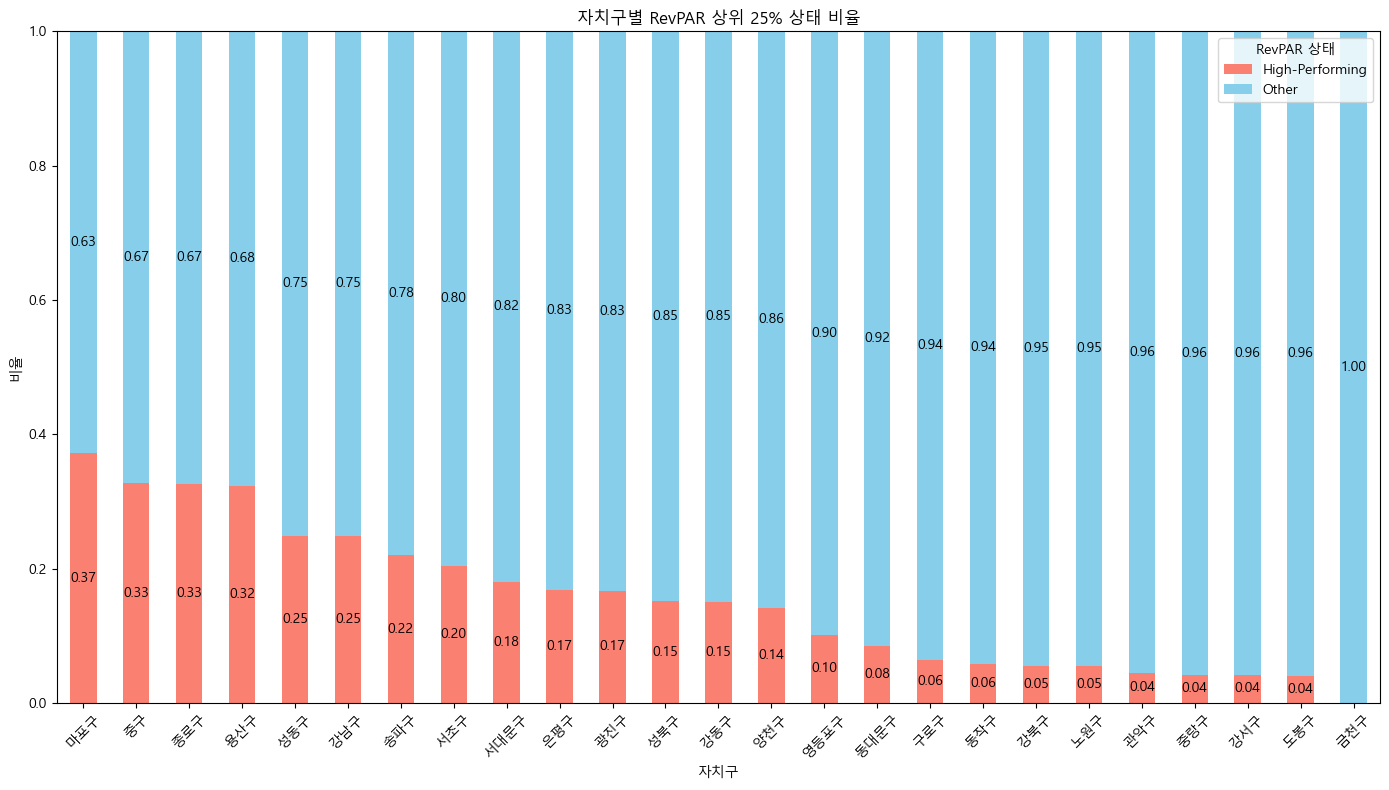

In [ ]:
# district별 Revenue 상태 카운트
district_counts = (
    gdf_active_airbnb_trans
    .groupby(['district', 'segment'])
    .size()
    .unstack(fill_value=0)
)

# 전체 대비 비율 계산
district_counts_ratio = district_counts.div(district_counts.sum(axis=1), axis=0)

# Revenue = 0 비율 기준으로 정렬
district_counts_ratio = district_counts_ratio.sort_values('High-Performing', ascending=False)
district_counts_ratio = district_counts_ratio[['High-Performing', 'Other']]

# Stacked Bar Plot
ax = district_counts_ratio.plot(
    kind='bar',
    stacked=True,
    figsize=(14,8),
    color=['salmon', 'skyblue']
)

# 막대 위 비율 라벨 추가
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.text(
            p.get_x() + p.get_width()/2.,
            p.get_y() + height/2.,  # 막대 중간
            f'{height:.2f}',
            ha='center',
            va='center',
            fontsize=10,
            color='black'
        )

plt.ylabel('비율')
plt.xlabel('자치구')
plt.title('자치구별 RevPAR 상위 25% 상태 비율')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(title='RevPAR 상태')
plt.tight_layout()
plt.show()

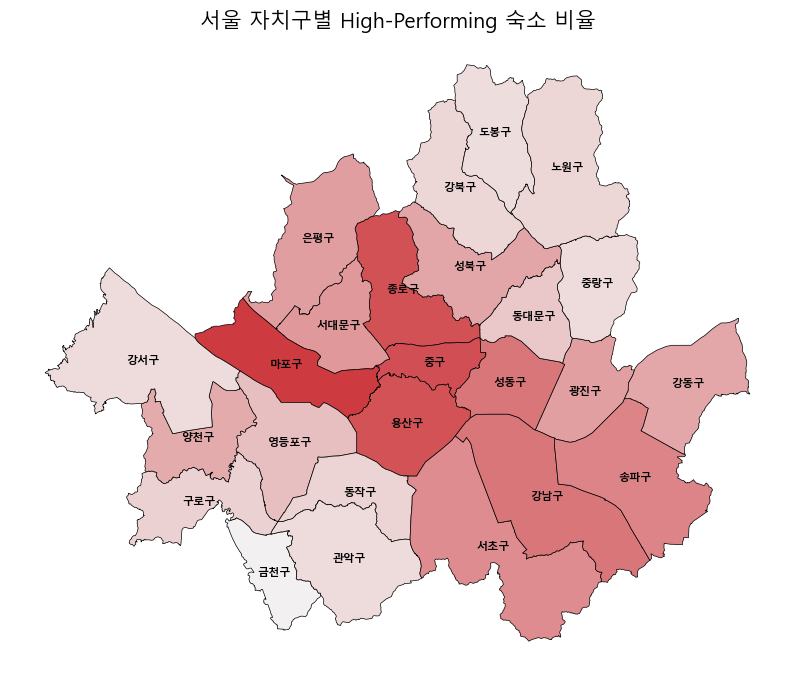

In [ ]:
# -------------------------------
# 1. 자치구 shp와 top 25% 비율 merge
# -------------------------------
gdf_map_ratio = gdf_gu.merge(
    district_stats[['district', 'top_revpar_ratio']],
    left_on='SIGNGU_NM',
    right_on='district',
    how='left'
)

# NaN → 0 처리
gdf_map_ratio['top_revpar_ratio'] = gdf_map_ratio['top_revpar_ratio'].fillna(0)

# -------------------------------
# 2. 지도 시각화
# -------------------------------
# 컬러맵: 연한 빨강~진한 빨강
cmap = sns.light_palette("#CD3A3F", as_cmap=True)

fig, ax = plt.subplots(figsize=(10,10))
fig.patch.set_alpha(0)   # 전체 배경 투명
ax.set_facecolor('none') # 축 배경 제거

gdf_map_ratio.plot(
    column='top_revpar_ratio',
    cmap=cmap,
    linewidth=0.5,
    edgecolor='black',
    # legend=True,
    ax=ax
)

# 자치구 이름 표시
for idx, row in gdf_map_ratio.iterrows():
    x, y = row['geometry'].centroid.x, row['geometry'].centroid.y
    ax.text(
        x, y,
        row['SIGNGU_NM'],
        horizontalalignment='center',
        verticalalignment='center',
        fontsize=8,
        color='black',
        weight='bold'
    )

ax.set_title('서울 자치구별 High-Performing 숙소 비율', fontsize=15)
ax.axis('off')

plt.show()

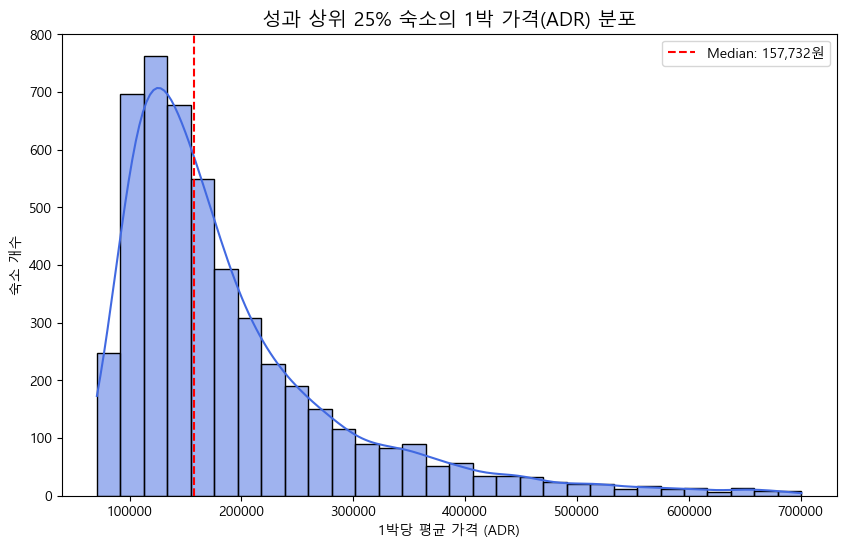

In [ ]:
# 1. 상위 25% 숙소들의 1박당 평균 가격(ttm_avg_rate) 분포 확인
plt.figure(figsize=(10, 6))

# 너무 튀는 값을 방지하기 위해 99% 지점에서 컷팅해서 그림 (시각화용)
limit = gdf_active_airbnb_top['ttm_avg_rate'].quantile(0.99)
data_to_plot = gdf_active_airbnb_top[gdf_active_airbnb_top['ttm_avg_rate'] <= limit]

sns.histplot(data_to_plot['ttm_avg_rate'], kde=True, color='royalblue', bins=30)

plt.axvline(data_to_plot['ttm_avg_rate'].median(), color='red', linestyle='--', label=f'Median: {data_to_plot["ttm_avg_rate"].median():,.0f}원')
plt.title('성과 상위 25% 숙소의 1박 가격(ADR) 분포', fontsize=14)
plt.xlabel('1박당 평균 가격 (ADR)')
plt.ylabel('숙소 개수')
plt.legend()
plt.show()

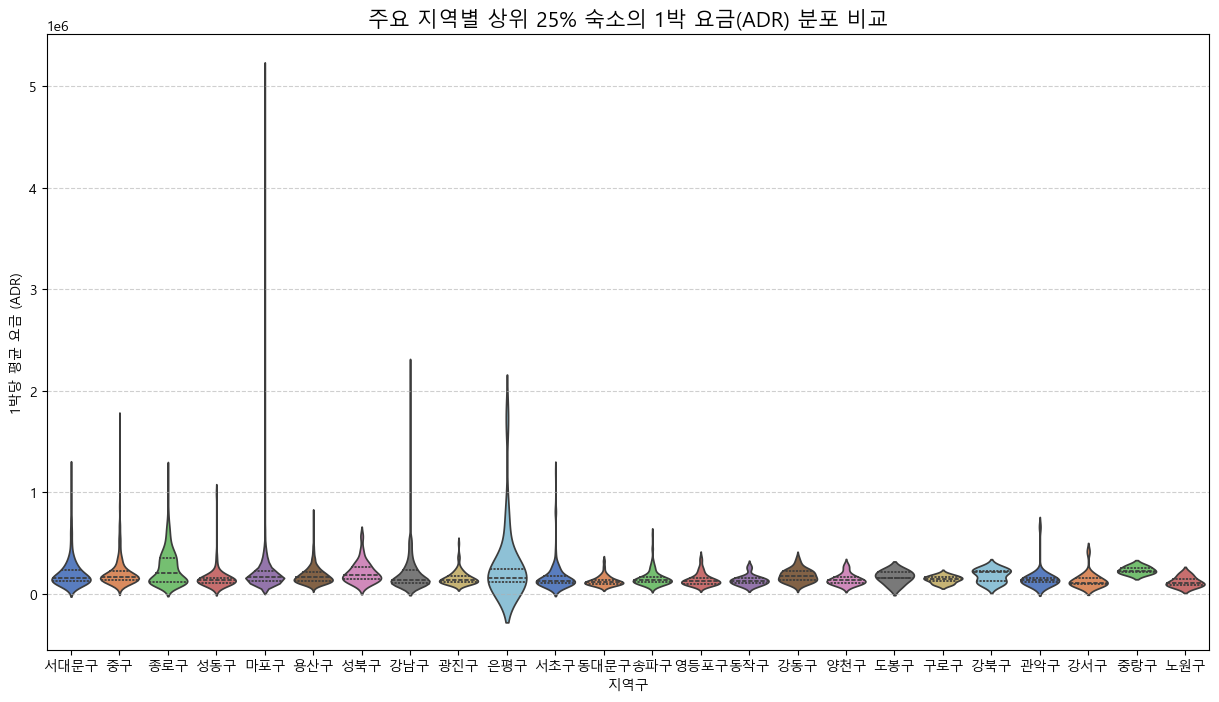

In [ ]:
# 분석 대상 지역(focus_districts)만 필터링한 데이터 사용
plt.figure(figsize=(15, 8))

# 구별로 상위 25% 숙소의 가격(ADR) 분포를 바이올린 플롯으로 확인
# (박스플롯보다 분포의 모양을 더 잘 보여줍니다)
sns.violinplot(
    data=gdf_active_airbnb_trans[gdf_active_airbnb_trans['segment'] == 'High-Performing'],
    x='district',
    y='ttm_avg_rate',
    palette='muted',
    inner="quartile"
)

plt.title('주요 지역별 상위 25% 숙소의 1박 요금(ADR) 분포 비교', fontsize=15)
plt.ylabel('1박당 평균 요금 (ADR)')
plt.xlabel('지역구')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

--- [수익 그룹별 수수료 설계 비교] ---


,Top 25% (Winner),Rest 75% (General),Gap (%)
cleaning_fee,29043.00,9681.00,200.00
extra_guest_fee,0.00,0.00,NaN


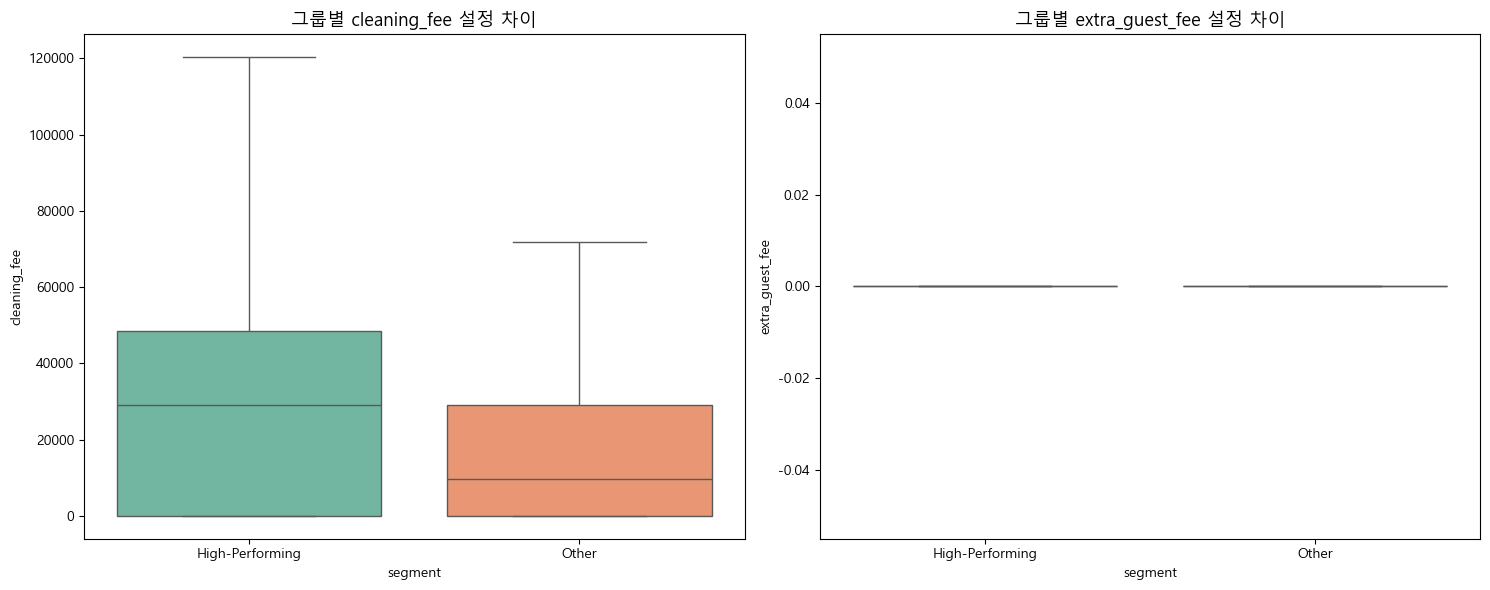

In [ ]:
# 비교할 수수료 지표
fee_features = ['cleaning_fee', 'extra_guest_fee']

# 1. 그룹별 수수료 중앙값 비교 테이블
fee_comparison = pd.DataFrame({
    'Top 25% (Winner)': gdf_active_airbnb_top[fee_features].median(),
    'Rest 75% (General)': gdf_active_airbnb_rest[fee_features].median()
})

# 격차(Gap) 계산
fee_comparison['Gap (%)'] = ((fee_comparison['Top 25% (Winner)'] / fee_comparison['Rest 75% (General)'] - 1) * 100).round(1)

print("--- [수익 그룹별 수수료 설계 비교] ---")
display(fee_comparison)

# 2. 시각화 (Box Plot)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, col in enumerate(fee_features):
    # 가독성을 위해 윈저화(상위 5% 컷팅) 후 시각화
    sns.boxplot(data=gdf_active_airbnb_trans, x='segment', y=col, ax=axes[i], palette='Set2', showfliers=False)
    axes[i].set_title(f'그룹별 {col} 설정 차이', fontsize=13)

plt.tight_layout()
plt.show()

--- [수익 그룹별 ADR 및 수수료 설계 비교] ---


,Top 25% (Winner),Rest 75% (General),Gap (%)
ttm_avg_rate,158625.04,80194.14,97.80
cleaning_fee,29043.00,9681.00,200.00
extra_guest_fee,0.00,0.00,NaN


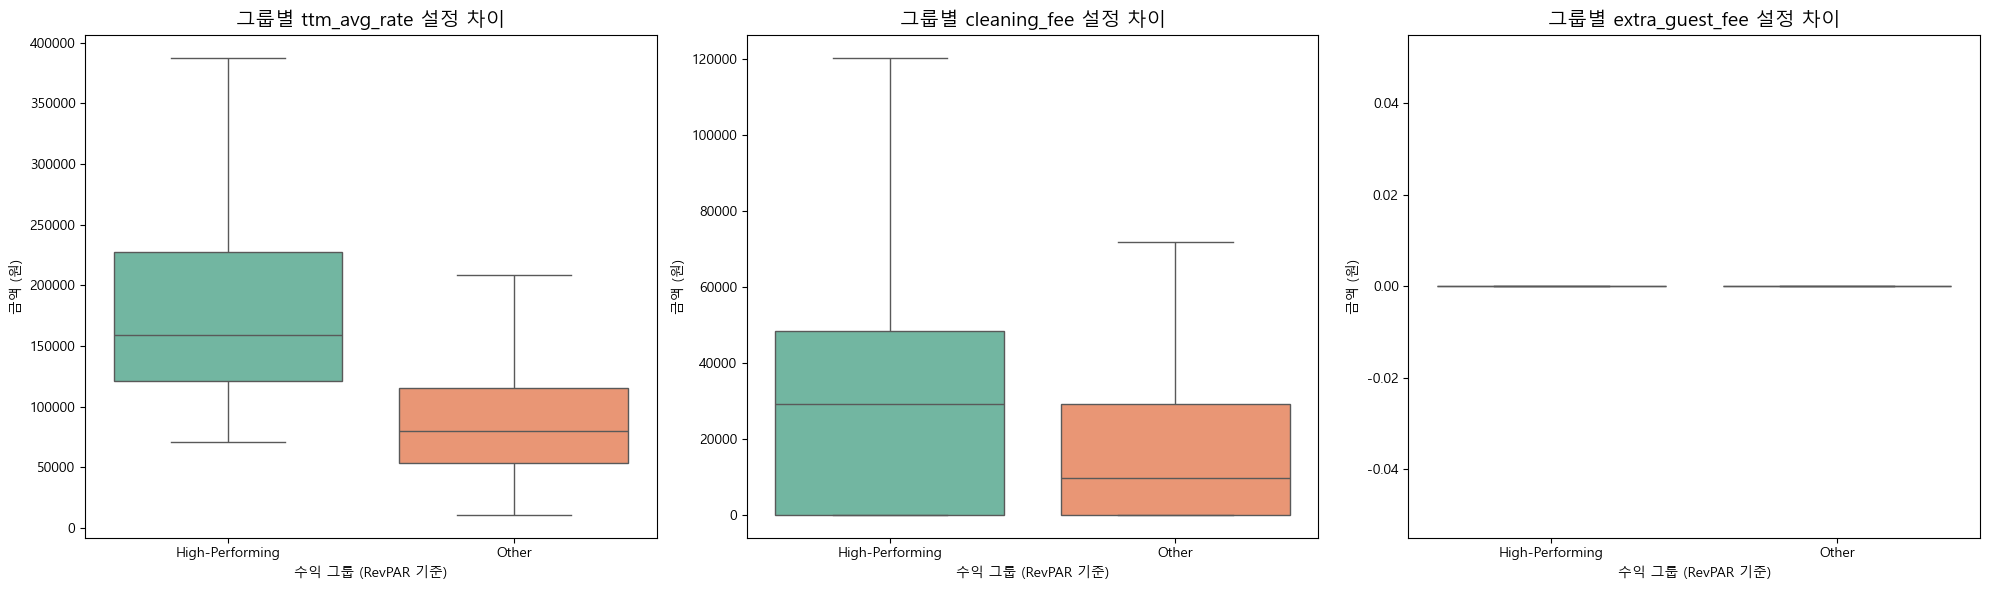

In [ ]:
# 1. ADR을 포함한 가격 지표 리스트 정의
price_features = ['ttm_avg_rate', 'cleaning_fee', 'extra_guest_fee']

# 2. 그룹별 중앙값 비교 테이블 생성 (Top 25% vs Rest 75%)
price_comparison = pd.DataFrame({
    'Top 25% (Winner)': gdf_active_airbnb_top[price_features].median(),
    'Rest 75% (General)': gdf_active_airbnb_rest[price_features].median()
})

# 격차(Gap) 계산
price_comparison['Gap (%)'] = ((price_comparison['Top 25% (Winner)'] / price_comparison['Rest 75% (General)'] - 1) * 100).round(1)

print("--- [수익 그룹별 ADR 및 수수료 설계 비교] ---")
display(price_comparison)

# 3. 시각화 (Box Plot - 3개의 지표를 위해 1행 3열 구성)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, col in enumerate(price_features):
    # 가독성을 위해 이상치를 제외(showfliers=False)하고 시각화
    sns.boxplot(
        data=gdf_active_airbnb_trans,
        x='segment',
        y=col,
        ax=axes[i],
        palette='Set2',
        showfliers=False,
        order=['High-Performing', 'Other'] # 상위권이 먼저 나오도록 정렬
    )

    axes[i].set_title(f'그룹별 {col} 설정 차이', fontsize=14)
    axes[i].set_xlabel('수익 그룹 (RevPAR 기준)')
    axes[i].set_ylabel('금액 (원)')

plt.tight_layout()
plt.show()

--- [지역별 ADR vs 청소비 격차 비교] ---


,ADR_Gap_%,Cleaning_Gap_%
segment,,
district,,
강남구,52.10,38.50
강동구,107.50,100.00
강북구,288.60,inf
강서구,61.90,115.00
관악구,154.10,40.00
광진구,73.40,88.90
구로구,146.10,171.40
금천구,NaN,NaN


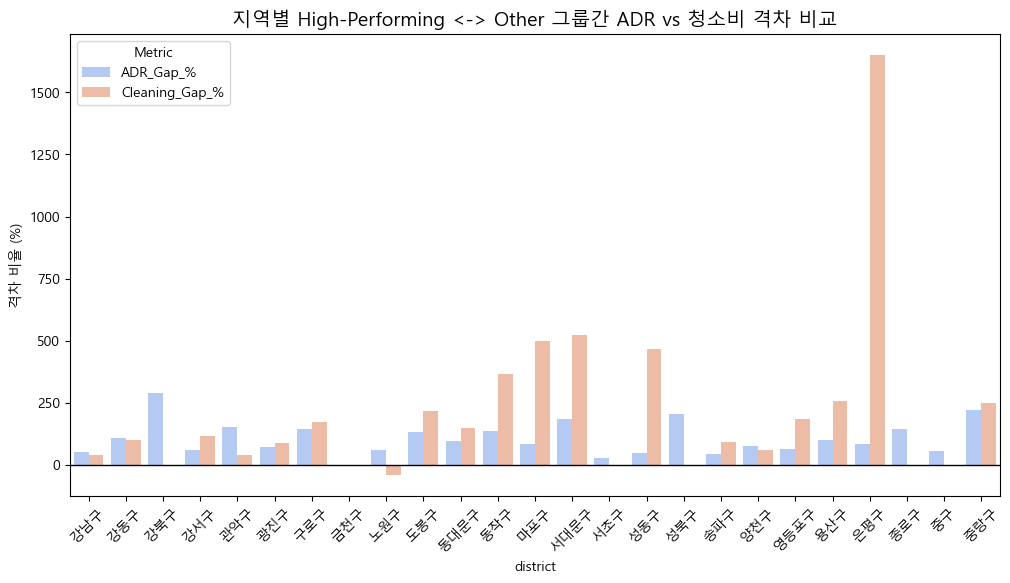

In [ ]:
# 1. 지역별/그룹별(Top vs Rest) 중앙값 집계
dist_price_summary = gdf_active_airbnb_trans.groupby(['district', 'segment'])[['ttm_avg_rate', 'cleaning_fee']].median().unstack()

# 2. 지역별 격차(Gap %) 계산
dist_price_summary['ADR_Gap_%'] = ((dist_price_summary[('ttm_avg_rate', 'High-Performing')] / dist_price_summary[('ttm_avg_rate', 'Other')] - 1) * 100).round(1)
dist_price_summary['Cleaning_Gap_%'] = ((dist_price_summary[('cleaning_fee', 'High-Performing')] / dist_price_summary[('cleaning_fee', 'Other')] - 1) * 100).round(1)

# 3. 결과 확인 (어떤 구에서 청소비 전략이 가장 극단적인가?)
print("--- [지역별 ADR vs 청소비 격차 비교] ---")
display(dist_price_summary[['ADR_Gap_%', 'Cleaning_Gap_%']])

# 4. 시각화 (두 격차를 비교하는 막대 그래프)
gap_df = dist_price_summary[['ADR_Gap_%', 'Cleaning_Gap_%']].reset_index()
gap_df.columns = gap_df.columns.get_level_values(0)
melted_gap = gap_df.melt(id_vars='district', var_name='Metric', value_name='Gap_Percentage')

plt.figure(figsize=(12, 6))
sns.barplot(data=melted_gap, x='district', y='Gap_Percentage', hue='Metric', palette='coolwarm')
plt.title('지역별 High-Performing <-> Other 그룹간 ADR vs 청소비 격차 비교', fontsize=14)
plt.axhline(0, color='black', linewidth=1)
plt.ylabel('격차 비율 (%)')
plt.xticks(rotation=45)
plt.show()

----

# 서울시 지역별 에어비앤비 성과 분석

In [ ]:
gdf_active_airbnb_trans.columns

Index(['index', 'baths', 'bedrooms', 'beds', 'cleaning_fee', 'country',
       'currency', 'extra_guest_fee', 'guests', 'instant_book',
       'l90d_avg_rate', 'l90d_occupancy', 'l90d_revenue', 'l90d_revpar',
       'listing_type', 'locality', 'min_nights', 'num_reviews', 'photos_count',
       'rating_overall', 'region', 'room_type', 'superhost', 'ttm_avg_rate',
       'ttm_occupancy', 'ttm_revenue', 'ttm_revpar', 'district', 'X좌표(WGS84)',
       'Y좌표(WGS84)', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)', 'geometry', 'baths_w',
       'bedrooms_w', 'beds_w', 'min_nights_w', 'cleaning_fee_w',
       'extra_guest_fee_w', 'num_reviews_w', 'photos_count_w',
       'l90d_avg_rate_w', 'l90d_revenue_w', 'l90d_revpar_w', 'ttm_avg_rate_w',
       'ttm_revenue_w', 'ttm_revpar_w', 'log_cleaning_fee',
       'log_extra_guest_fee', 'log_num_reviews', 'log_photos_count',
       'log_l90d_avg_rate', 'log_l90d_revenue', 'log_l90d_revpar',
       'log_ttm_avg_rate', 'log_ttm_revenue', 'log_ttm_revpar',
       'rati

In [ ]:
district_stats = gdf_active_airbnb_trans.groupby('district').agg(
    ttm_occupancy_median=('ttm_occupancy', 'median'),
    ttm_revpar_median=('ttm_revpar', 'median'),
    ttm_avg_rate_median=('ttm_avg_rate', 'median'),
    listing_count=('ttm_occupancy', 'count')  # 또는 'id' 컬럼 사용 가능
).reset_index()
district_stats

,district,ttm_occupancy_median,ttm_revpar_median,ttm_avg_rate_median,listing_count
0,강남구,0.41,39300.50,96689.24,1777
1,강동구,0.35,31879.25,92807.94,260
2,강북구,0.34,19767.50,58116.28,201
3,강서구,0.38,24178.00,65958.17,480
4,관악구,0.28,15545.10,54005.72,735
5,광진구,0.39,33716.70,87505.40,546
6,구로구,0.28,18575.70,62708.26,187
7,금천구,0.14,8148.70,51737.62,74
8,노원구,0.39,27362.15,67542.53,110
9,도봉구,0.29,19117.30,68152.19,125


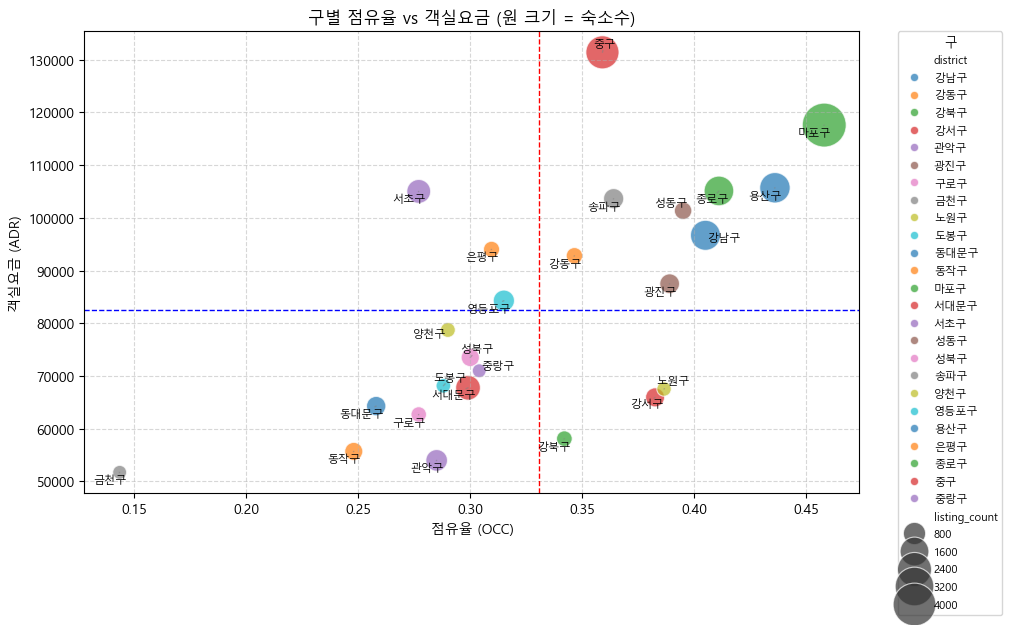

In [ ]:
from adjustText import adjust_text

# 평균 계산
x_median = district_stats['ttm_occupancy_median'].mean()
y_median = district_stats['ttm_avg_rate_median'].mean()

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=district_stats,
    x='ttm_occupancy_median',
    y='ttm_avg_rate_median',
    hue='district',
    size='listing_count',
    sizes=(100, 1000),
    palette='tab10',
    alpha=0.7,
    legend='brief'
)

# 범례 오른쪽에 고정 + 텍스트 크기 조정
ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc=2,
    borderaxespad=0.,
    title='구',
    fontsize=8,
    title_fontsize=9
)

# 점유율 평균과 RevPAR 평균 점선 추가
ax.axvline(x=x_median, color='red', linestyle='--', linewidth=1, label='점유율 중앙값')
ax.axhline(y=y_median, color='blue', linestyle='--', linewidth=1, label='객실요금 중앙값')

# 텍스트 객체 생성 (각 점 위)
texts = []
for i, row in district_stats.iterrows():
    texts.append(
        plt.text(
            row['ttm_occupancy_median'],
            row['ttm_avg_rate_median'],
            row['district'],
            fontsize=8,
            ha='center',
            va='center',
            color='black'
        )
    )

# adjustText로 겹치지 않게 배치
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5))

# 레이블, 제목
plt.xlabel('점유율 (OCC)')
plt.ylabel('객실요금 (ADR)')
plt.title('구별 점유율 vs 객실요금 (원 크기 = 숙소수)')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

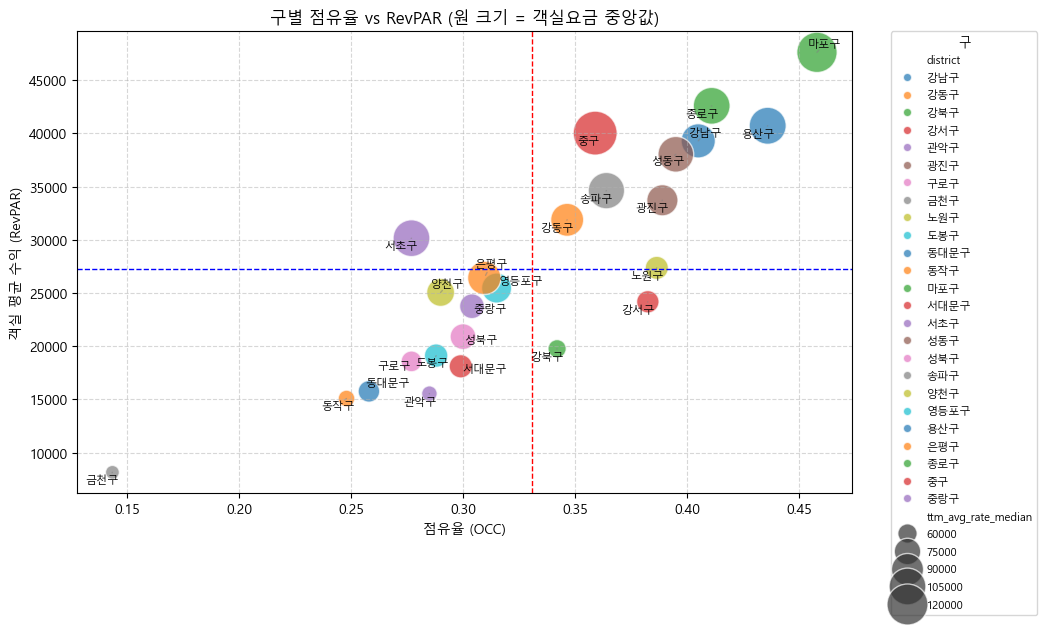

In [ ]:
from adjustText import adjust_text

# 평균 계산
x_median = district_stats['ttm_occupancy_median'].mean()
y_median = district_stats['ttm_revpar_median'].mean()

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=district_stats,
    x='ttm_occupancy_median',
    y='ttm_revpar_median',
    hue='district',
    size='ttm_avg_rate_median',
    sizes=(100, 1000),
    palette='tab10',
    alpha=0.7,
    legend='brief'
)

# 범례 오른쪽에 고정 + 텍스트 크기 조정
ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc=2,
    borderaxespad=0.,
    title='구',
    fontsize=8,
    title_fontsize=9
)

# 점유율 평균과 RevPAR 평균 점선 추가
ax.axvline(x=x_median, color='red', linestyle='--', linewidth=1, label='점유율 중앙값')
ax.axhline(y=y_median, color='blue', linestyle='--', linewidth=1, label='RevPAR 중앙값')

# 텍스트 객체 생성 (각 점 위)
texts = []
for i, row in district_stats.iterrows():
    texts.append(
        plt.text(
            row['ttm_occupancy_median'],
            row['ttm_revpar_median'],
            row['district'],
            fontsize=8,
            ha='center',
            va='center',
            color='black'
        )
    )

# adjustText로 겹치지 않게 배치
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5))

# 레이블, 제목
plt.xlabel('점유율 (OCC)')
plt.ylabel('객실 평균 수익 (RevPAR)')
plt.title('구별 점유율 vs RevPAR (원 크기 = 객실요금 중앙값)')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### 점유율과 수익이 높은 곳 vs 점유율을 높지만 수익이 낮은 곳 vs 점유율과 수익 모두 낮은 곳 비교
- 점유율과 수익이 높은 곳: 종로구, 마포구, 용산구
- 점유율은 높지만 수익이 낮은 곳: 노원구, 강서구
- 점유율과 수익이 낮은 곳: 금천구

In [ ]:
focus_districts = ['종로구', '마포구', '용산구', '강북구', '강서구', '노원구', '금천구', '동작구', '동대문구', '서초구']
gdf_focus = gdf_active_airbnb_trans[gdf_active_airbnb_trans['district'].isin(focus_districts)]

# 조건 정의
conditions = [
    gdf_focus['district'].isin(['종로구', '마포구', '용산구']),  # 점유율 & 수익 높음
    gdf_focus['district'].isin(['강북구', '강서구', '노원구']),  # 점유율 대비 낮은 수익
    gdf_focus['district'].isin(['서초구']),  # 점유율 대비 높은 수익
    gdf_focus['district'].isin(['금천구', '동작구', '동대문구'])  # 점유율 & 수익 낮음
]

# 조건별 라벨
choices = [
    '점유율&수익 높은 지역',
    '점유율대비 낮은 수익 지역',
    '점유율대비 높은 수익 지역',
    '점유율&수익 낮은 지역'
]

# district_label 컬럼 생성
gdf_focus['district_label'] = np.select(conditions, choices, default='기타')

# 결과 확인
gdf_focus[['district', 'district_label']].drop_duplicates()

,district,district_label
2,종로구,점유율&수익 높은 지역
6,마포구,점유율&수익 높은 지역
15,용산구,점유율&수익 높은 지역
199,서초구,점유율대비 높은 수익 지역
204,동대문구,점유율&수익 낮은 지역
726,동작구,점유율&수익 낮은 지역
1229,강북구,점유율대비 낮은 수익 지역
1488,강서구,점유율대비 낮은 수익 지역
2319,노원구,점유율대비 낮은 수익 지역
4918,금천구,점유율&수익 낮은 지역


In [ ]:
# features = [
#     'baths', 'bedrooms', 'beds', 'cleaning_fee', 'extra_guest_fee',
#     'guests', 'instant_book', 'min_nights',
#     'num_reviews', 'photos_count', 'superhost', 'rating_overall'
# ]

# # 1. 그룹별 평균 계산
# feature_means = gdf_focus.groupby('district_label')[features].median().reset_index()

# # 2. 시각화를 위해 Melting
# melted_features = feature_means.melt(
#     id_vars='district_label',
#     var_name='Feature',
#     value_name='Average_Value'
# )

In [ ]:
# 1. 컬럼별 집계 방식 정의
# - 비율이 중요한 이진 변수는 'mean'
# - 전형적인 수치가 중요한 지표는 'median'
agg_dict = {
    'instant_book': 'mean',
    'superhost': 'mean',
    'baths': 'median',
    'bedrooms': 'median',
    'beds': 'median',
    'cleaning_fee': 'median',
    'extra_guest_fee': 'median',
    'guests': 'median',
    'min_nights': 'median',
    'num_reviews': 'median',
    'photos_count': 'median',
    'rating_overall': 'median'
}

# 2. 그룹별 집계 수행
feature_stats = gdf_focus.groupby('district_label').agg(agg_dict).reset_index()

# 3. 시각화를 위해 Melting
melted_features = feature_stats.melt(
    id_vars='district_label',
    var_name='Feature',
    value_name='Stat_Value'
)

# 결과 확인
display(feature_stats)

,district_label,instant_book,superhost,baths,bedrooms,beds,cleaning_fee,extra_guest_fee,guests,min_nights,num_reviews,photos_count,rating_overall
0,점유율&수익 낮은 지역,0.31,0.41,1.00,1.00,1.00,9681.00,0.00,2.00,2.00,16.00,22.00,4.75
1,점유율&수익 높은 지역,0.34,0.53,1.00,1.00,2.00,16596.00,0.00,3.00,2.00,36.00,27.00,4.80
2,점유율대비 낮은 수익 지역,0.24,0.60,1.00,1.00,1.00,12447.00,0.00,2.00,1.00,24.00,20.00,4.83
3,점유율대비 높은 수익 지역,0.33,0.49,1.00,1.00,1.00,0.00,0.00,2.00,1.00,24.00,21.00,4.78


In [ ]:
melted_features.head()

,district_label,Feature,Stat_Value
0,점유율&수익 낮은 지역,instant_book,0.31
1,점유율&수익 높은 지역,instant_book,0.34
2,점유율대비 낮은 수익 지역,instant_book,0.24
3,점유율대비 높은 수익 지역,instant_book,0.33
4,점유율&수익 낮은 지역,superhost,0.41


- 인사이트: 리뷰 개수와 사진수로 숙소 신뢰성을 확보해야 높은 수익을 확보할 수 있으며, 확실히 리뷰 개수가 적은곳은 수익 발생이 적다.

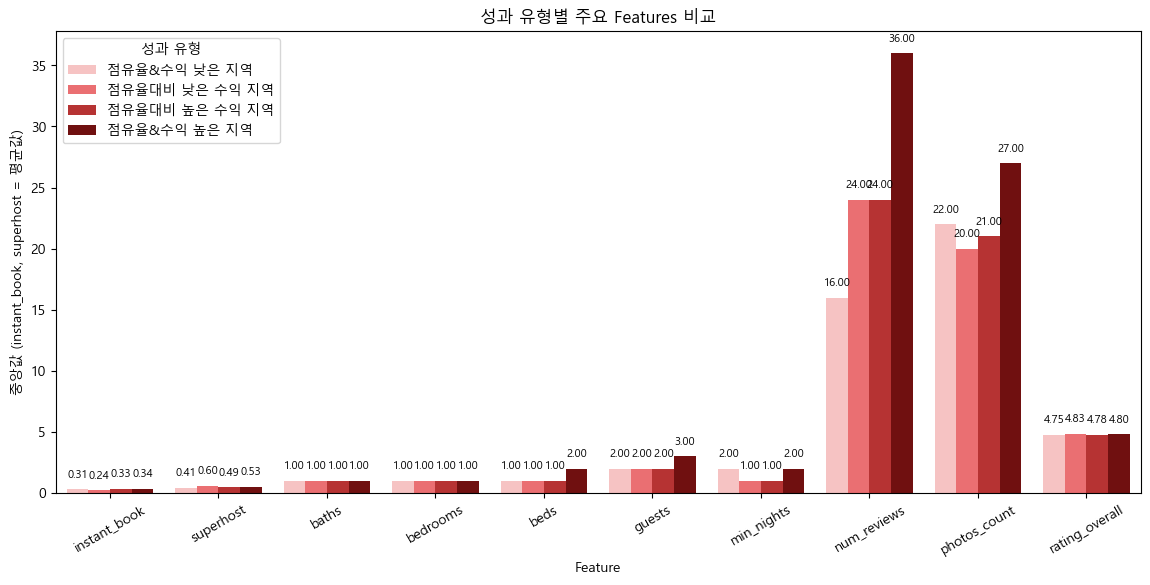

In [ ]:
# 'cleaning_fee', 'extra_guest_fee'는 값 범위가 너무 커서 제외
melted_features_filtered = melted_features[~melted_features['Feature'].isin(['cleaning_fee', 'extra_guest_fee'])]

# hue 순서 지정
hue_order = ['점유율&수익 낮은 지역', '점유율대비 낮은 수익 지역', '점유율대비 높은 수익 지역', '점유율&수익 높은 지역']

plt.figure(figsize=(14, 6))
ax = sns.barplot(
    data=melted_features_filtered,
    x='Feature',
    y='Stat_Value',
    hue='district_label',
    hue_order=hue_order,  # ← 여기서 순서 지정
    palette=['#FFBABA', '#FF5A5F', "#CC1D1D", '#800000']  # 색상 순서도 맞춰서 변경
)

# 막대 위에 숫자 표시 (높이가 0보다 큰 경우만)
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # 0보다 큰 경우만 표시
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + 0.02 * melted_features_filtered['Stat_Value'].max(),
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.xticks(rotation=30)
plt.title('성과 유형별 주요 Features 비교')
plt.ylabel('중앙값 (instant_book, superhost = 평균값)')
plt.xlabel('Feature')
plt.legend(title='성과 유형')
plt.show()

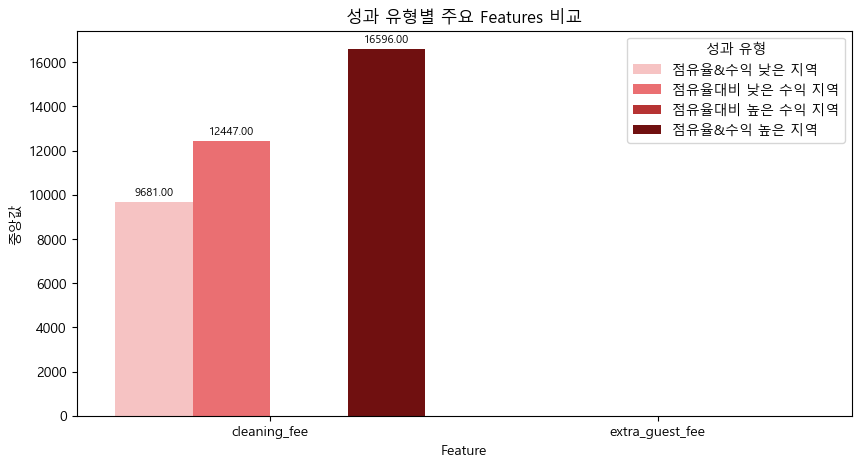

In [ ]:
# 'cleaning_fee', 'extra_guest_fee'는 값 범위가 너무 커서 제외
melted_features_filtered = melted_features[melted_features['Feature'].isin(['cleaning_fee', 'extra_guest_fee'])]

# hue 순서 지정
hue_order = ['점유율&수익 낮은 지역', '점유율대비 낮은 수익 지역', '점유율대비 높은 수익 지역', '점유율&수익 높은 지역']

plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=melted_features_filtered,
    x='Feature',
    y='Stat_Value',
    hue='district_label',
    hue_order=hue_order,  # ← 여기서 순서 지정
    palette=['#FFBABA', '#FF5A5F', "#CC1D1D", '#800000']  # 색상 순서도 맞춰서 변경
)

# 막대 위에 숫자 표시 (높이가 0보다 큰 경우만)
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # 0보다 큰 경우만 표시
        ax.text(
            p.get_x() + p.get_width() / 2.,
            height + 0.01 * melted_features_filtered['Stat_Value'].max(),
            f'{height:.2f}',
            ha='center',
            va='bottom',
            fontsize=8
        )

plt.title('성과 유형별 주요 Features 비교')
plt.ylabel('중앙값')
plt.xlabel('Feature')
plt.legend(title='성과 유형')
plt.show()

--- [사용자 정의 3그룹별 ADR vs 청소비 격차 비교] ---


,ADR_Gap_%,Cleaning_Gap_%
segment,,
district_label,,
점유율&수익 낮은 지역,116.00,157.10
점유율&수익 높은 지역,96.50,340.00
점유율대비 낮은 수익 지역,93.80,100.00
점유율대비 높은 수익 지역,28.80,-100.00


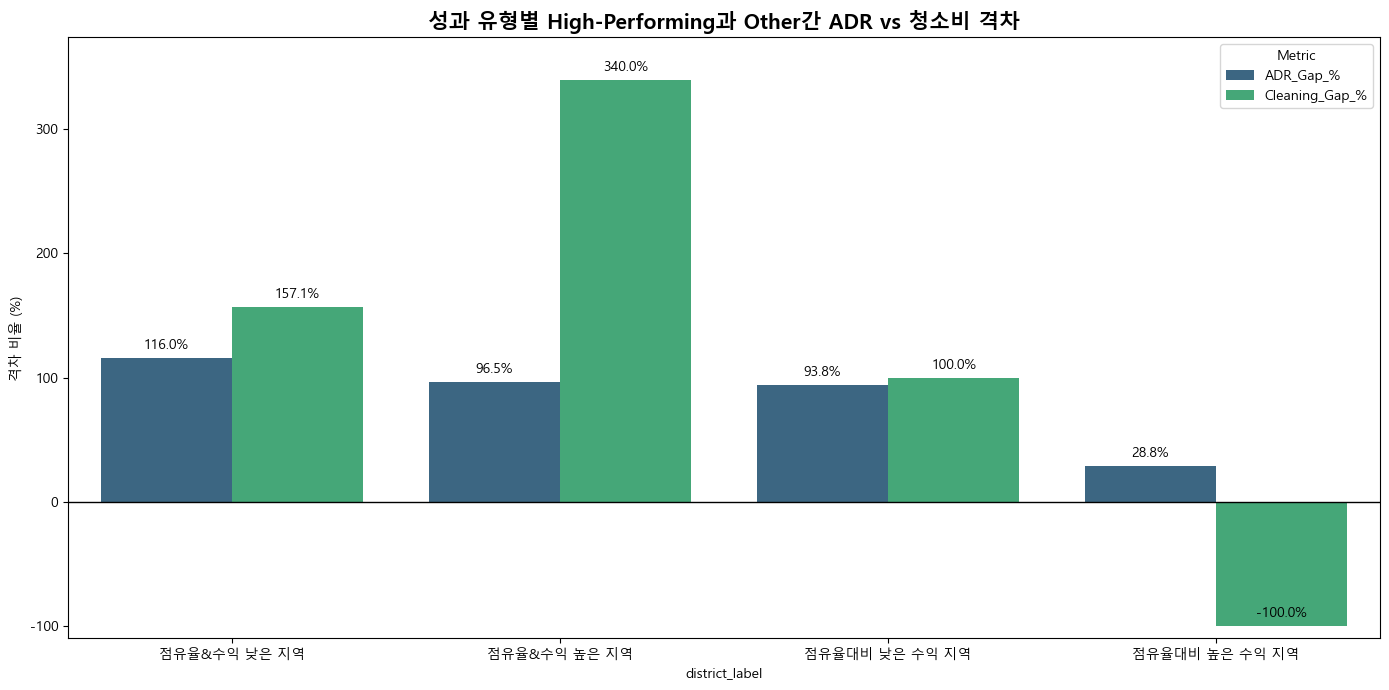

In [ ]:
# 1. gdf_focus에서 '구 - 라벨' 매핑 정보만 추출 (중복 제거)
district_mapping = gdf_focus[['district', 'district_label']].drop_duplicates()

# 2. 전체 데이터(gdf_active_airbnb)에 라벨 정보 합치기
# (이제 gdf_labeled 에는 district_label, segment, ttm_avg_rate, cleaning_fee가 모두 들어있게 됩니다)
gdf_labeled = pd.merge(gdf_active_airbnb_trans, district_mapping, on='district', how='inner')

# 3. 그룹별(district_label) & 성과별(segment) 중앙값 집계
label_price_summary = gdf_labeled.groupby(['district_label', 'segment'])[['ttm_avg_rate', 'cleaning_fee']].median().unstack()

# 4. 격차(Gap %) 계산 (분모가 0인 경우 1로 치환하여 inf 방지)
label_price_summary['ADR_Gap_%'] = (
    (label_price_summary[('ttm_avg_rate', 'High-Performing')] /
     label_price_summary[('ttm_avg_rate', 'Other')].replace(0, 1) - 1) * 100
).round(1)

label_price_summary['Cleaning_Gap_%'] = (
    (label_price_summary[('cleaning_fee', 'High-Performing')] /
     label_price_summary[('cleaning_fee', 'Other')].replace(0, 1) - 1) * 100
).round(1)

# 5. 결과 확인
print("--- [사용자 정의 3그룹별 ADR vs 청소비 격차 비교] ---")
display(label_price_summary[['ADR_Gap_%', 'Cleaning_Gap_%']])

# 6. 시각화용 데이터 정리
gap_df = label_price_summary[['ADR_Gap_%', 'Cleaning_Gap_%']].reset_index()
gap_df.columns = ['district_label', 'ADR_Gap_%', 'Cleaning_Gap_%']
melted_gap = gap_df.melt(id_vars='district_label', var_name='Metric', value_name='Gap_Percentage')

# 7. 시각화
plt.figure(figsize=(14, 7))
sns.barplot(data=melted_gap, x='district_label', y='Gap_Percentage', hue='Metric', palette='viridis')

plt.title('성과 유형별 High-Performing과 Other간 ADR vs 청소비 격차', fontsize=15, fontweight='bold')
plt.axhline(0, color='black', linewidth=1)
plt.ylabel('격차 비율 (%)')

y_min = melted_gap['Gap_Percentage'].min()
y_max = melted_gap['Gap_Percentage'].max()

plt.ylim(y_min * 1.1, y_max * 1.1)

# 막대 위에 수치 표시
for p in plt.gca().patches:
    height = p.get_height()
    if abs(height) > 0:   # 0은 제외
        plt.gca().annotate(
            f'{height:.1f}%',
            (p.get_x() + p.get_width() / 2., height),
            ha='center',
            va='center',
            xytext=(0, 9),
            textcoords='offset points'
        )

plt.tight_layout()
plt.show()

In [ ]:
BASE_DIR = os.getcwd()
CSV_FOLDER_DIR = os.path.join(BASE_DIR, "완전최종_전처리완료_CSV모음")
GPKG_FOLDER_DIR = os.path.join(BASE_DIR, "완전최종_전처리완료_GPKG모음")
MERGE_FOLDER_DIR = os.path.join(BASE_DIR, "병합완료")

In [ ]:
DATA_DIR = os.path.join(MERGE_FOLDER_DIR, "서울시 상권분석서비스(영역-행정동)/서울시 상권분석서비스(영역-행정동).shp")
gdf_dong = gpd.read_file(DATA_DIR)
gdf_dong_5179 = gdf_dong.to_crs(epsg=5179)
gdf_dong_5179

,ADSTRD_CD,ADSTRD_NM,XCNTS_VALU,YDNTS_VALU,RELM_AR,geometry
0,11110515,청운효자동,197342.00,453874.00,2568432.00,"POLYGON ((953343.391 1955051.035, 953348.228 1..."
1,11110530,사직동,197383.00,452705.00,1158536.00,"POLYGON ((953553.932 1953335.742, 953555.211 1..."
2,11110540,삼청동,198340.00,454312.00,1479255.00,"POLYGON ((953844.082 1955492.178, 953858.644 1..."
3,11110550,부암동,196781.00,455266.00,2274739.00,"POLYGON ((952490.38 1956548.821, 952497.594 19..."
4,11110560,평창동,197186.00,457344.00,8947328.00,"POLYGON ((953683.828 1959209.871, 953665.283 1..."
...,...,...,...,...,...,...
420,11740700,둔촌2동,213015.00,447989.00,1550455.00,"POLYGON ((969658.021 1948737.38, 969656.712 19..."
421,11740640,성내1동,211097.00,447696.00,663675.00,"POLYGON ((966915.362 1948129.091, 966937.558 1..."
422,11740650,성내2동,211287.00,448330.00,625147.00,"POLYGON ((966822.13 1948873.978, 966823.557 19..."
423,11740660,성내3동,211824.00,447659.00,647356.00,"POLYGON ((967650.379 1946978.998, 967646.79 19..."


In [ ]:
# 공간 조인: point가 polygon 안에 있으면 ADSTRD_NM 가져오기
gdf_airbnb_active_dong = gpd.sjoin(
    gdf_active_airbnb_trans,
    gdf_dong_5179[['ADSTRD_NM', 'geometry']],
    how='left',          # 좌표가 polygon 밖이면 NaN
    predicate='within'   # point가 polygon 안에 있는지
)

# 결과 확인
gdf_airbnb_active_dong = gdf_airbnb_active_dong.rename(
    columns={
        'ADSTRD_NM': '행정동'
    }
)
gdf_airbnb_active_dong

,index,baths,bedrooms,beds,cleaning_fee,country,currency,extra_guest_fee,guests,instant_book,...,log_l90d_revenue,log_l90d_revpar,log_ttm_avg_rate,log_ttm_revenue,log_ttm_revpar,rating_missing_flag,rating_overall_filled,segment,index_right,행정동
0,0,6.00,10,10,345745,South Korea,KRW,0,16,False,...,17.02,12.53,13.21,18.47,12.57,0,5.00,High-Performing,184,연희동
1,1,6.00,10,10,345745,South Korea,KRW,0,16,False,...,17.02,12.53,13.21,18.47,12.57,0,5.00,High-Performing,20,필동
2,2,3.00,3,4,117553,South Korea,KRW,0,7,True,...,17.02,12.53,13.21,18.47,12.57,0,4.98,High-Performing,7,가회동
3,3,2.00,2,2,38723,South Korea,KRW,0,4,False,...,17.02,12.53,13.21,18.47,12.57,0,5.00,High-Performing,100,응봉동
4,4,1.00,2,2,37340,South Korea,KRW,0,4,False,...,17.02,12.53,13.21,18.47,12.57,0,4.92,High-Performing,8,종로1·2·3·4가동
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19998,1.00,1,1,0,South Korea,KRW,0,1,False,...,0.00,0.00,9.83,9.86,3.98,0,4.33,Other,143,삼선동
19996,19999,0.00,0,1,49787,South Korea,KRW,0,0,False,...,0.00,0.00,9.70,9.81,3.93,0,4.90,Other,183,신촌동
19997,20000,1.00,1,1,0,South Korea,KRW,0,1,False,...,0.00,0.00,9.81,9.75,3.88,0,4.86,Other,143,삼선동
19998,20001,0.00,0,1,0,South Korea,KRW,0,0,False,...,0.00,0.00,9.84,9.72,3.84,0,4.33,Other,32,동선동


In [ ]:
dong_stats = gdf_airbnb_active_dong.groupby('행정동').agg(
    ttm_occupancy_median=('ttm_occupancy', 'median'),
    ttm_revpar_median=('ttm_revpar', 'median'),
    ttm_avg_rate_median=('ttm_avg_rate', 'median'),
    listing_count=('ttm_occupancy', 'count')  # 또는 'id' 컬럼 사용 가능
).reset_index()
dong_stats

,행정동,ttm_occupancy_median,ttm_revpar_median,ttm_avg_rate_median,listing_count
0,가락1동,0.26,20556.60,132252.96,5
1,가락2동,0.29,27068.00,85376.99,6
2,가락본동,0.29,33013.40,94657.48,16
3,가리봉동,0.10,3291.00,31462.21,13
4,가산동,0.21,12593.30,72537.12,20
...,...,...,...,...,...
401,효창동,0.38,33996.70,81472.44,22
402,후암동,0.41,39027.05,121892.54,162
403,휘경1동,0.14,10314.50,60383.11,13
404,휘경2동,0.54,51832.60,97679.45,6


- 순위 점수 산정을 위한 정규화(두 변수의 범위와 단위를 맞추기 위해 min-max 스케일 사용)

In [ ]:
# Min-Max 정규화 함수
def minmax(series):
    return (series - series.min()) / (series.max() - series.min())

# 정규화 적용
dong_stats['occ_norm'] = minmax(dong_stats['ttm_occupancy_median'])
dong_stats['revpar_norm'] = minmax(dong_stats['ttm_revpar_median'])

# 가중합 점수 계산
dong_stats['rank_score'] = (
    dong_stats['occ_norm'] * 0.4 +
    dong_stats['revpar_norm'] * 0.6
)

# 정렬
dong_stats.sort_values('rank_score', ascending=False)

,행정동,ttm_occupancy_median,ttm_revpar_median,ttm_avg_rate_median,listing_count,occ_norm,revpar_norm,rank_score
8,가회동,0.58,157447.65,295694.58,118,0.70,1.00,0.88
285,원효로1동,0.76,95532.40,136412.38,78,0.92,0.61,0.73
16,개포2동,0.82,77608.50,92825.44,1,1.00,0.49,0.69
361,천호1동,0.59,92363.20,149087.00,15,0.72,0.59,0.64
161,삼청동,0.50,79310.80,197218.52,81,0.60,0.50,0.54
...,...,...,...,...,...,...,...,...
93,망우본동,0.04,1174.55,24154.63,4,0.04,0.00,0.02
81,독산3동,0.03,1511.10,44809.56,21,0.03,0.01,0.01
152,사당4동,0.02,1121.50,41740.47,5,0.01,0.00,0.01
51,내곡동,0.01,1144.30,110857.19,1,0.00,0.00,0.00


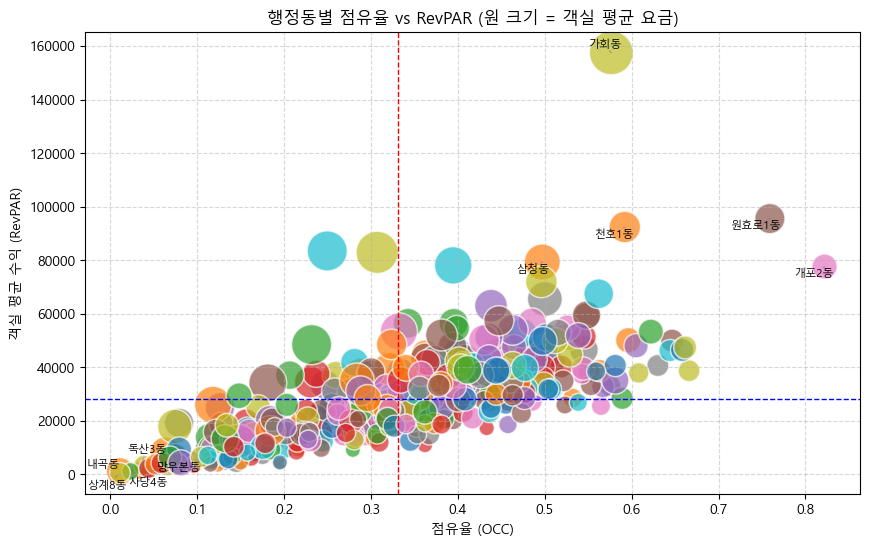

In [ ]:
# 평균 계산
x_mean = dong_stats['ttm_occupancy_median'].mean()
y_mean = dong_stats['ttm_revpar_median'].mean()

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=dong_stats,
    x='ttm_occupancy_median',
    y='ttm_revpar_median',
    hue='행정동',
    size='ttm_avg_rate_median',
    sizes=(100, 1000),
    palette='tab10',
    alpha=0.7,
    legend=False
)

# # 범례 오른쪽에 고정 + 텍스트 크기 조정
# ax.legend(
#     bbox_to_anchor=(1.05, 1),
#     loc=2,
#     borderaxespad=0.,
#     title='구',
#     fontsize=8,
#     title_fontsize=9
# )

# 점유율 중앙값과 RevPAR 중앙값 점선 추가
ax.axvline(x=x_mean, color='red', linestyle='--', linewidth=1, label='점유율 중앙값')
ax.axhline(y=y_mean, color='blue', linestyle='--', linewidth=1, label='RevPAR 중앙값')

# RevPAR 상위 5개
top5 = dong_stats.nlargest(5, 'rank_score')

# RevPAR 하위 5개
bottom5 = dong_stats.nsmallest(5, 'rank_score')

# 합치기
highlight = pd.concat([top5, bottom5])

# 텍스트 객체 생성 (각 점 위)
texts = []
for i, row in highlight.iterrows():
    texts.append(
        plt.text(
            row['ttm_occupancy_median'],
            row['ttm_revpar_median'],
            row['행정동'],
            fontsize=8,
            ha='center',
            va='center',
            color='black'
        )
    )

# adjustText로 겹치지 않게 배치
adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5))

# 레이블, 제목
plt.xlabel('점유율 (OCC)')
plt.ylabel('객실 평균 수익 (RevPAR)')
plt.title('행정동별 점유율 vs RevPAR (원 크기 = 객실 평균 요금)')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# 상위 5개 행정동의 자치구 확인
gdf_airbnb_active_dong[gdf_airbnb_active_dong['행정동'].isin(top5['행정동'])]['district'].unique()

array(['종로구', '용산구', '강동구', '강남구'], dtype=object)

In [ ]:
bottom5['행정동']

168    상계8동
51      내곡동
152    사당4동
81     독산3동
93     망우본동
Name: 행정동, dtype: object

In [ ]:
# 하위 5개 행정동의 자치구 확인
gdf_airbnb_active_dong[gdf_airbnb_active_dong['행정동'].isin(bottom5['행정동'])]['district'].unique()

array(['금천구', '동작구', '중랑구', '서초구', '노원구'], dtype=object)

In [ ]:
gpkg_files

['cctv.gpkg',
 '공중화장실.gpkg',
 '버스정류소_위치정보.gpkg',
 '상권_유동인구_직장인구_상주인구_상권변화지표.gpkg',
 '서울시_관광_명소_보완.gpkg',
 '서울시_관광숙박업_인허가_정보.gpkg',
 '서울시_문화행사정보.gpkg',
 '서울시_일반숙박업_인허가_정보.gpkg',
 '서울시_주요_120장소_목록.gpkg',
 '서울시_주요_공원.gpkg',
 '에어비앤비.gpkg',
 '지하철_시간대별평균유동인구.gpkg',
 '지하철_유동인구.gpkg',
 '지하철역사정보.gpkg',
 '치안센터.gpkg']

In [ ]:
# DATA_DIR = os.path.join(GPKG_FOLDER_DIR, "cctv.gpkg")
# gdf_cctv_gu = gpd.read_file(DATA_DIR)
DATA_DIR = os.path.join(GPKG_FOLDER_DIR, "버스정류소_위치정보.gpkg")
gdf_busstation = gpd.read_file(DATA_DIR)
DATA_DIR = os.path.join(GPKG_FOLDER_DIR, "서울시_관광_명소_보완.gpkg")
gdf_landmark = gpd.read_file(DATA_DIR)
DATA_DIR = os.path.join(GPKG_FOLDER_DIR, "서울시_관광숙박업_인허가_정보.gpkg")
gdf_tour_hotel = gpd.read_file(DATA_DIR)
DATA_DIR = os.path.join(GPKG_FOLDER_DIR, "서울시_일반숙박업_인허가_정보.gpkg")
gdf_nomal_motel = gpd.read_file(DATA_DIR)
DATA_DIR = os.path.join(GPKG_FOLDER_DIR, "서울시_주요_120장소_목록.gpkg")
gdf_120 = gpd.read_file(DATA_DIR)
DATA_DIR = os.path.join(GPKG_FOLDER_DIR, "서울시_주요_공원.gpkg")
gdf_park = gpd.read_file(DATA_DIR)
DATA_DIR = os.path.join(GPKG_FOLDER_DIR, "지하철역사정보.gpkg")
gdf_subway = gpd.read_file(DATA_DIR)
DATA_DIR = os.path.join(GPKG_FOLDER_DIR, "지하철_유동인구.gpkg")
gdf_subway_people = gpd.read_file(DATA_DIR)


In [ ]:
DATA_DIR = os.path.join(MERGE_FOLDER_DIR, "서울시 상권분석서비스(영역-자치구)/서울시 상권분석서비스(영역-자치구).shp")
gdf_gu = gpd.read_file(DATA_DIR)
gdf_gu_5179 = gdf_gu.to_crs(epsg=5179)
gdf_gu_5179

,SIGNGU_CD,SIGNGU_NM,XCNTS_VALU,YDNTS_VALU,RELM_AR,geometry
0,11110,종로구,197997.00,455039.00,23990643.00,"POLYGON ((953683.828 1959209.871, 953665.283 1..."
1,11140,중구,199639.00,451178.00,9990317.00,"POLYGON ((957890.386 1952616.746, 957909.908 1..."
2,11170,용산구,198224.00,447985.00,21892688.00,"POLYGON ((953114.222 1950746.999, 953114.218 1..."
3,11200,성동구,203628.00,450168.00,16817016.00,"POLYGON ((959381.837 1952723.894, 959416.042 1..."
4,11215,광진구,207577.00,449693.00,17049029.00,"POLYGON ((964825.058 1952633.25, 964875.576 19..."
5,11230,동대문구,204847.00,453608.00,14277373.00,"POLYGON ((961991.849 1956626.223, 961991.849 1..."
6,11260,중랑구,208203.00,455365.00,18537446.00,"POLYGON ((965698.531 1957987.355, 965753.533 1..."
7,11290,성북구,201547.00,456236.00,24578799.00,"POLYGON ((954470.101 1959788.502, 954491.157 1..."
8,11305,강북구,200988.00,460427.00,23638414.00,"POLYGON ((956318.948 1965174.728, 956401.551 1..."
9,11320,도봉구,202857.00,463273.00,20705585.00,"POLYGON ((957671.417 1966936.577, 957875.281 1..."


In [ ]:
# 서울시 CCTV 데이터 불러오기
DATA_DIR = os.path.join(MERGE_FOLDER_DIR, "CCTV정보_서울특별시.csv")
df_cctv = pd.read_csv(DATA_DIR, encoding='cp949')

gdf_cctv = gpd.GeoDataFrame(
    df_cctv,
    geometry=gpd.points_from_xy(df_cctv['WGS84경도'], df_cctv['WGS84위도']),
    crs="EPSG:4326"
)

gdf_cctv_5179 = gdf_cctv.to_crs(epsg=5179)
gdf_cctv_5179['X좌표(GRS80TM)'] = gdf_cctv_5179.geometry.x
gdf_cctv_5179['Y좌표(GRS80TM)'] = gdf_cctv_5179.geometry.y
gdf_cctv_5179.head(1)

,개방자치단체코드,관리번호,관리기관명,소재지도로명주소,소재지지번주소,설치목적구분,카메라대수,카메라화소수,촬영방면정보,보관일수,설치연월,관리기관전화번호,WGS84위도,WGS84경도,데이터기준일자,최종수정시점,geometry,X좌표(GRS80TM),Y좌표(GRS80TM)
0,3000000,202530000000800560,서울특별시 종로구청,서울특별시 종로구 자하문로17길 36,NaN,생활방범,4,200.00,360도 전방면,30.00,202301.00,02-2148-3033,37.58,126.97,2025-10-31,2025-10-23 14:47:04,POINT (953080.376 1953689.818),953080.38,1953689.82


In [ ]:
gdf_cctv_5179.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 57760 entries, 0 to 57759
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   개방자치단체코드      57760 non-null  int64   
 1   관리번호          57760 non-null  int64   
 2   관리기관명         57760 non-null  object  
 3   소재지도로명주소      51866 non-null  object  
 4   소재지지번주소       47781 non-null  object  
 5   설치목적구분        57760 non-null  object  
 6   카메라대수         57760 non-null  int64   
 7   카메라화소수        41470 non-null  float64 
 8   촬영방면정보        24972 non-null  object  
 9   보관일수          50238 non-null  float64 
 10  설치연월          36867 non-null  float64 
 11  관리기관전화번호      56786 non-null  object  
 12  WGS84위도       57760 non-null  float64 
 13  WGS84경도       57760 non-null  float64 
 14  데이터기준일자       57760 non-null  object  
 15  최종수정시점        57760 non-null  object  
 16  geometry      57760 non-null  geometry
 17  X좌표(GRS80TM)  57760 non-null  float64 
 18

### opportunity score
- 지섭님 코드 인용 -> 기회 '행정동' 먼저 산출

In [ ]:
active = gdf_active_airbnb_trans.copy()
active.columns

Index(['index', 'baths', 'bedrooms', 'beds', 'cleaning_fee', 'country',
       'currency', 'extra_guest_fee', 'guests', 'instant_book',
       'l90d_avg_rate', 'l90d_occupancy', 'l90d_revenue', 'l90d_revpar',
       'listing_type', 'locality', 'min_nights', 'num_reviews', 'photos_count',
       'rating_overall', 'region', 'room_type', 'superhost', 'ttm_avg_rate',
       'ttm_occupancy', 'ttm_revenue', 'ttm_revpar', 'district', 'X좌표(WGS84)',
       'Y좌표(WGS84)', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)', 'geometry', 'baths_w',
       'bedrooms_w', 'beds_w', 'min_nights_w', 'cleaning_fee_w',
       'extra_guest_fee_w', 'num_reviews_w', 'photos_count_w',
       'l90d_avg_rate_w', 'l90d_revenue_w', 'l90d_revpar_w', 'ttm_avg_rate_w',
       'ttm_revenue_w', 'ttm_revpar_w', 'log_cleaning_fee',
       'log_extra_guest_fee', 'log_num_reviews', 'log_photos_count',
       'log_l90d_avg_rate', 'log_l90d_revenue', 'log_l90d_revpar',
       'log_ttm_avg_rate', 'log_ttm_revenue', 'log_ttm_revpar',
       'rati

In [ ]:
dong_gdf = gdf_dong_5179.copy()
dong_gdf.head()

# 10) 행정동 드릴다운: 포인트 -> 행정동 spatial join -> 동 요약 + 동 밀도(면적 정규화)
ROOT = Path.cwd()
OUT = ROOT / "outputs_최종"
OUT.mkdir(exist_ok=True)
(OUT / "reports").mkdir(exist_ok=True)

# 행정동명 컬럼 자동 탐색(데이터마다 이름이 다름)
name_candidates = [c for c in dong_gdf.columns if "NM" in c.upper() and c != "geometry"]
dong_name_col = None
for c in ["ADSTRD_NM","ADM_DR_NM","ADM_NM","DONG_NM","H_DNG_NM"] + name_candidates:
    if c in dong_gdf.columns:
        dong_name_col = c
        break
if dong_name_col is None:
    raise ValueError(f"행정동명 컬럼을 찾지 못했습니다. 컬럼 후보: {name_candidates}")

# 면적(km2)
if "RELM_AR" in dong_gdf.columns:
    dong_gdf["area_km2"] = dong_gdf["RELM_AR"].astype(float) / 1e6
else:
    dong_m = dong_gdf.to_crs(epsg=5179)
    dong_gdf["area_km2"] = (dong_m.geometry.area / 1e6).values

dong_gdf = dong_gdf.rename(columns={dong_name_col:"dong"}).copy()

# 포인트 생성(WGS84 -> 행정동 CRS로 변환)
pts = gpd.GeoDataFrame(
    active.copy(),
    geometry=gpd.points_from_xy(active["X좌표(WGS84)"], active["Y좌표(WGS84)"]),
    crs="EPSG:4326"
).to_crs(dong_gdf.crs)

# spatial join
joined = gpd.sjoin(pts, dong_gdf[["dong","area_km2","geometry"]], how="left", predicate="within")

miss_rate = joined["dong"].isna().mean()
print(f"행정동 조인 누락률: {miss_rate:.2%} (너무 높으면 좌표/CRS/QC 확인 필요)")

# 동 요약(표본수 필터 포함)
summary_dong = joined.groupby(["district","dong"]).agg(
    active_listings=("district","size"),
    revpar_med=("ttm_revpar","median"),
    occ_med=("ttm_occupancy","median"),
    adr_med=("ttm_avg_rate","median"),
    revenue_med=("ttm_revenue","median"),
    instant_rate=("instant_book","mean"),
    superhost_rate=("superhost","mean"),
    min_nights_med=("min_nights","median"),
    rating_med=("rating_overall","median"),
    photos_med=("photos_count","median"),
    reviews_med=("num_reviews","median"),
    area_km2=("area_km2","first"),
).reset_index()

summary_dong["density_per_km2"] = summary_dong["active_listings"] / summary_dong["area_km2"]

# 표본 너무 작은 동은 노이즈가 큼(기본 30, 필요 시 조정)
MIN_N = 0
summary_dong = summary_dong[summary_dong["active_listings"] >= MIN_N].copy()

summary_dong.to_csv(OUT / "dong_summary_scored_base.csv", index=False, encoding="utf-8-sig")
summary_dong.sort_values(["district","revpar_med"], ascending=[True,False]).head()


행정동 조인 누락률: 0.00% (너무 높으면 좌표/CRS/QC 확인 필요)


,district,dong,active_listings,revpar_med,occ_med,adr_med,revenue_med,instant_rate,superhost_rate,min_nights_med,rating_med,photos_med,reviews_med,area_km2,density_per_km2
1,강남구,개포2동,1,77608.50,0.82,92825.44,28327119.00,0.00,1.00,2.00,4.96,11.00,71.00,2.24,0.45
11,강남구,삼성2동,168,65484.35,0.50,183858.67,23062675.00,0.23,0.54,2.00,4.83,29.00,27.50,1.24,135.24
21,강남구,청담동,41,57354.50,0.45,135399.44,20934384.00,0.29,0.61,2.00,4.84,21.00,30.00,2.33,17.60
10,강남구,삼성1동,82,53395.95,0.33,209385.82,19489515.50,0.24,0.51,2.00,4.83,26.00,24.50,1.94,42.17
12,강남구,세곡동,13,46467.90,0.66,77752.99,16960773.00,0.38,0.62,1.00,4.82,18.00,84.00,6.37,2.04


In [ ]:
# ---- 정규화(Score용): 퍼센타일 랭크(0~1) 기반(권장, 안정적)
def pct_rank(s: pd.Series) -> pd.Series:
    return s.rank(pct=True, method="average")

# (입력) summary_dong: 행정동 요약 테이블
#  - 최소 필요 컬럼: district, dong, revpar_med, revenue_med, density_per_km2, instant_rate, superhost_rate
sc_base = summary_dong.copy()

# 1) 정규화 피처(0~1) 생성
sc_base["r_revpar"] = pct_rank(sc_base["revpar_med"])
sc_base["r_revenue"] = pct_rank(sc_base["revenue_med"])
sc_base["r_competition"] = 1 - pct_rank(sc_base["density_per_km2"])  # 경쟁(낮을수록 좋음)
sc_base["r_instant"] = pct_rank(sc_base["instant_rate"])
sc_base["r_superhost"] = pct_rank(sc_base["superhost_rate"])

sc_base["score_performance"] = 0.5*sc_base["r_revpar"] + 0.5*sc_base["r_revenue"]
sc_base["score_ops"] = 0.5*sc_base["r_instant"] + 0.5*sc_base["r_superhost"]
# 표본 수 기반 신뢰도 weight(추가 코드)
N_REF = 3  # 신뢰 기준 (3개 이상이면 full weight(깎이는 점수 없음))
sc_base["reliability_weight"] = (sc_base["active_listings"] / N_REF).clip(upper=1)

# 2) 사분면(성과 vs 경쟁) — 가중치와 무관(발표 방어 포인트)
rev_cut = sc_base["revpar_med"].median()
den_cut = sc_base["density_per_km2"].median()

def quadrant(row):
    hi_rev = row["revpar_med"] >= rev_cut
    hi_den = row["density_per_km2"] >= den_cut
    if hi_rev and (not hi_den): return "고성과-저경쟁(기회)"
    if hi_rev and hi_den: return "고성과-고경쟁(레드오션)"
    if (not hi_rev) and (not hi_den): return "저성과-저경쟁(미성숙)"
    return "저성과-고경쟁(데드존)"

sc_base["quadrant"] = sc_base.apply(quadrant, axis=1)

# 3) Opportunity Score: 베이스라인 + 민감도 3시나리오(발표용, 너무 많으면 산으로 감)
W_SCENARIOS = {
    "baseline":   {"performance": 0.50, "competition": 0.30, "ops": 0.20},
    "perf_heavy": {"performance": 0.60, "competition": 0.25, "ops": 0.15},
    "comp_heavy": {"performance": 0.45, "competition": 0.40, "ops": 0.15},
    "ops_heavy":  {"performance": 0.45, "competition": 0.25, "ops": 0.30},
}

def apply_weights(sc_in: pd.DataFrame, w: dict) -> pd.DataFrame:
    sc = sc_in.copy()
    # sc["opportunity_score"] = (
    #     w["performance"]*sc["score_performance"] +
    #     w["competition"]*sc["r_competition"] +
    #     w["ops"]*sc["score_ops"]
    # )

    # 숙소 개수 가중치 추가
    base_score = (
        w["performance"]*sc["score_performance"] +
        w["competition"]*sc["r_competition"] +
        w["ops"]*sc["score_ops"]
        )
    sc["opportunity_score"] = base_score * sc["reliability_weight"]

    sc["opportunity_rank"] = sc["opportunity_score"].rank(ascending=False, method="min").astype(int)
    return sc

# 4) 시나리오별 TopN 비교표(방어용)
TOPN = 10
scenario_top = {}
scenario_sc = {}

for name, w in W_SCENARIOS.items():
    scn = apply_weights(sc_base, w)
    scenario_sc[name] = scn # 시나리오별 행정동별 opportunity_rank 컬럼이 추가된 데이터프레임
    top = (scn.sort_values("opportunity_score", ascending=False)
              .head(TOPN)[["district","dong","opportunity_score","opportunity_rank","quadrant"]]
              .copy())
    top["scenario"] = name
    scenario_top[name] = top # 시나리오별 top10의 행정동 데이터프레임을 딕셔너리에 담음.

# --- (A) TopN 비교 표(행정동) 생성
# union key
# 시나리오별 TopN에 선정된 자치구-행정동의 시나리오별 opportunity_rank와 opportunity_score 보여주는 데이터 프레임
keys = set()
for name, t in scenario_top.items():
    keys |= set(zip(t["district"], t["dong"])) # 튜플을 집합으로 만듬. |= → 합집합 연산자

rows = []
for (dist, dong) in sorted(keys):
    row = {"district": dist, "dong": dong}
    for name, t in scenario_top.items():
        m = t[(t["district"]==dist) & (t["dong"]==dong)]
        if len(m) == 0:
            row[f"{name}_rank"] = np.nan
            row[f"{name}_score"] = np.nan
        else:
            row[f"{name}_rank"] = int(m["opportunity_rank"].iloc[0])
            row[f"{name}_score"] = float(m["opportunity_score"].iloc[0])
    rows.append(row)

sens_topN_compare = pd.DataFrame(rows)

# baseline rank 기준으로 정렬(없으면 뒤로)
sens_topN_compare = sens_topN_compare.sort_values(
    by=["baseline_rank","district","dong"],
    ascending=[True, True, True],
    na_position="last"
).reset_index(drop=True)

# overlap 요약(= baseline TopN 중 각 시나리오에서도 TopN 유지된 개수)
baseline_set = set(zip(scenario_top["baseline"]["district"], scenario_top["baseline"]["dong"]))
overlap_summary = []
for name in ["perf_heavy","comp_heavy","ops_heavy"]:
    sset = set(zip(scenario_top[name]["district"], scenario_top[name]["dong"]))
    overlap_summary.append({"scenario": name, "baseline_top10_retained": len(baseline_set & sset)}) # 집합간 교집합 연산

overlap_summary = pd.DataFrame(overlap_summary)

display(sens_topN_compare.head(30))
display(overlap_summary)

# 저장(발표/리포트 방어용)
sens_topN_compare.to_csv(OUT / "opportunity_weight_sensitivity_top10_compare.csv", index=False, encoding="utf-8-sig")
overlap_summary.to_csv(OUT / "opportunity_weight_sensitivity_overlap_summary.csv", index=False, encoding="utf-8-sig")

# 5) downstream 호환: 기본 시나리오를 sc로 둠
sc = scenario_sc["baseline"]

# 저장(행정동 score 테이블)
sc.to_csv(OUT / "dong_summary_scored.csv", index=False, encoding="utf-8-sig")
sc.to_csv(OUT / 'dong_summary_scored_full_tableau.csv')
sc.sort_values("opportunity_score", ascending=False).head(10)


,district,dong,baseline_rank,baseline_score,perf_heavy_rank,perf_heavy_score,comp_heavy_rank,comp_heavy_score,ops_heavy_rank,ops_heavy_score
0,강동구,고덕2동,1.00,0.87,1.00,0.90,1.00,0.89,3.00,0.83
1,강남구,세곡동,2.00,0.87,2.00,0.88,2.00,0.88,1.00,0.86
2,종로구,부암동,3.00,0.83,3.00,0.86,6.00,0.81,2.00,0.83
3,송파구,잠실6동,4.00,0.82,4.00,0.85,4.00,0.82,7.00,0.79
4,동대문구,휘경2동,5.00,0.82,5.00,0.84,5.00,0.82,5.00,0.79
5,마포구,상암동,6.00,0.81,6.00,0.82,7.00,0.81,4.00,0.80
6,노원구,상계9동,7.00,0.79,8.00,0.81,8.00,0.80,NaN,NaN
7,은평구,진관동,8.00,0.79,7.00,0.82,3.00,0.82,NaN,NaN
8,서대문구,남가좌1동,9.00,0.78,NaN,NaN,NaN,NaN,8.00,0.78
9,영등포구,여의동,10.00,0.78,9.00,0.81,9.00,0.79,NaN,NaN


,scenario,baseline_top10_retained
0,perf_heavy,9
1,comp_heavy,9
2,ops_heavy,7


,district,dong,active_listings,revpar_med,occ_med,adr_med,revenue_med,instant_rate,superhost_rate,min_nights_med,...,r_revenue,r_competition,r_instant,r_superhost,score_performance,score_ops,reliability_weight,quadrant,opportunity_score,opportunity_rank
24,강동구,고덕2동,4,83449.80,0.25,246622.97,30459179.00,0.25,0.50,2.00,...,0.99,0.91,0.53,0.48,0.99,0.50,1.00,고성과-저경쟁(기회),0.87,1
12,강남구,세곡동,13,46467.90,0.66,77752.99,16960773.00,0.38,0.62,1.00,...,0.90,0.90,0.81,0.70,0.90,0.75,1.00,고성과-저경쟁(기회),0.87,2
365,종로구,부암동,21,56525.30,0.40,127364.27,18975846.00,0.33,0.86,1.00,...,0.95,0.63,0.71,0.93,0.96,0.82,1.00,고성과-저경쟁(기회),0.83,3
291,송파구,잠실6동,9,71898.40,0.50,150487.49,26242931.00,0.22,0.56,4.00,...,0.98,0.74,0.48,0.60,0.98,0.54,1.00,고성과-저경쟁(기회),0.82,4
172,동대문구,휘경2동,6,51832.60,0.54,97679.45,18918895.50,0.33,0.50,1.00,...,0.95,0.76,0.71,0.48,0.94,0.60,1.00,고성과-저경쟁(기회),0.82,5
193,마포구,상암동,44,45591.40,0.44,115740.81,16559262.00,0.23,0.80,1.00,...,0.88,0.76,0.49,0.91,0.88,0.70,1.00,고성과-저경쟁(기회),0.81,6
138,노원구,상계9동,3,46222.20,0.64,70523.39,16871119.00,0.00,1.00,4.00,...,0.89,0.80,0.10,0.97,0.89,0.54,1.00,고성과-저경쟁(기회),0.79,7
361,은평구,진관동,26,48452.45,0.23,245638.51,17685146.00,0.12,0.46,1.00,...,0.92,0.90,0.27,0.41,0.91,0.34,1.00,고성과-저경쟁(기회),0.79,8
204,서대문구,남가좌1동,3,40653.40,0.63,69526.95,14838492.00,0.33,0.67,3.00,...,0.85,0.72,0.71,0.76,0.84,0.74,1.00,고성과-저경쟁(기회),0.78,9
327,영등포구,여의동,38,48527.55,0.32,138784.36,17712549.50,0.21,0.47,2.00,...,0.92,0.78,0.46,0.42,0.91,0.44,1.00,고성과-저경쟁(기회),0.78,10


In [ ]:
sc[sc['dong'] == '일원본동']['opportunity_score']*100

20   30.44
Name: opportunity_score, dtype: float64

In [ ]:
# sc.to_csv('dong_summary_scored_full_tableau.csv')

In [ ]:
sc.columns

Index(['district', 'dong', 'active_listings', 'revpar_med', 'occ_med',
       'adr_med', 'revenue_med', 'instant_rate', 'superhost_rate',
       'min_nights_med', 'rating_med', 'photos_med', 'reviews_med', 'area_km2',
       'density_per_km2', 'r_revpar', 'r_revenue', 'r_competition',
       'r_instant', 'r_superhost', 'score_performance', 'score_ops',
       'reliability_weight', 'quadrant', 'opportunity_score',
       'opportunity_rank'],
      dtype='object')

In [ ]:
# 고성과-저경쟁(기회) 행정동 개수
len(sc[sc['quadrant'] == '고성과-저경쟁(기회)'])

77

In [ ]:
sc['quadrant'].unique()

array(['고성과-저경쟁(기회)', '저성과-저경쟁(미성숙)', '고성과-고경쟁(레드오션)', '저성과-고경쟁(데드존)'],
      dtype=object)

In [ ]:
gdf_subway[gdf_subway['환승역구분'] == '환승역']

,역번호,역사명,노선번호,노선명,환승역구분,역사도로명주소,X좌표(WGS84),Y좌표(WGS84),X좌표(GRS80TM),Y좌표(GRS80TM),geometry
0,0124,청량리(서울시립대입구),I4101,1호선,환승역,서울특별시 동대문구 왕산로 지하205(전농동),127.05,37.58,959831.00,1953515.47,POINT (959830.995 1953515.473)
2,0126,신설동,I4101,1호선,환승역,서울특별시 동대문구 왕산로 지하1(신설동),127.02,37.58,958031.64,1953077.15,POINT (958031.639 1953077.15)
3,0127,동묘앞,I4101,1호선,환승역,서울특별시 종로구 종로 359(숭인동),127.02,37.57,957301.44,1952764.45,POINT (957301.438 1952764.453)
4,0128,동대문,I4101,1호선,환승역,서울특별시 종로구 종로 지하302(창신동),127.01,37.57,956791.07,1952587.47,POINT (956791.074 1952587.47)
6,0130,종로3가,I4101,1호선,환승역,서울특별시 종로구 종로 지하129(종로3가),126.99,37.57,955148.29,1952461.16,POINT (955148.287 1952461.163)
...,...,...,...,...,...,...,...,...,...,...,...
598,X104,연신내역,GTX-A,GTX,환승역,서울특별시 은평구 통일로 지하849 (갈현동),126.92,37.62,948937.50,1957873.70,POINT (948937.505 1957873.7)
599,X105,서울역,GTX-A,GTX,환승역,서울특별시 용산구 한강대로 405,126.97,37.55,953260.87,1950728.91,POINT (953260.872 1950728.911)
600,X106,수서역,GTX-A,GTX,환승역,서울특별시 강남구 광평로 지하270,127.10,37.49,964809.60,1943152.25,POINT (964809.601 1943152.25)
601,X107,성남역,GTX-A,GTX,환승역,경기도 성남시 분당구 백현동 545-1,127.12,37.39,966315.39,1932914.54,POINT (966315.393 1932914.544)


In [ ]:
dong_counts = gdf_dong_5179['ADSTRD_NM'].value_counts()
duplicates = dong_counts[dong_counts > 1]

print("--- [중복된 행정동 이름 및 개수] ---")
print(duplicates)

--- [중복된 행정동 이름 및 개수] ---
ADSTRD_NM
신사동    2
Name: count, dtype: int64


In [ ]:
gdf_dong = gdf_dong_5179[['ADSTRD_CD', 'ADSTRD_NM', 'geometry']]

# 환승역 지하철만 해당되는 데이터 프레임
gdf_subway_transferstation = gdf_subway[gdf_subway['환승역구분'] == '환승역']

target_datasets = {
    "cctv_cnt": gdf_cctv_5179,
    "airbnb_cnt": gdf_airbnb_active_dong,
    "bus_cnt": gdf_busstation,
    "landmark_cnt": gdf_landmark,
    "hotel_cnt": gdf_tour_hotel,
    "motel_cnt": gdf_nomal_motel,
    "place120_cnt": gdf_120,
    "park_cnt": gdf_park,
    "subway_cnt": gdf_subway,
    "subway_trans_cnt": gdf_subway_transferstation,
    "subway_people_cnt": gdf_subway_people
}

dong_stats = gdf_dong[['ADSTRD_CD', 'ADSTRD_NM', 'geometry']].copy()
# gu_stats = gu_stats.rename(columns={'CCTV총계': 'cctv_cnt'})

for column_name, gdf_target in target_datasets.items():
    # # 1. 안전 장치: 포인트 데이터에 이미 '자치구'가 있다면 삭제 (이름 충돌 방지)
    # if '자치구' in gdf_target.columns:
    #     gdf_target = gdf_target.drop(columns=['자치구'])

    if 'index_right' in gdf_target.columns:
        gdf_target = gdf_target.drop(columns=['index_right'])

    # 공간 결합: 행정동 폴리곤 안에 포함되는(within) 데이터 찾기
    joined = gpd.sjoin(gdf_target, dong_stats[['geometry', 'ADSTRD_CD']], how="inner", predicate="within")

    # 하나의 포인트가 여러 행정동에 걸쳐있을 때 첫 번째 동에만 배정함
    joined = joined[~joined.index.duplicated(keep='first')]

    # 행정동별 개수 집계
    counts = joined.groupby(['ADSTRD_CD']).size().reset_index(name=column_name)

    # 메인 통계 테이블에 병합
    dong_stats = dong_stats.merge(counts, on=['ADSTRD_CD'], how='left').fillna(0)

# 개수 데이터는 정수형으로 변환
count_cols = list(target_datasets.keys())
dong_stats[count_cols] = dong_stats[count_cols].astype(int)
dong_stats = dong_stats.rename(
    columns = {
        'ADSTRD_NM': '행정동',
        'ADSTRD_CD': '행정동코드'
    }
)

# 결과 확인
print(f"에어비앤비 원본 개수: {len(gdf_airbnb_active_dong)}")
print(f"결과 테이블 합계: {dong_stats['airbnb_cnt'].sum()}")
dong_stats.head()

에어비앤비 원본 개수: 20000
결과 테이블 합계: 20000


,행정동코드,행정동,geometry,cctv_cnt,airbnb_cnt,bus_cnt,landmark_cnt,hotel_cnt,motel_cnt,place120_cnt,park_cnt,subway_cnt,subway_trans_cnt,subway_people_cnt
0,11110515,청운효자동,"POLYGON ((953343.391 1955051.035, 953348.228 1...",165,140,18,18,0,0,0,1,0,0,0
1,11110530,사직동,"POLYGON ((953553.932 1953335.742, 953555.211 1...",106,130,28,27,1,3,0,3,2,0,24
2,11110540,삼청동,"POLYGON ((953844.082 1955492.178, 953858.644 1...",45,81,13,20,0,0,0,2,0,0,0
3,11110550,부암동,"POLYGON ((952490.38 1956548.821, 952497.594 19...",76,21,21,7,0,2,0,0,0,0,0
4,11110560,평창동,"POLYGON ((953683.828 1959209.871, 953665.283 1...",92,15,43,8,1,2,0,0,0,0,0


- 동별 공공데이터 개수 데이터프레임에 자치구 맵핑

In [ ]:
# 1. 기존에 있을지 모를 index_right 삭제 (조인 오류 방지)
if 'index_right' in dong_stats.columns:
    dong_stats = dong_stats.drop(columns=['index_right'])

# 공간조인
dong_stats = gpd.sjoin(
    dong_stats,
    gdf_gu_5179[["SIGNGU_NM", "geometry"]],
    how="left",
    predicate="within"   # 동이 구 안에 포함
)

# 컬럼명 변경
dong_stats = dong_stats.rename(
    columns={
        'SIGNGU_NM': 'district',
        '행정동': 'dong',
        '행정동코드': 'dong_id'
    }
)

# 필요한 컬럼만
dong_stats = dong_stats[['district', 'dong', 'dong_id', 'geometry', 'cctv_cnt', 'airbnb_cnt', 'bus_cnt', 'landmark_cnt',
       'hotel_cnt', 'motel_cnt', 'place120_cnt', 'park_cnt', 'subway_cnt', 'subway_trans_cnt', 'subway_people_cnt']]

In [ ]:
dong_stats.head(2)

,district,dong,dong_id,geometry,cctv_cnt,airbnb_cnt,bus_cnt,landmark_cnt,hotel_cnt,motel_cnt,place120_cnt,park_cnt,subway_cnt,subway_trans_cnt,subway_people_cnt
0,종로구,청운효자동,11110515,"POLYGON ((953343.391 1955051.035, 953348.228 1...",165,140,18,18,0,0,0,1,0,0,0
1,종로구,사직동,11110530,"POLYGON ((953553.932 1953335.742, 953555.211 1...",106,130,28,27,1,3,0,3,2,0,24


### 밀도에 따른 지리 점수 산출

In [ ]:
# 1. 자치구 면적(km2) 계산
dong_stats['area_km2'] = dong_stats.geometry.area / 10**6

# 2. 인프라 밀도 지표 생성 (예: 면적 대비 지하철/버스 정류장 수)
dong_stats['transport_density'] = (dong_stats['subway_cnt'] + dong_stats['bus_cnt']) / dong_stats['area_km2']

# 3. 관광 매력도 지표 (120장소 + 관광명소 + 공원)
dong_stats['tour_attraction_idx'] = (dong_stats['landmark_cnt'] + dong_stats['place120_cnt'] + dong_stats['park_cnt']) / dong_stats['area_km2']

# 4. 숙박 경쟁도 (기존 호텔/모텔 수 대비 에어비앤비 기회 확인용)
dong_stats['stay_competition_density'] = (dong_stats['hotel_cnt'] + dong_stats['motel_cnt']) / dong_stats['area_km2']

# 5. 에어비앤비 공급 밀도 (단위 면적당 숙소 수)
dong_stats['airbnb_density'] = dong_stats['airbnb_cnt'] / dong_stats['area_km2']

# 6. 안전 지표 (단위 면적당 cctv수)
dong_stats['cctv_density'] = dong_stats['cctv_cnt'] / dong_stats['area_km2']

# 7. 유동인구 지표 (단위 면적당 유동인구 수)
dong_stats['subway_people_density'] = dong_stats['subway_people_cnt'] / dong_stats['area_km2']

# 8. 환승역 강점 지표 (단위 면적당 환승역 수)
dong_stats['subway_trans_density'] = dong_stats['subway_trans_cnt'] / dong_stats['area_km2']

In [ ]:
dong_stats[dong_stats['dong'] == '삼성2동']

,district,dong,dong_id,geometry,cctv_cnt,airbnb_cnt,bus_cnt,landmark_cnt,hotel_cnt,motel_cnt,...,subway_trans_cnt,subway_people_cnt,area_km2,transport_density,tour_attraction_idx,stay_competition_density,airbnb_density,cctv_density,subway_people_density,subway_trans_density
365,강남구,삼성2동,11680590,"POLYGON ((960148.817 1945127.282, 960137.138 1...",132,168,10,2,3,12,...,2,24,1.24,10.47,1.61,12.08,135.34,106.34,19.33,1.61


<Axes: xlabel='airbnb_density', ylabel='Count'>

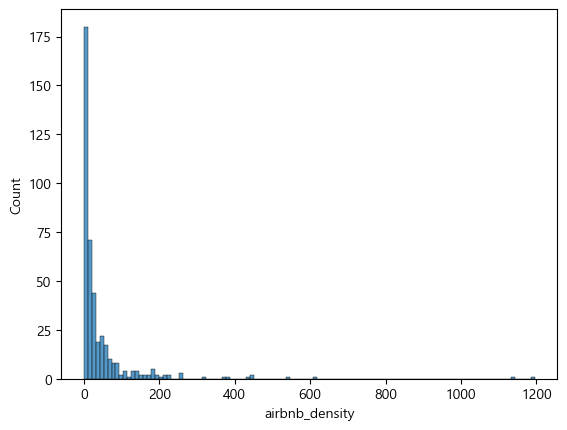

In [ ]:
sns.histplot(dong_stats['airbnb_density'])

In [ ]:
from sklearn.preprocessing import MinMaxScaler

density_cols = [
    'transport_density', 'tour_attraction_idx', 'stay_competition_density',
    'airbnb_density', 'cctv_density', 'subway_people_density', 'subway_trans_density'
]

# 로그변환 후 MinMaxScaler 적용 (0~1 사이 점수화)
scaler = MinMaxScaler()

# 새로운 컬럼명 생성 (예: transport_score, tour_score 등)
score_cols = [c.replace('_density', '_score').replace('_idx', '_score') for c in density_cols]


# 🔥 핵심 수정: 데이터에 np.log1p(x)를 먼저 취해 분포를 고르게 펴준 뒤 0~1로 만듬.
dong_stats[score_cols] = scaler.fit_transform(np.log1p(dong_stats[density_cols]))
# dong_stats[score_cols] = scaler.fit_transform(dong_stats[density_cols])

# 🔥 경쟁 관련 변수는 방향 뒤집기
reverse_scores = ['stay_competition_score', 'airbnb_score']

dong_stats[reverse_scores] = 1 - dong_stats[reverse_scores]

In [ ]:
dong_stats.head(2)

,district,dong,dong_id,geometry,cctv_cnt,airbnb_cnt,bus_cnt,landmark_cnt,hotel_cnt,motel_cnt,...,cctv_density,subway_people_density,subway_trans_density,transport_score,tour_attraction_score,stay_competition_score,airbnb_score,cctv_score,subway_people_score,subway_trans_score
0,종로구,청운효자동,11110515,"POLYGON ((953343.391 1955051.035, 953348.228 1...",165,140,18,18,0,0,...,64.29,0.00,0.00,0.30,0.59,1.00,0.43,0.57,0.00,0.00
1,종로구,사직동,11110530,"POLYGON ((953553.932 1953335.742, 953555.211 1...",106,130,28,27,1,3,...,91.56,20.73,0.00,0.69,0.92,0.71,0.33,0.64,0.76,0.00


In [ ]:
# 환승역을 고려한 교통점수 가중치 추가 부여
dong_stats['transfer_station_comb_score'] = (dong_stats['transport_score'] * 0.7 + dong_stats['subway_trans_score'] * 0.3)

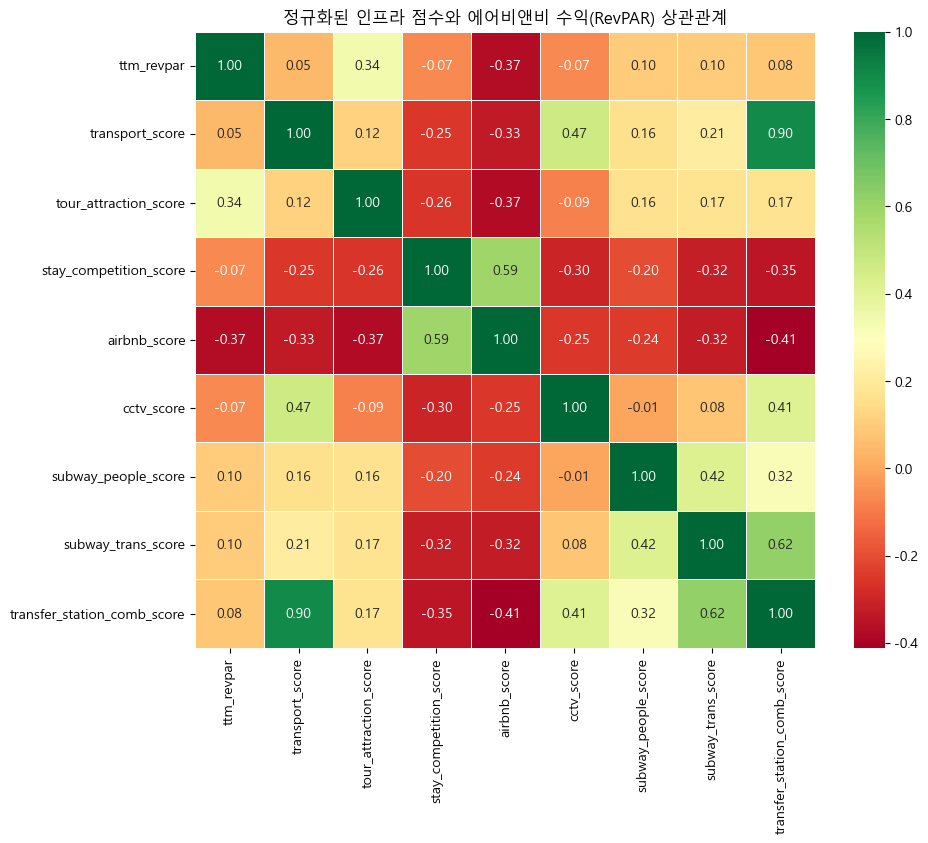

In [ ]:
# 1. 행정동별 평균 RevPAR 결합 (gdf_airbnb_with_dong의 '행정동' 컬럼 사용)
avg_revpar = gdf_airbnb_active_dong.groupby('행정동')['ttm_revpar'].median().reset_index()
dong_stats = dong_stats.merge(avg_revpar, left_on='dong', right_on='행정동', how='left').drop(columns=['행정동'])
dong_stats_corr = dong_stats.drop(columns=['district', 'dong']).fillna(0)

# 2. 상관관계 분석 대상 컬럼 설정
analysis_cols = ['ttm_revpar'] + score_cols + ['transfer_station_comb_score']
corr_matrix = dong_stats_corr[analysis_cols].corr()

# 3. 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title("정규화된 인프라 점수와 에어비앤비 수익(RevPAR) 상관관계")
plt.show()

In [ ]:
dong_stats.head(2)

,district,dong,dong_id,geometry,cctv_cnt,airbnb_cnt,bus_cnt,landmark_cnt,hotel_cnt,motel_cnt,...,subway_trans_density,transport_score,tour_attraction_score,stay_competition_score,airbnb_score,cctv_score,subway_people_score,subway_trans_score,transfer_station_comb_score,ttm_revpar
0,종로구,청운효자동,11110515,"POLYGON ((953343.391 1955051.035, 953348.228 1...",165,140,18,18,0,0,...,0.00,0.30,0.59,1.00,0.43,0.57,0.00,0.00,0.21,78045.35
1,종로구,사직동,11110530,"POLYGON ((953553.932 1953335.742, 953555.211 1...",106,130,28,27,1,3,...,0.00,0.69,0.92,0.71,0.33,0.64,0.76,0.00,0.48,62982.85


In [ ]:
gdf_dong_5179.head(2)

,ADSTRD_CD,ADSTRD_NM,XCNTS_VALU,YDNTS_VALU,RELM_AR,geometry
0,11110515,청운효자동,197342.00,453874.00,2568432.00,"POLYGON ((953343.391 1955051.035, 953348.228 1..."
1,11110530,사직동,197383.00,452705.00,1158536.00,"POLYGON ((953553.932 1953335.742, 953555.211 1..."


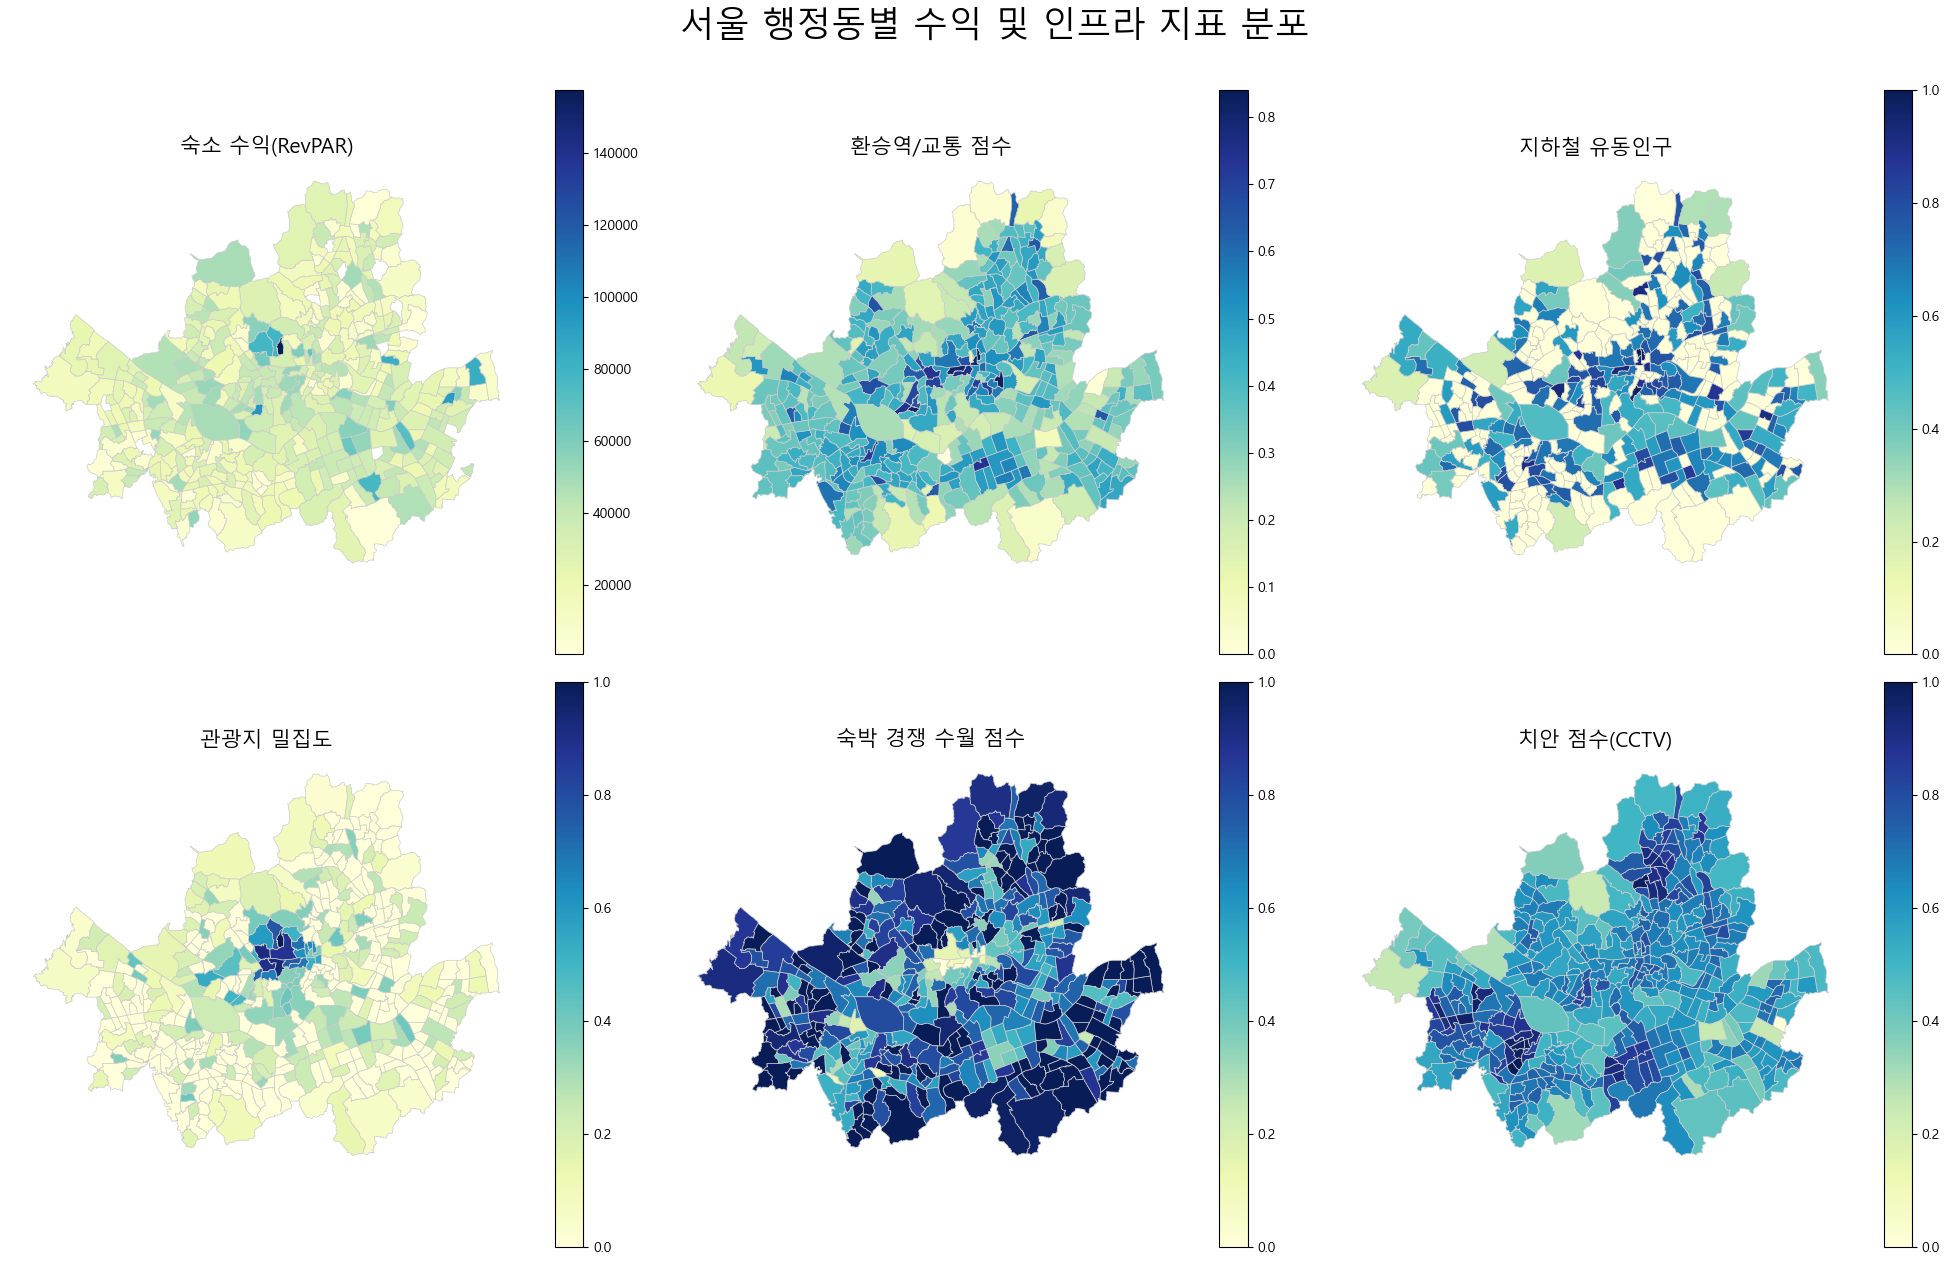

In [ ]:
# 1. 데이터 병합 (지도 데이터 + 분석 통계)
map_df = gdf_dong_5179.merge(dong_stats, left_on='ADSTRD_CD', right_on='dong_id')
map_df = map_df.set_geometry('geometry_x')
map_df = map_df.rename_geometry('geometry')

# 2. 여러 지표를 한 번에 비교하기 위한 서브플롯 생성
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# 시각화할 컬럼 리스트
plot_cols = ['ttm_revpar', 'transfer_station_comb_score', 'subway_people_score',
             'tour_attraction_score', 'stay_competition_score', 'cctv_score']

titles = ['숙소 수익(RevPAR)', '환승역/교통 점수', '지하철 유동인구',
          '관광지 밀집도', '숙박 경쟁 수월 점수', '치안 점수(CCTV)']

for i, col in enumerate(plot_cols):
    ax = axes[i]
    # 'RdYlGn' (빨강-노랑-초록) 혹은 수익은 'YlGnBu' 추천
    map_df.plot(column=col, ax=ax, legend=True, cmap='YlGnBu',
                edgecolor='0.8', linewidth=0.5)
    ax.set_title(titles[i], fontsize=15)
    ax.axis('off')

plt.tight_layout()
plt.suptitle("서울 행정동별 수익 및 인프라 지표 분포", fontsize=25, y=1.05)
plt.show()

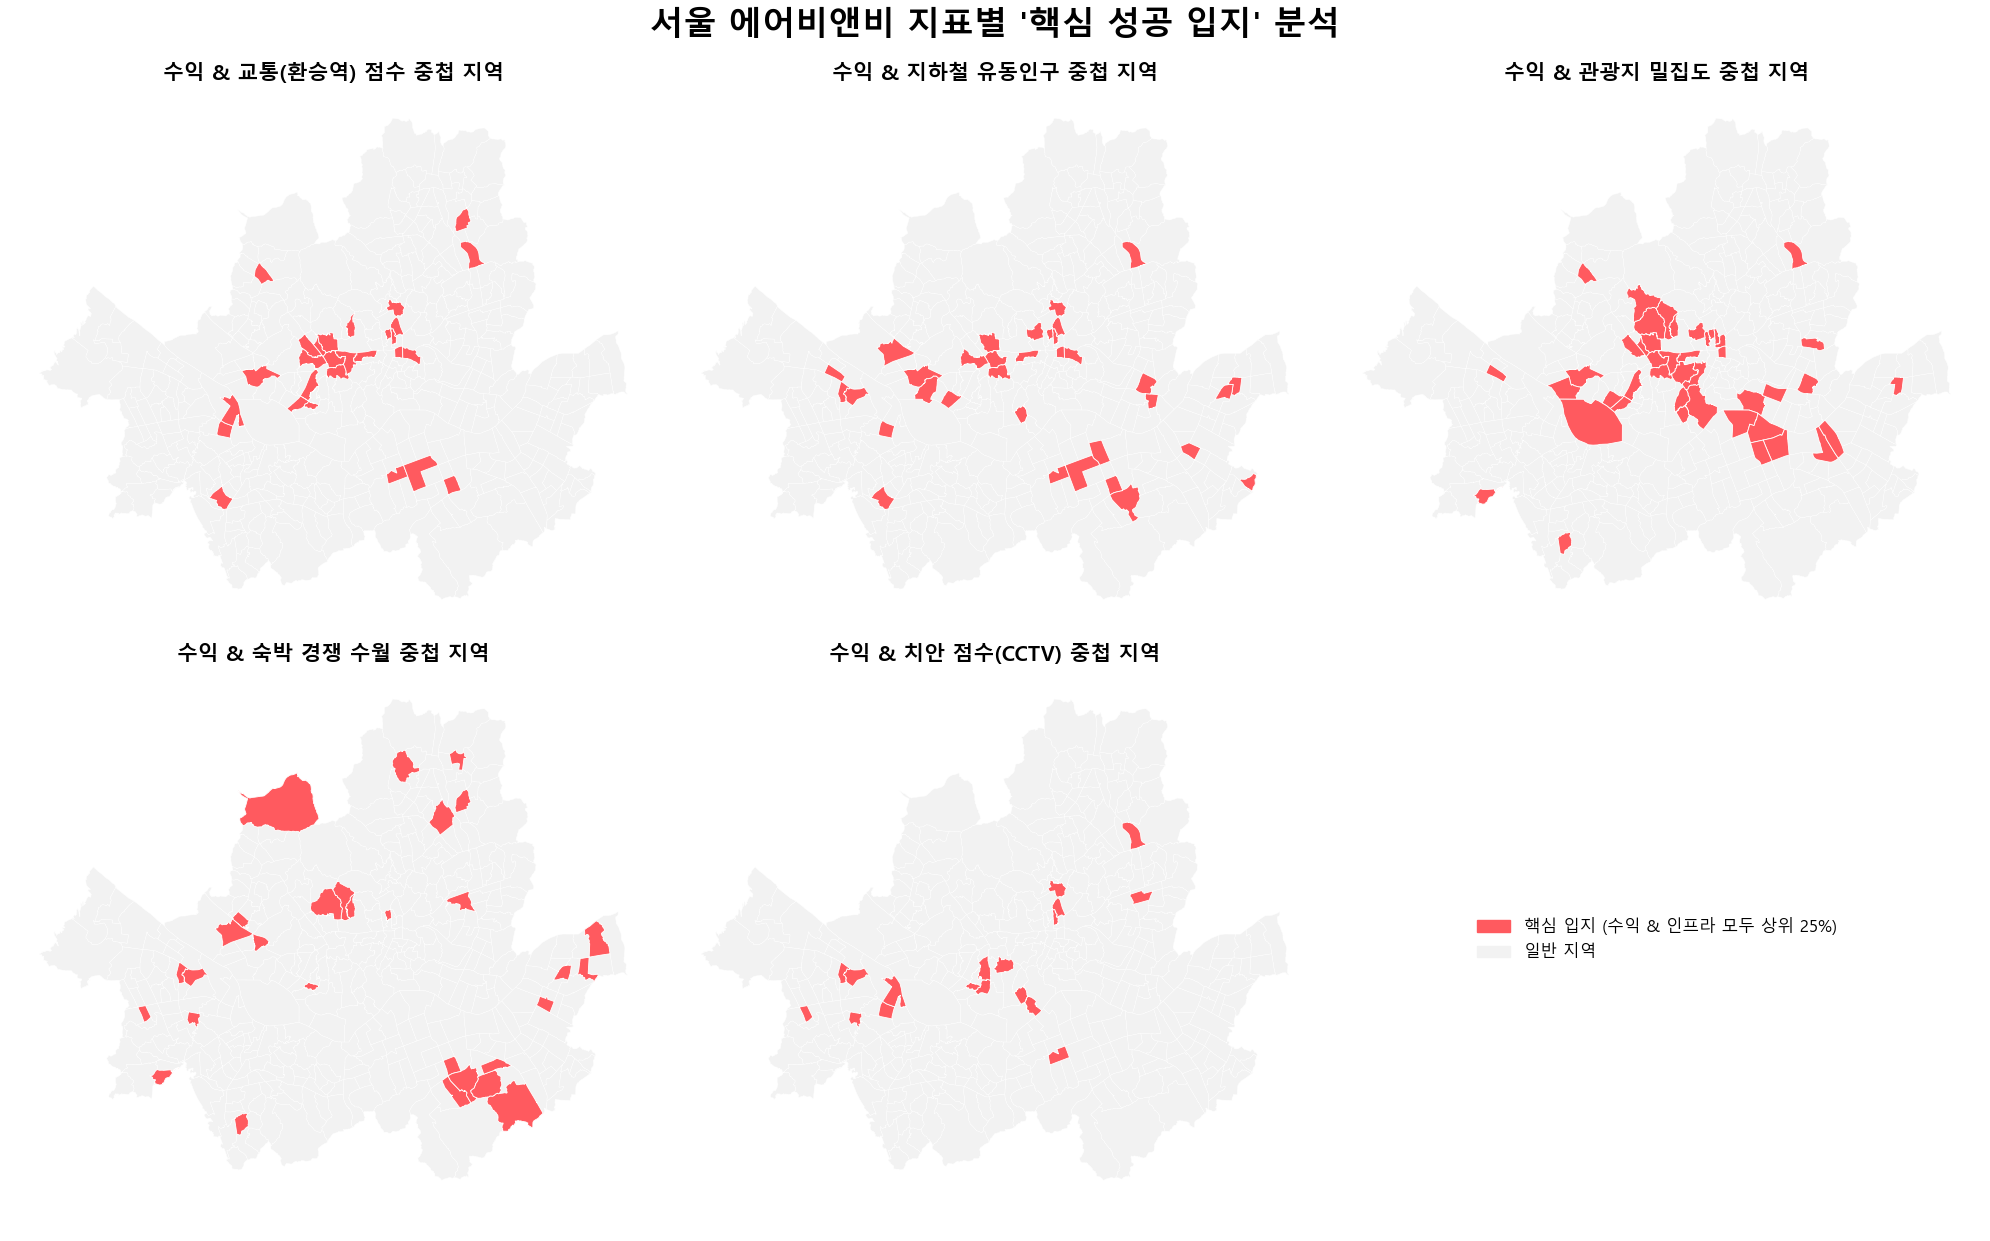

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. 분석할 인프라 지표 리스트
infra_to_plot = {
    'transfer_station_comb_score': '교통(환승역) 점수',
    'subway_people_score': '지하철 유동인구',
    'tour_attraction_score': '관광지 밀집도',
    'stay_competition_score': '숙박 경쟁 수월',
    'cctv_score': '치안 점수(CCTV)'
}

# 2. 수익 상위 25% 기준선
rev_threshold = map_df['ttm_revpar'].quantile(0.75)

# 3. 시각화 설정 (2행 3열)
fig, axes = plt.subplots(2, 3, figsize=(20, 12), facecolor='white')
axes = axes.flatten()

for i, (col, title) in enumerate(infra_to_plot.items()):
    ax = axes[i]

    # 해당 인프라 지표의 상위 25% 기준선
    infra_threshold = map_df[col].quantile(0.75)

    # '겹치는 곳'만 1, 나머지는 0으로 표시
    map_df['is_overlap'] = 0
    map_df.loc[(map_df['ttm_revpar'] >= rev_threshold) & (map_df[col] >= infra_threshold), 'is_overlap'] = 1

    # 기본 지도 (연한 회색 배경)
    map_df.plot(ax=ax, color='#F2F2F2', edgecolor='white', linewidth=0.3)

    # 겹치는 지역(Overlap)만 에어비앤비 레드로 하이라이트
    map_df[map_df['is_overlap'] == 1].plot(ax=ax, color='#FF5A5F', edgecolor='white', linewidth=0.6)

    ax.set_title(f"수익 & {title} 중첩 지역", fontsize=15, fontweight='bold', pad=10)
    ax.axis('off')

# 4. 범례 추가
axes[5].axis('off')
overlap_patch = mpatches.Patch(color='#FF5A5F', label='핵심 입지 (수익 & 인프라 모두 상위 25%)')
normal_patch = mpatches.Patch(color='#F2F2F2', label='일반 지역')
axes[5].legend(handles=[overlap_patch, normal_patch], loc='center', fontsize=12, frameon=False)

plt.tight_layout()
plt.suptitle("서울 에어비앤비 지표별 '핵심 성공 입지' 분석", fontsize=24, fontweight='bold', y=1.03)
plt.show()

In [ ]:
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches

# # [전제] map_df는 GeoDataFrame이며, 정규화된 score_cols와 ttm_revpar가 병합되어 있어야 합니다.

# # 1. 시각화할 인프라 지표와 매칭될 타이틀 설정
# infra_to_plot = {
#     'transfer_station_comb_score': '환승역/교통 점수',
#     'subway_people_score': '지하철 유동인구',
#     'tour_attraction_score': '관광지 밀집도',
#     'stay_competition_score': '숙박 경쟁도(역전)',
#     'cctv_score': '치안 점수(CCTV)'
# }

# # 2. '상위 지역'의 기준 정의 (상위 25% Quantile)
# rev_threshold = map_df['ttm_revpar'].quantile(0.75)

# # 3. 5개의 지도를 그리기 위한 서브플롯 설정 (2행 3열, 마지막 칸은 범례로 사용)
# fig, axes = plt.subplots(2, 3, figsize=(22, 14), facecolor='white')
# axes = axes.flatten()

# # 에어비앤비 컬러 팔레트 정의
# color_mapping = {
#     'Match': '#FC642D',       # 수익 High - 인프라 High (Airbnb 오렌지 - 핵심 지역)
#     'High_Infra': '#00A699',   # 수익 Low  - 인프라 High (Airbnb 청록색 - 잠재력)
#     'High_Rev': '#FF5A5F',     # 수익 High - 인프라 Low  (Airbnb 레드 - 의외의 지역)
#     'Normal': '#EBEBEB'        # 둘 다 Low (회색 - 배경)
# }

# # 4. 각 지표별로 돌면서 지도 그리기
# for i, (col, title) in enumerate(infra_to_plot.items()):
#     ax = axes[i]

#     # 해당 지표의 상위 기준 설정
#     infra_threshold = map_df[col].quantile(0.75)

#     # 임시 분류 컬럼 생성
#     map_df['temp_class'] = 'Normal'
#     # 인프라만 높음
#     map_df.loc[(map_df['ttm_revpar'] < rev_threshold) & (map_df[col] >= infra_threshold), 'temp_class'] = 'High_Infra'
#     # 수익만 높음
#     map_df.loc[(map_df['ttm_revpar'] >= rev_threshold) & (map_df[col] < infra_threshold), 'temp_class'] = 'High_Rev'
#     # 둘 다 높음 (관계성 확실)
#     map_df.loc[(map_df['ttm_revpar'] >= rev_threshold) & (map_df[col] >= infra_threshold), 'temp_class'] = 'Match'

#     # 지도 그리기 (Normal 배경)
#     map_df.plot(ax=ax, color=color_mapping['Normal'], edgecolor='white', linewidth=0.3)

#     # 카테고리별로 덮어쓰기
#     for cls, color in color_mapping.items():
#         if cls != 'Normal':
#             map_df[map_df['temp_class'] == cls].plot(ax=ax, color=color, edgecolor='white', linewidth=0.5)

#     ax.set_title(f"ttm_revpar vs {title}", fontsize=16, fontweight='bold', pad=10)
#     ax.axis('off')

# # 5. 마지막 서브플롯(axes[5])에 깔끔한 범례 추가
# axes[5].axis('off') # 지도 안 그림
# legend_patches = [
#     mpatches.Patch(color=color_mapping['Match'], label='수익 & 인프라 모두 상위 (핵심 입지)'),
#     mpatches.Patch(color=color_mapping['High_Infra'], label='인프라 상위 - 수익 잠재력 높음'),
#     mpatches.Patch(color=color_mapping['High_Rev'], label='수익 상위 - 인프라 외 요인 작용'),
#     mpatches.Patch(color=color_mapping['Normal'], label='일반 지역')
# ]
# axes[5].legend(handles=legend_patches, loc='center', fontsize=14, frameon=False, title="입지 분석 범례", title_fontsize=16)

# plt.tight_layout()
# plt.suptitle("지표별 에어비앤비 수익(RevPAR) 중첩 분석 지도", fontsize=28, fontweight='bold', y=1.03, color='#484848')
# plt.show()

## 행정동 산출
- tour_attraction_score가 상관관계가 가장 높아 해당 점수에서 에어비앤비 공급 밀도 점수를 뺀 값을 기회 지역으로 선정

In [ ]:
opportunity_dong = sc[sc['quadrant'] == '고성과-저경쟁(기회)']
opportunity_dong = opportunity_dong[['district', 'dong', 'opportunity_score', 'quadrant']]
opportunity_dong.head(2)

,district,dong,opportunity_score,quadrant
0,강남구,개포1동,0.23,고성과-저경쟁(기회)
1,강남구,개포2동,0.30,고성과-저경쟁(기회)


In [ ]:
sc.columns

Index(['district', 'dong', 'active_listings', 'revpar_med', 'occ_med',
       'adr_med', 'revenue_med', 'instant_rate', 'superhost_rate',
       'min_nights_med', 'rating_med', 'photos_med', 'reviews_med', 'area_km2',
       'density_per_km2', 'r_revpar', 'r_revenue', 'r_competition',
       'r_instant', 'r_superhost', 'score_performance', 'score_ops',
       'reliability_weight', 'quadrant', 'opportunity_score',
       'opportunity_rank'],
      dtype='object')

In [ ]:
# (발표 버전) 단계별 필터링 파이프라인
# - Step2(교통)는 강한 상위 컷을 피하고 '하위 제거' 중심으로 고정 추천
# - 나머지 Step3(관광 매력도), Step4(숙박업 경쟁도)는 기존 로직 유지(필요시 조정 가능)

# 2. 전체 평균 RevPAR (기준점) — 필요하면 Step4에서 수익성 검증용으로 사용
overall_avg_revpar = dong_stats['ttm_revpar'].median()

# ---- 기준(발표 고정 추천)
FILTER_STEP2_ON = True
Q_TRANSPORT_LOW = 0.20        # 교통 결합 점수 하위 20% 제거
Q_SUBWAY_PEOPLE_LOW = 0.20    # (있을 때만) 유동인구 하위 20% 제거(유령동네 방지)

Q_TOUR_HIGH = 0.70            # 관광 매력도 상위 30% (기존 유지)

# --- Step 1: 고성과-저경쟁(기회) 동 ---
gdf_stage1 = dong_stats.merge(opportunity_dong, on=["district", "dong"], how="inner")

# --- Step 2: 교통(결합 점수) 하위 제거 + (옵션) 유동인구 하위 제거 ---
gdf_stage2 = gdf_stage1.copy()

if FILTER_STEP2_ON and "transfer_station_comb_score" in gdf_stage2.columns:
    gdf_stage2 = gdf_stage2[
        gdf_stage2["transfer_station_comb_score"] >= gdf_stage2["transfer_station_comb_score"].quantile(Q_TRANSPORT_LOW)
    ]

# 유동인구(지하철 승하차) 점수는 데이터가 있을 때만 적용
if "subway_people_score" in gdf_stage2.columns:
    gdf_stage2 = gdf_stage2[
        gdf_stage2["subway_people_score"] >= gdf_stage2["subway_people_score"].quantile(Q_SUBWAY_PEOPLE_LOW)
    ]

# --- Step 3: 관광 매력도 상위 (수익 잠재력) ---
if "tour_attraction_score" not in gdf_stage2.columns:
    raise KeyError("tour_attraction_score 컬럼이 없습니다. Step3 실행 불가.")
gdf_stage3 = gdf_stage2[
    gdf_stage2["tour_attraction_score"] >= gdf_stage2["tour_attraction_score"].quantile(Q_TOUR_HIGH)
].copy()

# --- Step 4: 블루오션 검증 (호텔&모텔 숙박업 포화도 낮음) ---
if "stay_competition_score" not in gdf_stage3.columns:
    raise KeyError("stay_competition_score 컬럼이 없습니다. Step4 실행 불가.")
gdf_stage4 = gdf_stage3[
    (gdf_stage3["stay_competition_score"] <= gdf_stage3["stay_competition_score"].median())
].copy()

# (옵션) Step4를 실질 수익성(전체 중앙값 이상)으로 바꾸고 싶으면 아래 사용
# gdf_stage4 = gdf_stage3[gdf_stage3['ttm_revpar'] >= overall_avg_revpar].copy()

print(f"Step 1 (기회지역): {len(gdf_stage1)}개 동")
print(f"Step 2 (기회지역+교통 하위제거): {len(gdf_stage2)}개 동")
print(f"Step 3 (교통 + 관광 매력도 상위): {len(gdf_stage3)}개 동")
print(f"Step 4 (최종 경쟁 최적): {len(gdf_stage4)}개 동")


Step 1 (기회지역): 77개 동
Step 2 (기회지역+교통 하위제거): 61개 동
Step 3 (교통 + 관광 매력도 상위): 19개 동
Step 4 (최종 경쟁 최적): 10개 동


In [ ]:
gdf_stage4

,district,dong,dong_id,geometry,cctv_cnt,airbnb_cnt,bus_cnt,landmark_cnt,hotel_cnt,motel_cnt,...,tour_attraction_score,stay_competition_score,airbnb_score,cctv_score,subway_people_score,subway_trans_score,transfer_station_comb_score,ttm_revpar,opportunity_score,quadrant
8,동대문구,답십리2동,11230610,"POLYGON ((961597.576 1953098.514, 961600.733 1...",96,6,17,1,0,2,...,0.21,0.77,0.71,0.67,0.00,0.00,0.42,29309.65,0.66,고성과-저경쟁(기회)
15,광진구,능동,11215780,"POLYGON ((963145.882 1950809.933, 963154.462 1...",59,13,5,2,1,1,...,0.37,0.80,0.64,0.54,0.87,0.50,0.39,40606.40,0.64,고성과-저경쟁(기회)
17,중랑구,면목4동,11260540,"POLYGON ((962882.142 1953160.657, 962884.119 1...",122,1,8,0,0,2,...,0.22,0.76,0.89,0.72,0.68,0.00,0.30,82911.00,0.29,고성과-저경쟁(기회)
22,노원구,공릉1동,11350595,"POLYGON ((961937.192 1959203.661, 961937.677 1...",325,15,31,1,0,4,...,0.26,0.72,0.64,0.83,0.74,0.46,0.63,45770.00,0.74,고성과-저경쟁(기회)
27,은평구,녹번동,11380510,"POLYGON ((950857.998 1956888.534, 950876.943 1...",206,16,20,2,1,5,...,0.21,0.72,0.68,0.68,0.66,0.00,0.32,30011.50,0.53,고성과-저경쟁(기회)
49,영등포구,여의동,11560540,"POLYGON ((948476.184 1949282.009, 948476.488 1...",247,38,49,6,6,9,...,0.23,0.80,0.76,0.43,0.47,0.19,0.25,48527.55,0.78,고성과-저경쟁(기회)
57,서초구,반포4동,11650581,"POLYGON ((956694.208 1945250.392, 956725.771 1...",420,13,20,2,1,2,...,0.24,0.78,0.67,0.86,0.56,0.42,0.50,30663.70,0.54,고성과-저경쟁(기회)
70,송파구,잠실6동,11710710,"POLYGON ((964915.959 1947039.446, 964937.626 1...",37,9,12,5,3,3,...,0.41,0.69,0.73,0.39,0.54,0.41,0.39,71898.40,0.82,고성과-저경쟁(기회)
71,강동구,명일1동,11740530,"POLYGON ((968715.619 1950676.354, 968726.443 1...",64,2,12,0,0,1,...,0.26,0.82,0.80,0.66,0.74,0.00,0.43,56437.25,0.59,고성과-저경쟁(기회)
76,강동구,둔촌2동,11740700,"POLYGON ((969658.021 1948737.38, 969656.712 19...",81,22,19,1,0,3,...,0.23,0.79,0.62,0.53,0.54,0.00,0.33,34427.85,0.65,고성과-저경쟁(기회)


- 태블로용 step 라벨 컬럼 생성

In [ ]:
# df_pipeline = dong_stats.copy()

# df_pipeline['step1_pass'] = df_pipeline.set_index(['district','dong']).index.isin(
#     opportunity_dong.set_index(['district','dong']).index
# )

# transport_cut = df_pipeline['transfer_station_comb_score'].quantile(Q_TRANSPORT_LOW)
# subway_cut = df_pipeline['subway_people_score'].quantile(Q_SUBWAY_PEOPLE_LOW)

# df_pipeline['step2_pass'] = (
#     df_pipeline['step1_pass'] &
#     (df_pipeline['transfer_station_comb_score'] >= transport_cut) &
#     (df_pipeline['subway_people_score'] >= subway_cut)
# )

# tour_cut = df_pipeline['tour_attraction_score'].quantile(Q_TOUR_HIGH)

# df_pipeline['step3_pass'] = (
#     df_pipeline['step2_pass'] &
#     (df_pipeline['tour_attraction_score'] >= tour_cut)
# )

# stay_cut = df_pipeline['stay_competition_score'].median()

# df_pipeline['step4_pass'] = (
#     df_pipeline['step3_pass'] &
#     (df_pipeline['stay_competition_score'] <= stay_cut)
# )

In [ ]:
df_pipeline = dong_stats.copy()

# Step1
stage1_index = gdf_stage1.set_index(['district','dong']).index
df_pipeline['step1_pass'] = df_pipeline.set_index(['district','dong']).index.isin(stage1_index)

# Step2
stage2_index = gdf_stage2.set_index(['district','dong']).index
df_pipeline['step2_pass'] = df_pipeline.set_index(['district','dong']).index.isin(stage2_index)

# Step3
stage3_index = gdf_stage3.set_index(['district','dong']).index
df_pipeline['step3_pass'] = df_pipeline.set_index(['district','dong']).index.isin(stage3_index)

# Step4
stage4_index = gdf_stage4.set_index(['district','dong']).index
df_pipeline['step4_pass'] = df_pipeline.set_index(['district','dong']).index.isin(stage4_index)

In [ ]:
df_pipeline['pipeline_step'] = 0

df_pipeline.loc[df_pipeline['step1_pass'], 'pipeline_step'] = 1
df_pipeline.loc[df_pipeline['step2_pass'], 'pipeline_step'] = 2
df_pipeline.loc[df_pipeline['step3_pass'], 'pipeline_step'] = 3
df_pipeline.loc[df_pipeline['step4_pass'], 'pipeline_step'] = 4

In [ ]:
step_labels = {
    0: "Not Opportunity",
    1: "Opportunity",
    2: "Transport OK",
    3: "Tourism High",
    4: "Final Blue Ocean"
}

df_pipeline['pipeline_label'] = df_pipeline['pipeline_step'].map(step_labels)

In [ ]:
df_pipeline[df_pipeline['dong'] == '일원본동']

,district,dong,dong_id,geometry,cctv_cnt,airbnb_cnt,bus_cnt,landmark_cnt,hotel_cnt,motel_cnt,...,subway_people_score,subway_trans_score,transfer_station_comb_score,ttm_revpar,step1_pass,step2_pass,step3_pass,step4_pass,pipeline_step,pipeline_label
414,강남구,일원본동,11680720,"POLYGON ((963765.866 1943605.332, 963766.085 1...",82,1,19,0,0,0,...,0.45,0.00,0.25,40671.00,True,True,False,False,2,Transport OK


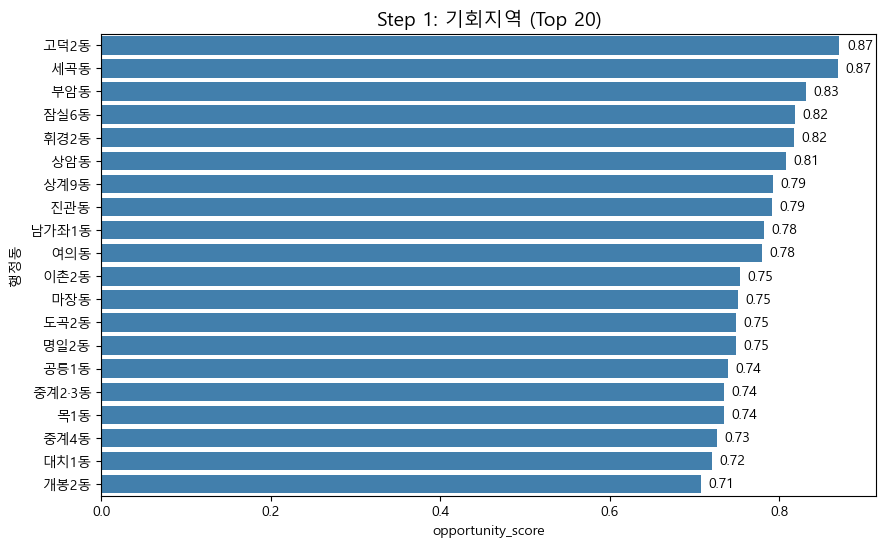

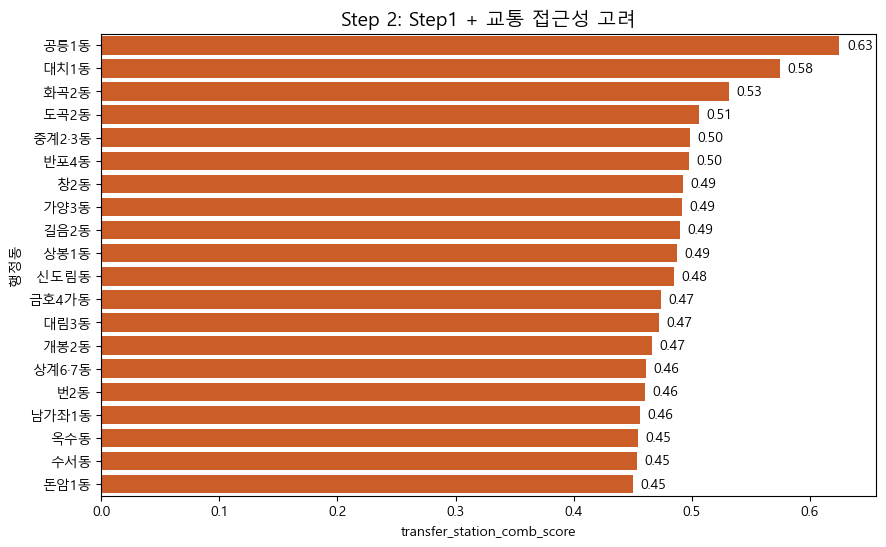

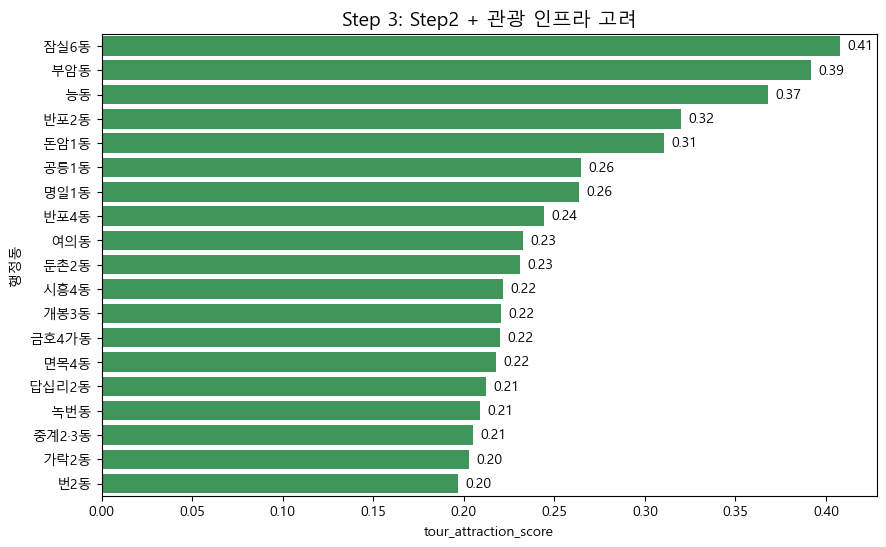

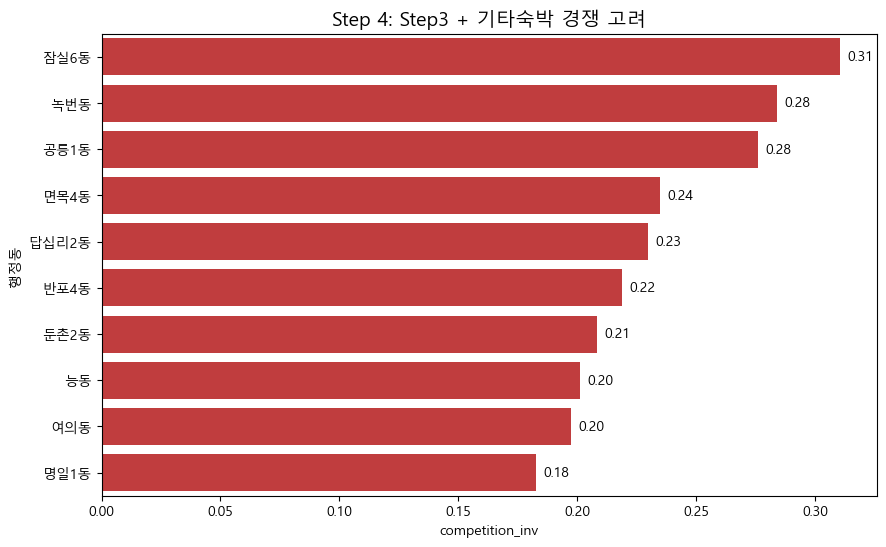

In [ ]:
# 시각적 일관성을 위한 색상 팔레트
step_colors = ["#3182bd", "#e6550d", "#31a354", "#d62728"]

def plot_top20(df, x_col, y_col='dong', title='', color='#3182bd', invert_x=False):
    plt.figure(figsize=(10, 6))
    ax = sns.barplot(data=df, x=x_col, y=y_col, color=color)

    # 막대 위에 값 라벨 추가
    for p in ax.patches:
        width = p.get_width()
        ax.text(width + (0.01 * df[x_col].max()), p.get_y() + p.get_height()/2, f'{width:.2f}',
                va='center', fontsize=10)

    if invert_x:
        ax.invert_xaxis()  # x축 반전

    plt.title(title, fontsize=14)
    plt.xlabel(x_col)
    plt.ylabel('행정동')
    plt.show()


# 보기 편하도록 top 20까지만 산출함. (실제 필터가 top 20은 아님.)
# --- Step 1: 기회지역 Top 20 ---
s1_top20 = gdf_stage1.nlargest(20, 'opportunity_score')
plot_top20(s1_top20, 'opportunity_score', title='Step 1: 기회지역 (Top 20)', color=step_colors[0])

# --- Step 2: 기회지역 + 교통 Top 20 ---
s2_top20 = gdf_stage2.nlargest(20, 'transfer_station_comb_score')
plot_top20(s2_top20, 'transfer_station_comb_score', title='Step 2: Step1 + 교통 접근성 고려', color=step_colors[1])

# --- Step 3: 교통 + 관광 매력도 Top 20 ---
s3_top20 = gdf_stage3.nlargest(20, 'tour_attraction_score')
plot_top20(s3_top20, 'tour_attraction_score', title='Step 3: Step2 + 관광 인프라 고려', color=step_colors[2])

# --- Step 4: 블루오션 검증 Top 20 (경쟁 낮은 순) ---
s4_top20 = gdf_stage4.nsmallest(20, 'stay_competition_score')
s4_top20['competition_inv'] = 1 - s4_top20['stay_competition_score']
plot_top20(s4_top20, 'competition_inv', title='Step 4: Step3 + 기타숙박 경쟁 고려', color=step_colors[3])

In [ ]:
gdf_airbnb_active_dong.columns

Index(['index', 'baths', 'bedrooms', 'beds', 'cleaning_fee', 'country',
       'currency', 'extra_guest_fee', 'guests', 'instant_book',
       'l90d_avg_rate', 'l90d_occupancy', 'l90d_revenue', 'l90d_revpar',
       'listing_type', 'locality', 'min_nights', 'num_reviews', 'photos_count',
       'rating_overall', 'region', 'room_type', 'superhost', 'ttm_avg_rate',
       'ttm_occupancy', 'ttm_revenue', 'ttm_revpar', 'district', 'X좌표(WGS84)',
       'Y좌표(WGS84)', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)', 'geometry', 'baths_w',
       'bedrooms_w', 'beds_w', 'min_nights_w', 'cleaning_fee_w',
       'extra_guest_fee_w', 'num_reviews_w', 'photos_count_w',
       'l90d_avg_rate_w', 'l90d_revenue_w', 'l90d_revpar_w', 'ttm_avg_rate_w',
       'ttm_revenue_w', 'ttm_revpar_w', 'log_cleaning_fee',
       'log_extra_guest_fee', 'log_num_reviews', 'log_photos_count',
       'log_l90d_avg_rate', 'log_l90d_revenue', 'log_l90d_revpar',
       'log_ttm_avg_rate', 'log_ttm_revenue', 'log_ttm_revpar',
       'rati

In [ ]:
import folium
from folium.plugins import MarkerCluster

# 1. 시각화를 위해 모든 데이터를 위경도(EPSG:4326)로 변환
gdf_base = dong_stats.to_crs(4326)
s1_map = gdf_stage1.to_crs(4326)
s2_map = gdf_stage2.to_crs(4326)
s3_map = gdf_stage3.to_crs(4326)
s4_map = gdf_stage4.to_crs(4326)
airbnb_ll = gdf_airbnb_active_dong.to_crs(4326)

# 안전장치: 기존 index_right 제거
for gdf in [airbnb_ll, s4_map]:
    if 'index_right' in gdf.columns:
        gdf.drop(columns=['index_right'], inplace=True)

# Step4 폴리곤 내부 숙소만 추출
airbnb_s4 = gpd.sjoin(
    airbnb_ll,
    s4_map[['geometry']],
    how='inner',
    predicate='within'
)

# 행정동별 중앙값 계산
dong_revpar_median = (
    dong_stats
    .groupby('dong')['ttm_revpar']
    .median()
    .reset_index()
    .rename(columns={'ttm_revpar': 'dong_median_revpar'})
)

# 숙소 데이터에 자치구 중앙값 붙이기.
airbnb_s4 = airbnb_s4.merge(
    dong_revpar_median,
    left_on='행정동',
    right_on='dong',
    how='left'
)


# 2. 지도 생성 (서울 중심부)
m = folium.Map(location=[37.5665, 126.9780], zoom_start=11, tiles='OpenStreetMap') # cartodbpositron

# [Base] 전체 행정동 경계 (연한 회색 배경)
# folium.GeoJson(
#     gdf_base,
#     name="전체 행정동",
#     style_function=lambda x: {"fillColor": "#ffffff", "fillOpacity": 0.1, "color": "#aaaaaa", "weight": 1},
# ).add_to(m)

# Step1에 해당되지 않는 행정동만 추출
gdf_not_step1 = gdf_base[~gdf_base["dong"].isin(s1_map['dong'])]

# 연한 회색으로 표시 (서울 경계 강조용)
folium.GeoJson(
    gdf_not_step1,
    name="행정동 강조",
    style_function=lambda x: {
        "fillColor": "#494747",   # 연회색
        "fillOpacity": 0.7,       # 기존보다 조금 더 진하게
        "color": "#949494",
        "weight": 1
    }
).add_to(m)

# [Step 1] 교통 허브 (파란색 점선 테두리)
folium.GeoJson(
    s1_map,
    name="Step 1: 기회 지역 (고성과-저경쟁)",
    style_function=lambda x: {"fillOpacity": 0.3, "color": "blue", "weight": 2, "dashArray": "5, 5"},
    tooltip=folium.GeoJsonTooltip(fields=['dong'], aliases=['행정동:'])
).add_to(m)

# [Step 2] 수익 기회 지역 (주황색 테두리)
folium.GeoJson(
    s2_map,
    name="Step 2: 교통 접근성 고려",
    style_function=lambda x: {"fillOpacity": 0.3, "color": "orange", "weight": 2.5},
).add_to(m)

# [Step 3] 안정성/경쟁 최적 지역 (초록색 테두리)
folium.GeoJson(
    s3_map,
    name="Step 3: 관광 매력도 고려",
    style_function=lambda x: {"fillOpacity": 0.3, "color": "green", "weight": 3},
).add_to(m)

# [Step 4] 최종 추천 지역 (빨간색 면 채우기)
# s4_map에 포맷된 컬럼 추가
s4_map['ttm_revpar_fmt'] = s4_map['ttm_revpar'].apply(lambda x: f"{x:,.0f}원")

folium.GeoJson(
    s4_map,
    name="Step 4: 최종 경쟁 최적 (기타숙박 경쟁 낮음)",
    style_function=lambda x: {
        "fillColor": "red",
        "fillOpacity": 0.3,
        "color": "red",
        "weight": 4
    },
    tooltip=folium.GeoJsonTooltip(
        fields=['district', 'dong', 'ttm_revpar_fmt', 'opportunity_score'],
        aliases=['자치구', '행정동:', 'RevPAR (원):', '기회 점수:'],
        localize=True # 숫자에 콤마(,) 추가
    )
).add_to(m)

# 5) 선정 지역 내 에어비앤비 숙소 (클러스터)
fg_airbnb = folium.FeatureGroup(name="선정 지역 에어비앤비 숙소", show=True)
mc_airbnb = MarkerCluster(disableClusteringAtZoom=15).add_to(fg_airbnb) # 줌 아웃하면 점개수 합쳐서 보여주는 기능
# mc_airbnb = fg_airbnb

for _, r in airbnb_s4.iterrows():

    # 🔴🔵 RevPAR 기준 색상 결정(해당 행정동 중앙값 대비 높으면 빨간색)
    color = "red" if r['ttm_revpar'] > r['dong_median_revpar'] else "blue"

    tooltip_text = (
        f"에어비앤비<br>"
        f"평균 숙소 요금: {r.get('ttm_avg_rate', 0):,.0f}원<br>"
        f"평점: {r.get('rating_overall', 0):.2f}<br>"
        f"RevPAR: {r.get('ttm_revpar', 0):,.0f}원"
    )

    folium.CircleMarker(
        location=[r.geometry.y, r.geometry.x],
        radius=6,
        # stroke=False,
        fill=False,
        # fill_color=color,
        color = color,
        fill_opacity=0.8,
        tooltip=tooltip_text
    ).add_to(mc_airbnb)
    # folium.Marker(
    #     location=[r.geometry.y, r.geometry.x],
    #     tooltip=tooltip_text,
    #     icon=folium.Icon(color=color, icon="home", prefix="fa")
    # ).add_to(mc_airbnb)

fg_airbnb.add_to(m)

# 3. 레이어 컨트롤 추가 (분석가가 레이어를 껐다 켰다 하며 필터링 과정을 보여줄 수 있음)
folium.LayerControl(collapsed=False).add_to(m)

legend_html = '''
     <div style="
     position: fixed;
     top: 175px; right: 10px;
     width: 235px; height: 70px;
     background-color: white;
     border:2px solid #aaaaaa;
     border-radius: 6px;
     z-index:9999;
     padding: 10px;
     font-size:11px;
     ">
     <b>숙소 마커</b><br>
     🔴 소속 행정동 RevPAR 중앙값 이상 숙소<br>
     🔵 소속 행정동 RevPAR 중앙값 이하 숙소<br>
     </div>
     '''

m.get_root().html.add_child(folium.Element(legend_html))

# 지도 저장
m.save(OUT/"seoul_airbnb_final_step4_recommendation.html")

# 시각화 사용 csv 파일 저장
df_pipeline.to_csv(OUT/"airbnb_pipeline_tableau.csv", index=False)
gdf_airbnb_active_dong.to_csv(OUT/"airbnb_active_dong_tableau.csv", index=False)

In [ ]:
df_pipeline.columns

Index(['district', 'dong', 'dong_id', 'geometry', 'cctv_cnt', 'airbnb_cnt',
       'bus_cnt', 'landmark_cnt', 'hotel_cnt', 'motel_cnt', 'place120_cnt',
       'park_cnt', 'subway_cnt', 'subway_trans_cnt', 'subway_people_cnt',
       'area_km2', 'transport_density', 'tour_attraction_idx',
       'stay_competition_density', 'airbnb_density', 'cctv_density',
       'subway_people_density', 'subway_trans_density', 'transport_score',
       'tour_attraction_score', 'stay_competition_score', 'airbnb_score',
       'cctv_score', 'subway_people_score', 'subway_trans_score',
       'transfer_station_comb_score', 'ttm_revpar', 'step1_pass', 'step2_pass',
       'step3_pass', 'step4_pass', 'pipeline_step', 'pipeline_label'],
      dtype='object')

In [ ]:
airbnb_s4.columns

Index(['index', 'baths', 'bedrooms', 'beds', 'cleaning_fee', 'country',
       'currency', 'extra_guest_fee', 'guests', 'instant_book',
       'l90d_avg_rate', 'l90d_occupancy', 'l90d_revenue', 'l90d_revpar',
       'listing_type', 'locality', 'min_nights', 'num_reviews', 'photos_count',
       'rating_overall', 'region', 'room_type', 'superhost', 'ttm_avg_rate',
       'ttm_occupancy', 'ttm_revenue', 'ttm_revpar', 'district', 'X좌표(WGS84)',
       'Y좌표(WGS84)', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)', 'geometry', 'baths_w',
       'bedrooms_w', 'beds_w', 'min_nights_w', 'cleaning_fee_w',
       'extra_guest_fee_w', 'num_reviews_w', 'photos_count_w',
       'l90d_avg_rate_w', 'l90d_revenue_w', 'l90d_revpar_w', 'ttm_avg_rate_w',
       'ttm_revenue_w', 'ttm_revpar_w', 'log_cleaning_fee',
       'log_extra_guest_fee', 'log_num_reviews', 'log_photos_count',
       'log_l90d_avg_rate', 'log_l90d_revenue', 'log_l90d_revpar',
       'log_ttm_avg_rate', 'log_ttm_revenue', 'log_ttm_revpar',
       'rati

In [ ]:
recommand_dong_list = list(s4_top20['dong'])
recommand_dong_list

['잠실6동', '녹번동', '공릉1동', '면목4동', '답십리2동', '반포4동', '둔촌2동', '능동', '여의동', '명일1동']

In [ ]:
dong_stats.columns

Index(['district', 'dong', 'dong_id', 'geometry', 'cctv_cnt', 'airbnb_cnt',
       'bus_cnt', 'landmark_cnt', 'hotel_cnt', 'motel_cnt', 'place120_cnt',
       'park_cnt', 'subway_cnt', 'subway_trans_cnt', 'subway_people_cnt',
       'area_km2', 'transport_density', 'tour_attraction_idx',
       'stay_competition_density', 'airbnb_density', 'cctv_density',
       'subway_people_density', 'subway_trans_density', 'transport_score',
       'tour_attraction_score', 'stay_competition_score', 'airbnb_score',
       'cctv_score', 'subway_people_score', 'subway_trans_score',
       'transfer_station_comb_score', 'ttm_revpar'],
      dtype='object')

In [ ]:
gdf_airbnb_active_dong[gdf_airbnb_active_dong['행정동'].isin(recommand_dong_list)]['district'].unique()

array(['서초구', '영등포구', '강동구', '송파구', '은평구', '중랑구', '광진구', '노원구', '동대문구'],
      dtype=object)

In [ ]:
gdf_airbnb_active_dong.columns

Index(['index', 'baths', 'bedrooms', 'beds', 'cleaning_fee', 'country',
       'currency', 'extra_guest_fee', 'guests', 'instant_book',
       'l90d_avg_rate', 'l90d_occupancy', 'l90d_revenue', 'l90d_revpar',
       'listing_type', 'locality', 'min_nights', 'num_reviews', 'photos_count',
       'rating_overall', 'region', 'room_type', 'superhost', 'ttm_avg_rate',
       'ttm_occupancy', 'ttm_revenue', 'ttm_revpar', 'district', 'X좌표(WGS84)',
       'Y좌표(WGS84)', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)', 'geometry', 'baths_w',
       'bedrooms_w', 'beds_w', 'min_nights_w', 'cleaning_fee_w',
       'extra_guest_fee_w', 'num_reviews_w', 'photos_count_w',
       'l90d_avg_rate_w', 'l90d_revenue_w', 'l90d_revpar_w', 'ttm_avg_rate_w',
       'ttm_revenue_w', 'ttm_revpar_w', 'log_cleaning_fee',
       'log_extra_guest_fee', 'log_num_reviews', 'log_photos_count',
       'log_l90d_avg_rate', 'log_l90d_revenue', 'log_l90d_revpar',
       'log_ttm_avg_rate', 'log_ttm_revenue', 'log_ttm_revpar',
       'rati

In [ ]:
def airbnb_dong_summary(dong):
    airbnb_lists = gdf_airbnb_active_dong[gdf_airbnb_active_dong['행정동'] == dong]

    small_features = [
        'baths', 'bedrooms', 'beds',
        'guests', 'min_nights',
        'num_reviews', 'photos_count',
        'rating_overall'
    ]

    mean_features = ['instant_book', 'superhost']
    fee_features = ['cleaning_fee', 'extra_guest_fee']

    kpi = ['l90d_avg_rate', 'l90d_occupancy', 'l90d_revenue', 'l90d_revpar',
           'ttm_avg_rate', 'ttm_occupancy', 'ttm_revenue', 'ttm_revpar']

    # 1️⃣ 중앙값 계산
    small_median = airbnb_lists[small_features].median().reset_index()
    small_median.columns = ['Feature', 'Median']

    # 2️⃣ 평균 계산
    small_mean = airbnb_lists[mean_features].mean().reset_index()
    small_mean.columns = ['Feature', 'Mean']

    # 요금 지표
    fee_median = airbnb_lists[fee_features].median().reset_index()
    fee_median.columns = ['Feature', 'Median']

    # 룸타입 분포
    room_counts = airbnb_lists['room_type'].value_counts()
    room_ratio = airbnb_lists['room_type'].value_counts(normalize=True) * 100

    # KPI 지표
    kpi_median = airbnb_lists[kpi].median().reset_index()
    kpi_median.columns = ['KPI', 'Median']
    kpi_median['기간'] = kpi_median['KPI'].apply(lambda x: '최근 90일' if 'l90d' in x else '최근 1년')
    kpi_median['KPI'] = kpi_median['KPI'].str.replace('l90d_', '', regex=False).str.replace('ttm_', '', regex=False)

    # =============================
    # 📊 출력
    # =============================
    print(f"\n📍 {dong} 요약 통계")
    print("\n[중앙값 지표]")
    print(small_median)
    print("\n[평균 지표]")
    print(small_mean)
    print("\n[요금 지표 평균]")
    print(fee_median)
    print("\n[Room Type 분포]")
    print(room_counts)

    # =============================
    # 📈 그래프 1: 중앙값 지표
    # =============================
    plt.figure(figsize=(12, 5))
    ax1 = sns.barplot(data=small_median, x='Feature', y='Median', color='#FF5A5F')
    y_offset1 = small_median['Median'].max() * 0.01
    for p in ax1.patches:
        ax1.text(p.get_x() + p.get_width()/2, p.get_height() + y_offset1, f'{p.get_height():.2f}',
                 ha='center', va='bottom', fontsize=8)
    plt.xticks(rotation=45)
    plt.title(f'{dong} 주요 지표 중앙값')
    plt.show()

    # =============================
    # 📈 그래프 2: 평균 지표 (instant_book, superhost)
    # =============================
    plt.figure(figsize=(6, 4))
    ax2 = sns.barplot(data=small_mean, x='Feature', y='Mean', palette=['#8B0000', '#FFBABA'])
    # y축 최대값 10% 여유
    y_max = small_mean['Mean'].max() * 1.1
    ax2.set_ylim(0, y_max)

    # 텍스트 라벨 위치
    y_offset2 = small_mean['Mean'].max() * 0.01
    for p in ax2.patches:
        ax2.text(p.get_x() + p.get_width()/2, p.get_height() + y_offset2, f'{p.get_height():.2f}',
                 ha='center', va='bottom', fontsize=9)
    plt.title(f'{dong} 평균 지표 (instant_book / superhost)')
    plt.show()

    # =============================
    # 📈 그래프 3: 요금 지표
    # =============================
    plt.figure(figsize=(6, 4))
    ax3 = sns.barplot(data=fee_median, x='Feature', y='Median', palette=['#8B0000', '#FFBABA'])
    # y축 최대값 10% 여유
    y_max = fee_median['Median'].max() * 1.1
    ax3.set_ylim(0, y_max)

    y_offset3 = fee_median['Median'].max() * 0.01
    for p in ax3.patches:
        ax3.text(p.get_x() + p.get_width()/2, p.get_height() + y_offset3, f'{p.get_height():,.0f} 원',
                 ha='center', va='bottom', fontsize=9)
    plt.title(f'{dong} 청소비 / 추가요금 평균')
    plt.show()

    # =============================
    # 📈 그래프 4: Room Type
    # =============================
    plt.figure(figsize=(6, 4))
    ax4 = sns.barplot(x=room_counts.index, y=room_counts.values, palette='Set2')
    # y축 최대값 10~15% 여유
    y_max = room_counts.max() * 1.15
    ax4.set_ylim(0, y_max)

    y_offset4 = room_counts.max() * 0.01
    for i, p in enumerate(ax4.patches):
        room_type = room_counts.index[i]
        ratio = room_ratio[room_type]
        ax4.text(p.get_x() + p.get_width()/2, p.get_height() + y_offset4,
                 f'{int(p.get_height())} ({ratio:.1f}%)', ha='center', va='bottom', fontsize=9)
    plt.title(f'{dong} Room Type 분포')
    plt.ylabel('개수')
    plt.show()

    # =============================
    # 📈 그래프 5: KPI 2x2 subplot
    # =============================
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
    kpi_list = ['avg_rate', 'occupancy', 'revenue', 'revpar']
    kpi_labels = ['Avg Rate', 'Occupancy', 'Revenue', 'RevPAR']
    axes = axes.flatten()
    for i, kpi_name in enumerate(kpi_list):
        ax = axes[i]
        kpi_data = kpi_median[kpi_median['KPI'] == kpi_name]
        sns.barplot(data=kpi_data, x='기간', y='Median', ax=ax, palette=['#FFBABA', '#8B0000'])
        max_val = kpi_data['Median'].max()
        y_offset = max_val * 0.01
        ax.set_ylim(0, max_val * 1.1)
        for p in ax.patches:
            ax.text(p.get_x() + p.get_width()/2, p.get_height() + y_offset,
                    f'{p.get_height():,.0f}' if kpi_name in ['avg_rate','revenue','revpar'] else f'{p.get_height():.2f}',
                    ha='center', va='bottom', fontsize=9)
        ax.set_title(kpi_labels[i])
        ax.set_xlabel('')
        ax.set_ylabel('원' if kpi_name in ['avg_rate','revenue','revpar'] else '점유율')
    plt.suptitle(f'{dong} 90일 vs 1년 KPI 비교', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


📍 잠실6동 요약 통계

[중앙값 지표]
          Feature  Median
0           baths    1.00
1        bedrooms    2.00
2            beds    3.00
3          guests    4.00
4      min_nights    4.00
5     num_reviews   47.00
6    photos_count   20.00
7  rating_overall    4.70

[평균 지표]
        Feature  Mean
0  instant_book  0.22
1     superhost  0.56

[요금 지표 평균]
           Feature   Median
0     cleaning_fee 33192.00
1  extra_guest_fee     0.00

[Room Type 분포]
room_type
entire_home    9
Name: count, dtype: int64


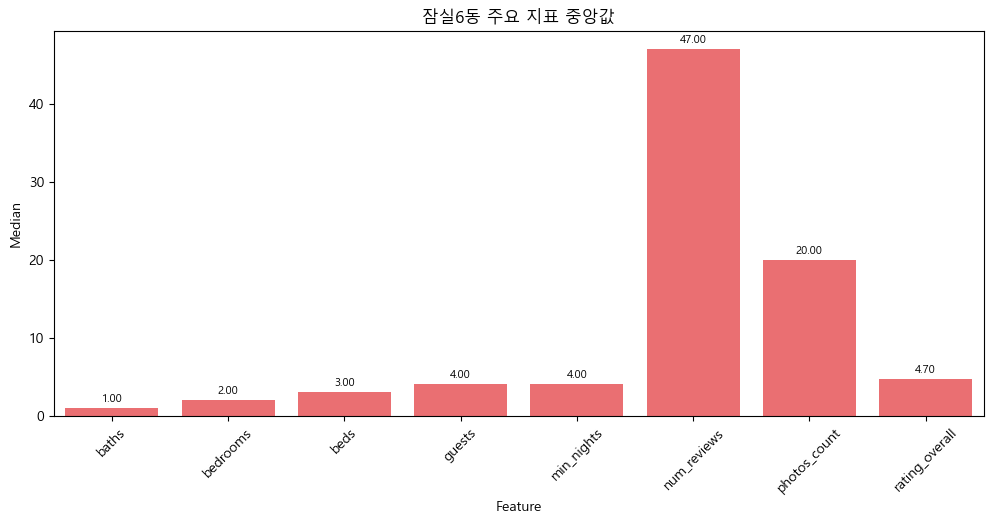

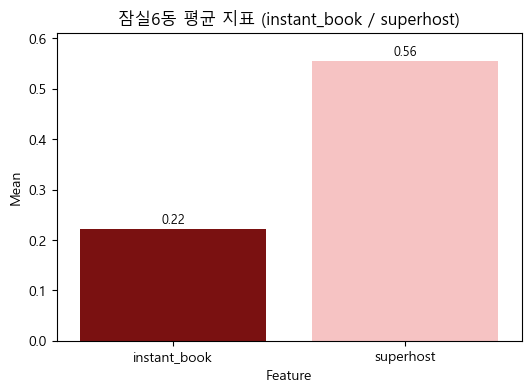

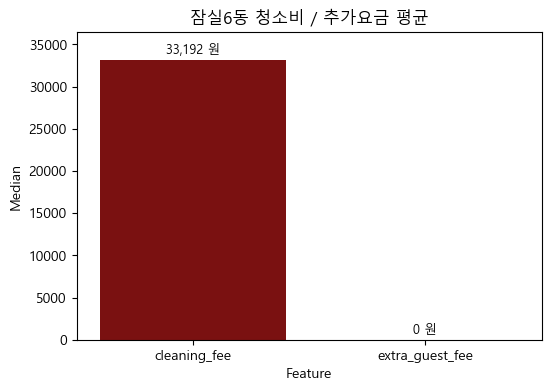

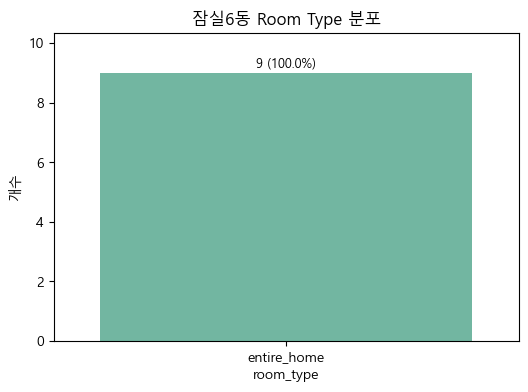

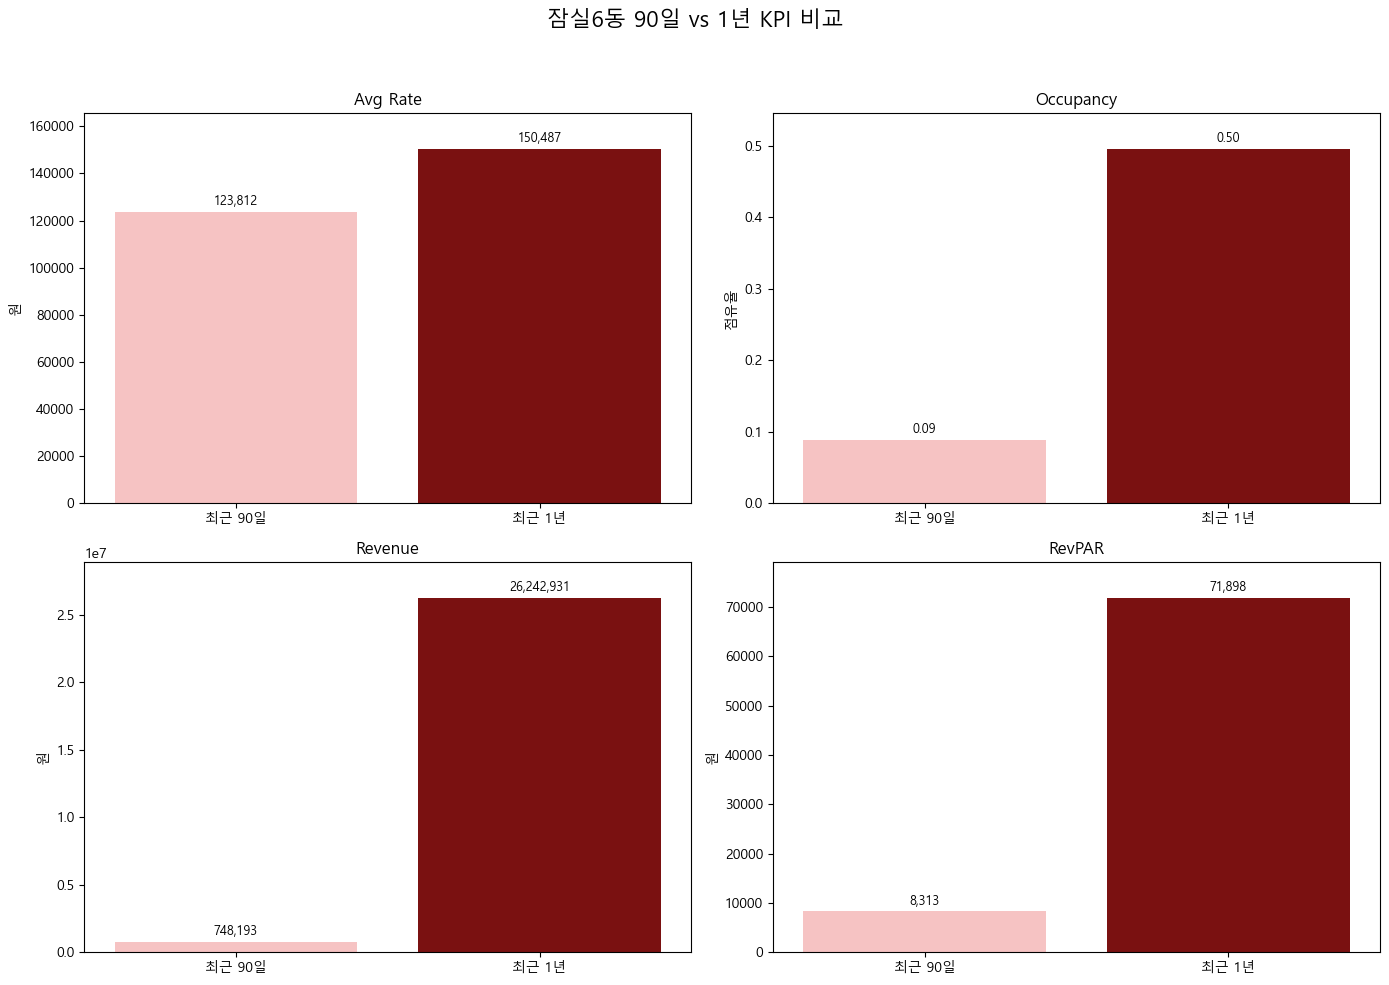

In [ ]:
airbnb_dong_summary(recommand_dong_list[0])

---

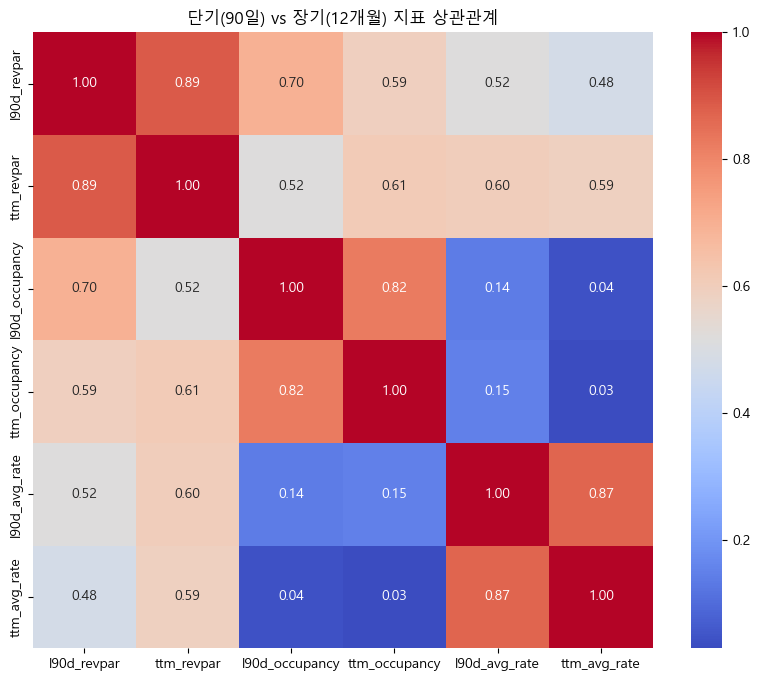

In [ ]:
compare_cols = [
    ('l90d_revpar', 'ttm_revpar'),
    ('l90d_occupancy', 'ttm_occupancy'),
    ('l90d_avg_rate', 'ttm_avg_rate')
]

# 1. 상관관계 계산
correlations = gdf_airbnb_active_dong[[c for pair in compare_cols for c in pair]].corr()

# 2. 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("단기(90일) vs 장기(12개월) 지표 상관관계")
plt.show()

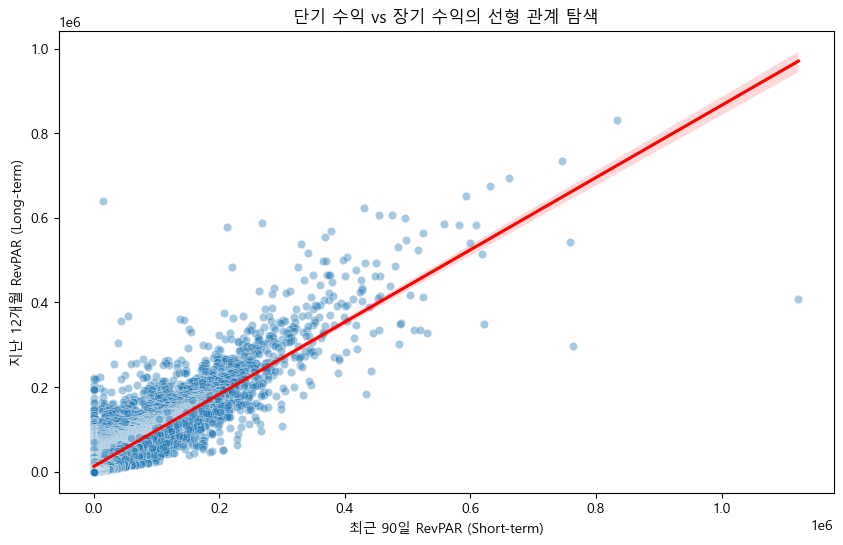

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=gdf_airbnb_active_dong, x='l90d_revpar', y='ttm_revpar', alpha=0.4)

# 추세선 추가
sns.regplot(data=gdf_airbnb_active_dong, x='l90d_revpar', y='ttm_revpar', scatter=False, color='red')

plt.title("단기 수익 vs 장기 수익의 선형 관계 탐색")
plt.xlabel("최근 90일 RevPAR (Short-term)")
plt.ylabel("지난 12개월 RevPAR (Long-term)")
plt.show()

In [ ]:
# 성과 차이 계산 (최근 90일 성과가 1년 평균보다 얼마나 높거나 낮은지)
# 90일 수익이 1년 평균 수익(ttm/12 * 3개월치와 단순비교는 어려우므로 비율로 계산)
gdf_airbnb_performance = gdf_airbnb_active_dong.copy()
gdf_airbnb_performance['performance_ratio'] = gdf_airbnb_performance['l90d_revpar'] / (gdf_airbnb_performance['ttm_revpar'] / 4)

def categorize_performance(row):
    # 상위 25% 등을 기준으로 임계치 설정 가능
    ttm_median = gdf_airbnb_performance['ttm_revpar'].median()
    l90d_median = gdf_airbnb_performance['l90d_revpar'].median()

    if row['ttm_revpar'] > ttm_median and row['l90d_revpar'] > l90d_median:
        return 'Stable Giant (꾸준한 고수익)'
    elif row['ttm_revpar'] <= ttm_median and row['l90d_revpar'] > l90d_median:
        return 'Rising Star (최근 급성장)'
    elif row['ttm_revpar'] > ttm_median and row['l90d_revpar'] <= l90d_median:
        return 'Fading Star (최근 하락세)'
    else:
        return 'Underperformer (정체)'

gdf_airbnb_performance['market_status'] = gdf_airbnb_performance.apply(categorize_performance, axis=1)

# 행정동별 마켓 상태 분포 확인
status_by_dong = gdf_airbnb_performance.groupby(['행정동', 'market_status']).size().unstack().fillna(0)
status_by_dong.head()

market_status,Fading Star (최근 하락세),Rising Star (최근 급성장),Stable Giant (꾸준한 고수익),Underperformer (정체)
행정동,,,,
가락1동,0.00,0.00,2.00,3.00
가락2동,0.00,0.00,2.00,4.00
가락본동,0.00,0.00,8.00,8.00
가리봉동,1.00,2.00,0.00,10.00
가산동,1.00,2.00,3.00,14.00


In [ ]:
# 비중으로 변경
status_pct = status_by_dong.div(status_by_dong.sum(axis=1), axis=0) * 100
status_pct.head()

market_status,Fading Star (최근 하락세),Rising Star (최근 급성장),Stable Giant (꾸준한 고수익),Underperformer (정체)
행정동,,,,
가락1동,0.00,0.00,40.00,60.00
가락2동,0.00,0.00,33.33,66.67
가락본동,0.00,0.00,50.00,50.00
가리봉동,7.69,15.38,0.00,76.92
가산동,5.00,10.00,15.00,70.00


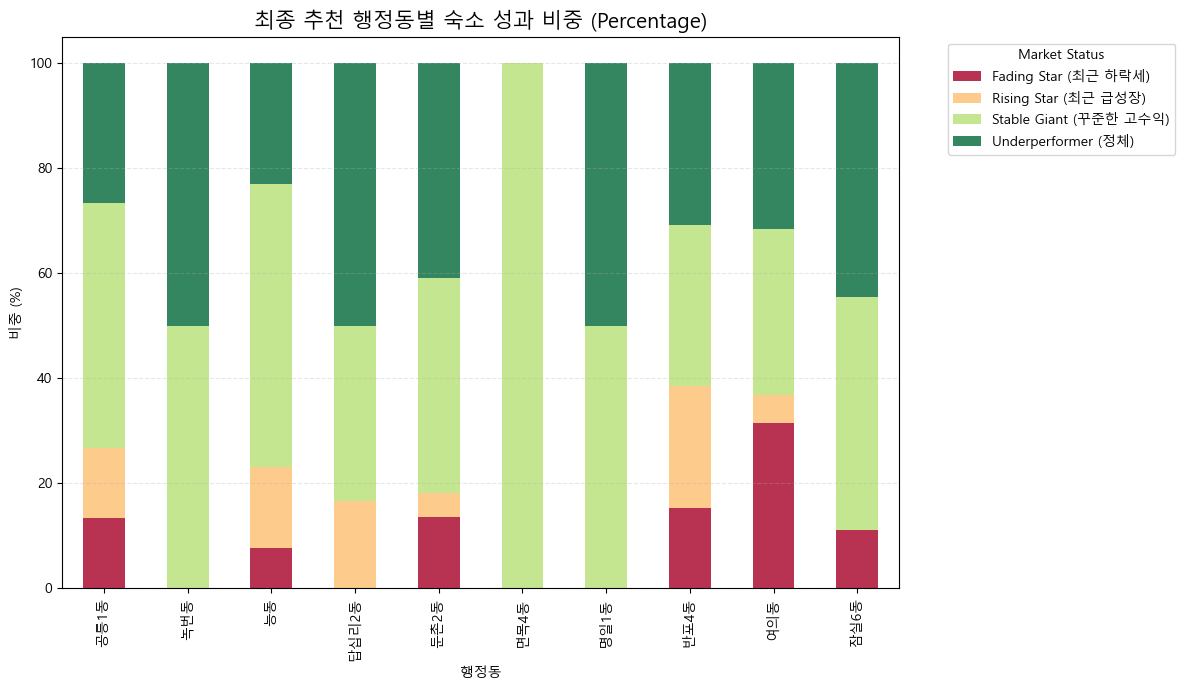

In [ ]:
# 1. 추천 동네의 '비율' 데이터만 추출
recommand_pct = status_pct.loc[status_pct.index.isin(recommand_dong_list)]

# 2. 시각화 (비율 기반 누적 막대 그래프)
recommand_pct.plot(kind='bar',
                  stacked=True, # 누적형으로 변경
                  figsize=(12, 7),
                  colormap='RdYlGn', # 성과에 어울리는 색상 (Green: 고수익, Red: 정체)
                  alpha=0.8)

plt.title('최종 추천 행정동별 숙소 성과 비중 (Percentage)', fontsize=15)
plt.xlabel('행정동')
plt.ylabel('비중 (%)')
plt.legend(title='Market Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================
# (최종발표 버전) 레버카드 생성 + 추천동(recommand_dong_list)만 남기기
#
# A. 레버카드(동 전략 카드)
#   - priority_raw = |effect| × |gap|
#   - priority_norm = (|effect|/denom) × (|gap|/denom)  (TOP3 랭킹용, 단위/스케일 보정)
#   - 권장 액션 문장(↑/↓): target - current(=delta)로 방향 결정
#   - 운영레버 vs 가격/정책(ADR, 청소비) 섹션 분리
#   - 기준선: 구 내부 상위 25%(q=0.75) 고정
#
# B. 출력: dong_cards_recommended / dong_recommended_cards_5179.gpkg
# ============================

import numpy as np
import pandas as pd
from pathlib import Path

# ---- 안전장치: 추천 동 리스트(recommand_dong_list) 존재 확인
if "recommand_dong_list" not in globals():
    raise NameError("recommand_dong_list 변수가 없습니다. (Step4 추천 동 산출 셀을 먼저 실행하세요.)")

# (전체) 효과/기준선 산출용: 구 내부 전체 리스팅
df_all = gdf_airbnb_active_dong.copy()

required = ["district", "행정동", "ttm_revpar"]
missing = [c for c in required if c not in df_all.columns]
if missing:
    raise KeyError(f"레버카드 산출에 필요한 컬럼이 없습니다: {missing}")

# (출력 대상) 추천 동만 카드 생성
target_dongs = set(recommand_dong_list)
df_target = df_all[df_all["행정동"].isin(target_dongs)].copy()

if df_target.empty:
    raise ValueError("recommand_dong_list로 필터링했더니 데이터가 비었습니다. (동 이름/컬럼명 확인 필요)")

# ---- 파라미터(팀 합의 고정)
Q = 0.75  # 구 내부 상위 25% 기준

# ---- priority 정규화 방식 선택(발표 방어용)
#  - "iqr" : 구 내부 '동 단위 분포 폭(IQR)'로 정규화(robust, 권장)
#  - "denom": target/current 규모로 비율 정규화(간단, 기존 적용)
#  - "raw"  : |effect|×|gap| (단위 혼합 위험, 비권장)
PRIORITY_METHOD = "iqr"

# ---- 지표 설정
# op(운영/품질 레버): TOP3 선정 대상
OP_METRICS = [
    # key, src_col, agg, is_rate, unit, label, up_verb, down_verb
    ("instant_rate",   "instant_book",   "mean",   True,  "%",  "즉시예약 사용률", "높이세요", "낮추세요"),
    ("superhost_rate", "superhost",      "mean",   True,  "%",  "슈퍼호스트 비율", "높이세요", "낮추세요"),
    ("min_nights_med", "min_nights",     "median", False, "박", "최소박수",        "늘리세요", "줄이세요"),
    ("photos_med",     "photos_count",   "median", False, "장", "사진 수",         "늘리세요", "줄이세요"),
    ("reviews_med",    "num_reviews",    "median", False, "개", "리뷰 수",         "늘리세요", "줄이세요"),
    ("rating_med",     "rating_overall", "median", False, "점", "평점",            "올리세요", "낮추세요"),
]

# price/policy(가격/정책): 섹션 분리(Top3 선정 제외)
PRICE_METRICS = [
    ("adr_med",        "ttm_avg_rate",   "median", False, "원", "1박 평균요금(ADR)", "올리세요", "내리세요"),
    ("clean_fee_med",  "cleaning_fee",   "median", False, "원", "청소비",            "올리세요", "내리세요"),
]

def _agg(s: pd.Series, how: str):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if s.empty:
        return np.nan
    if how == "mean":
        return float(s.mean())
    if how == "median":
        return float(s.median())
    raise ValueError(how)

def _fmt_value(v, is_rate=False, unit=""):
    if pd.isna(v):
        return "-"
    if is_rate:
        return f"{v*100:.0f}{unit}"
    if unit == "원":
        return f"{int(round(v)):,}{unit}"
    # 점/박/개/장 등
    if unit in ["점"]:
        return f"{v:.2f}{unit}"
    return f"{int(round(v))}{unit}"

# ---- 1) 구(district)별: 상위집단 target + effect 계산
district_effects = {}   # {district: {metric_key: effect}}
district_targets = {}   # {district: {metric_key: target}}

for dist, g in df_all.groupby("district"):
    # 구 내부 RevPAR 상위 25% 기준
    thr = pd.to_numeric(g["ttm_revpar"], errors="coerce").dropna().quantile(Q)
    top = g[pd.to_numeric(g["ttm_revpar"], errors="coerce") >= thr]
    rest = g[pd.to_numeric(g["ttm_revpar"], errors="coerce") < thr]

    effects = {}
    targets = {}

    for key, src, agg, is_rate, unit, label, upv, downv in OP_METRICS + PRICE_METRICS:
        if src not in g.columns:
            continue

        t = _agg(top[src], agg)
        r = _agg(rest[src], agg)

        # target = 상위집단의 전형(평균/중앙값)
        targets[key] = t

        # effect = (상위집단 - 나머지집단) : 방향/강도
        if pd.isna(t) or pd.isna(r):
            effects[key] = np.nan
        else:
            effects[key] = float(t - r)

    district_targets[dist] = targets
    district_effects[dist] = effects

# ---- (사전계산) 구 내부 분포 폭(IQR) 기반 정규화 스케일
# dong 단위(= 행정동 집계값) 분포로 IQR을 계산해,
# '이 구에서 이 정도 차이가 얼마나 이례적인지'를 반영합니다.
# (표본이 적으면 IQR이 불안정할 수 있어 eps 바닥값 적용)
EPS = 1e-9

# 1) 구-동 단위 current(집계값) 테이블 생성
_rows = []
for dist, g in df_all.groupby("district"):
    for dong, gd in g.groupby("행정동"):
        row = {"district": dist, "행정동": dong}
        for key, col, agg, *_ in (OP_METRICS + PRICE_METRICS):
            if col not in gd.columns:
                row[key] = np.nan
            else:
                row[key] = _agg(gd[col], agg)
        _rows.append(row)

dong_current_all = pd.DataFrame(_rows)

# 2) (district, metric_key) -> IQR 저장
district_metric_iqr = {}
for dist, g in dong_current_all.groupby("district"):
    d = {}
    for key, *_ in (OP_METRICS + PRICE_METRICS):
        s = pd.to_numeric(g[key], errors="coerce").dropna()
        if len(s) < 4:
            d[key] = np.nan
        else:
            d[key] = float(s.quantile(0.75) - s.quantile(0.25))
    district_metric_iqr[dist] = d


# ---- 2) 동별: current + priority 계산 후 카드 생성(추천 동만)
cards = []

for dong, g_d in df_target.groupby("행정동"):
    dist = g_d["district"].iloc[0]

    # KPI(표시용)
    revpar_med = _agg(g_d["ttm_revpar"], "median") if "ttm_revpar" in g_d.columns else np.nan
    occ_med = _agg(g_d["ttm_occupancy"], "median") if "ttm_occupancy" in g_d.columns else np.nan
    adr_med = _agg(g_d["ttm_avg_rate"], "median") if "ttm_avg_rate" in g_d.columns else np.nan

    # ---- 운영레버: priority 산출
    ops_rows = []
    for key, src, agg, is_rate, unit, label, upv, downv in OP_METRICS:
        if src not in g_d.columns:
            continue
        target = district_targets.get(dist, {}).get(key, np.nan)
        eff = district_effects.get(dist, {}).get(key, np.nan)
        cur = _agg(g_d[src], agg)

        if pd.isna(target) or pd.isna(cur) or pd.isna(eff):
            continue

        gap = float(target - cur)  # 방향

        # priority_raw: 스펙 정의 그대로(|effect|×|gap|) — 단위가 섞일 수 있음(원/장/박/% 등)
        priority_raw = abs(float(eff)) * abs(gap)

        # priority_norm(denom): target/current 규모로 비율 정규화(무차원)
        denom = max(abs(float(target)), abs(float(cur)), 1e-9)
        effect_norm = abs(float(eff)) / denom
        gap_norm = abs(gap) / denom
        priority_norm = effect_norm * gap_norm

        # priority_iqr(robust): 구 내부 '동 단위 분포 폭(IQR)'로 정규화
        iqr = district_metric_iqr.get(dist, {}).get(key, np.nan)
        use_iqr = (not pd.isna(iqr)) and (float(iqr) > EPS)
        if use_iqr:
            denom_iqr = float(iqr)
            effect_iqr = abs(float(eff)) / denom_iqr
            gap_iqr = abs(gap) / denom_iqr
            priority_iqr = effect_iqr * gap_iqr
        else:
            denom_iqr = np.nan
            effect_iqr = np.nan
            gap_iqr = np.nan
            priority_iqr = np.nan

        # TOP3 선정 기준(기본: IQR, 불가하면 denom으로 자동 fallback)
        if PRIORITY_METHOD == "iqr":
            priority = priority_iqr if use_iqr else priority_norm
        elif PRIORITY_METHOD == "denom":
            priority = priority_norm
        elif PRIORITY_METHOD == "raw":
            priority = priority_raw
        else:
            raise ValueError(f"Unknown PRIORITY_METHOD: {PRIORITY_METHOD}")
        # 권장 액션 문장(↑/↓)
        if gap > 0:
            action = upv
            arrow = "↑"
        elif gap < 0:
            action = downv
            arrow = "↓"
        else:
            action = "유지"
            arrow = "→"

        ops_rows.append({
            "key": key,
            "label": label,
            "current": cur,
            "target": target,
            "gap": gap,
            "effect": eff,
            "priority": priority,
            "priority_raw": priority_raw,
            "priority_norm": priority_norm,
            "denom": denom,
            "effect_norm": effect_norm,
            "gap_norm": gap_norm,
            "priority_iqr": priority_iqr,
            "denom_iqr": denom_iqr,
            "effect_iqr": effect_iqr,
            "gap_iqr": gap_iqr,
            "priority_method": PRIORITY_METHOD,
            "action": action,
            "arrow": arrow,
            "is_rate": is_rate,
            "unit": unit,
        })

    ops_df = pd.DataFrame(ops_rows)
    if not ops_df.empty:
        ops_df = ops_df.sort_values("priority", ascending=False).head(3).reset_index(drop=True)

    # ---- 가격/정책 힌트(Top3 선정 제외, 존재할 때만)
    price_lines = []
    for key, src, agg, is_rate, unit, label, upv, downv in PRICE_METRICS:
        if src not in g_d.columns:
            continue
        target = district_targets.get(dist, {}).get(key, np.nan)
        cur = _agg(g_d[src], agg)
        eff = district_effects.get(dist, {}).get(key, np.nan)

        if pd.isna(target) or pd.isna(cur) or pd.isna(eff):
            continue

        delta = float(target - cur)
        if delta > 0:
            arrow = "↑"; verb = upv
        elif delta < 0:
            arrow = "↓"; verb = downv
        else:
            arrow = "→"; verb = "유지"

        price_lines.append(
            f"- {label}: {arrow} {verb} ({_fmt_value(cur, False, unit)} → {_fmt_value(target, False, unit)})"
        )

    # ---- 카드 텍스트 생성
    kpi_lines = []
    if not pd.isna(revpar_med):
        kpi_lines.append(f"RevPAR(중앙값): {_fmt_value(revpar_med, False, '원')}")
    if not pd.isna(occ_med):
        kpi_lines.append(f"점유율(중앙값): {_fmt_value(occ_med, True, '%')}")
    if not pd.isna(adr_med):
        kpi_lines.append(f"ADR(중앙값): {_fmt_value(adr_med, False, '원')}")

    ops_lines = []
    if not ops_df.empty:
        for i, r in ops_df.iterrows():
            cur_s = _fmt_value(r["current"], r["is_rate"], r["unit"])
            tgt_s = _fmt_value(r["target"], r["is_rate"], r["unit"])
            ops_lines.append(f"{i+1}) {r['label']} {r['arrow']} {r['action']} ({cur_s} → {tgt_s})")
    else:
        ops_lines.append("운영 레버: 데이터 부족(표본/컬럼)으로 산출 불가")

    card_text = "\n".join([
        f"[{dong}] ({dist})",
        f"• " + " / ".join(kpi_lines) if kpi_lines else "• KPI: -",
        "",
        "✅ 운영 레버 TOP3 (관측 기반)",
        *ops_lines,
        "",
        "💲 가격/정책 힌트 (관측 기반)",
        *(price_lines if price_lines else ["- ADR/청소비: 데이터 없음 또는 산출 불가"]),
    ])

    # QGIS Map Tip용 HTML(간단 버전)
    html_ops = "<br>".join([f"{line}" for line in ops_lines])
    html_price = "<br>".join([ln.replace("- ","") for ln in price_lines]) if price_lines else "ADR/청소비: 데이터 없음 또는 산출 불가"
    html_kpi = " / ".join(kpi_lines) if kpi_lines else "-"

    card_html = f"""
    <div style="font-family: Malgun Gothic, AppleGothic, NanumGothic, sans-serif; font-size: 12px;">
      <div style="font-weight:700; font-size:14px; margin-bottom:6px;">{dong} <span style="font-weight:400;">({dist})</span></div>
      <div style="margin-bottom:8px;">• {html_kpi}</div>
      <div style="font-weight:700; margin-bottom:4px;">✅ 운영 레버 TOP3 (관측 기반)</div>
      <div style="margin-bottom:8px;">{html_ops}</div>
      <div style="font-weight:700; margin-bottom:4px;">💲 가격/정책 힌트 (관측 기반)</div>
      <div>{html_price}</div>
    </div>
    """

    cards.append({
        "district": dist,
        "dong": dong,
        "card_text": card_text,
        "card_html": card_html,
        "ops1": ops_df["label"].iloc[0] if (not ops_df.empty and len(ops_df)>=1) else None,
        "ops2": ops_df["label"].iloc[1] if (not ops_df.empty and len(ops_df)>=2) else None,
        "ops3": ops_df["label"].iloc[2] if (not ops_df.empty and len(ops_df)>=3) else None,
    })

dong_cards_recommended = pd.DataFrame(cards).sort_values(["district","dong"]).reset_index(drop=True)
display(dong_cards_recommended.head(5))

# ---- 3) 추천동만 지도/레이어로 남기기: 폴리곤(gdf) + 카드 merge 후 export
gdf_candidates = ["dong_stats", "dong_gdf", "gdf_dong_5179"]
gdf_dong_base = None
for name in gdf_candidates:
    if name in globals():
        gdf_dong_base = globals()[name]
        break
if gdf_dong_base is None:
    raise NameError(f"행정동 폴리곤 GeoDataFrame을 찾지 못했습니다. 후보: {gdf_candidates}")

# 컬럼명 정리: dong 컬럼이 'dong'인지 확인
if "dong" not in gdf_dong_base.columns:
    raise KeyError("행정동 폴리곤(gdf)에서 'dong' 컬럼을 찾지 못했습니다.")

gdf_dong_recommended = (
    gdf_dong_base[gdf_dong_base["dong"].isin(target_dongs)]
    .merge(dong_cards_recommended, on=["district","dong"], how="left")
)

# 저장 경로
OUT = Path(OUT)  # 기존 OUT 재사용
final_dir = OUT / "final_presentation"
final_dir.mkdir(exist_ok=True)

# 저장(지도 레이어)
gdf_dong_recommended.to_file(final_dir / "dong_recommended_cards_5179.gpkg", driver="GPKG")
dong_cards_recommended.to_csv(final_dir / "dong_cards_recommended.csv", index=False, encoding="utf-8-sig")

print("✅ Saved:")
print("-", final_dir / "dong_recommended_cards_5179.gpkg")
print("-", final_dir / "dong_cards_recommended.csv")


,district,dong,card_text,card_html,ops1,ops2,ops3
0,강동구,둔촌2동,"[둔촌2동] (강동구)\n• RevPAR(중앙값): 34,428원 / 점유율(중앙값...","\n <div style=""font-family: Malgun Gothic, ...",사진 수,리뷰 수,평점
1,강동구,명일1동,"[명일1동] (강동구)\n• RevPAR(중앙값): 56,437원 / 점유율(중앙값...","\n <div style=""font-family: Malgun Gothic, ...",사진 수,리뷰 수,슈퍼호스트 비율
2,광진구,능동,"[능동] (광진구)\n• RevPAR(중앙값): 40,606원 / 점유율(중앙값):...","\n <div style=""font-family: Malgun Gothic, ...",슈퍼호스트 비율,사진 수,리뷰 수
3,노원구,공릉1동,"[공릉1동] (노원구)\n• RevPAR(중앙값): 45,770원 / 점유율(중앙값...","\n <div style=""font-family: Malgun Gothic, ...",리뷰 수,슈퍼호스트 비율,즉시예약 사용률
4,동대문구,답십리2동,"[답십리2동] (동대문구)\n• RevPAR(중앙값): 29,310원 / 점유율(중...","\n <div style=""font-family: Malgun Gothic, ...",리뷰 수,사진 수,평점


✅ Saved:
- c:\Users\paris\Desktop\sparta_python\최종프로젝트(260202_260313)\outputs_최종\final_presentation\dong_recommended_cards_5179.gpkg
- c:\Users\paris\Desktop\sparta_python\최종프로젝트(260202_260313)\outputs_최종\final_presentation\dong_cards_recommended.csv


- 태블로에 사용하기 위해 card_text 컬럼 분리 후 csv 파일로 저장

In [ ]:
# =========================
# Tableau용 카드 데이터 구조화
# =========================

rows = []

for dong, g_d in df_target.groupby("행정동"):

    dist = g_d["district"].iloc[0]

    # KPI
    revpar_med = _agg(g_d["ttm_revpar"], "median") if "ttm_revpar" in g_d.columns else np.nan
    occ_med = _agg(g_d["ttm_occupancy"], "median") if "ttm_occupancy" in g_d.columns else np.nan
    adr_med = _agg(g_d["ttm_avg_rate"], "median") if "ttm_avg_rate" in g_d.columns else np.nan

    # =========================
    # 운영 레버 계산
    # =========================

    ops_rows = []

    for key, src, agg, is_rate, unit, label, upv, downv in OP_METRICS:

        if src not in g_d.columns:
            continue

        target = district_targets.get(dist, {}).get(key, np.nan)
        eff = district_effects.get(dist, {}).get(key, np.nan)
        cur = _agg(g_d[src], agg)

        if pd.isna(target) or pd.isna(cur) or pd.isna(eff):
            continue

        gap = float(target - cur)

        denom = max(abs(float(target)), abs(float(cur)), 1e-9)
        effect_norm = abs(float(eff)) / denom
        gap_norm = abs(gap) / denom
        priority = effect_norm * gap_norm

        if gap > 0:
            action = upv
            direction = "up"
        elif gap < 0:
            action = downv
            direction = "down"
        else:
            action = "유지"
            direction = "same"

        ops_rows.append({
            "metric": label,
            "current": cur,
            "target": target,
            "gap": gap,
            "effect": eff,
            "priority": priority,
            "action": action,
            "direction": direction
        })

    ops_df = pd.DataFrame(ops_rows)

    if not ops_df.empty:
        ops_df = ops_df.sort_values("priority", ascending=False).head(3).reset_index(drop=True)

    # =========================
    # 기본 row 생성
    # =========================

    row = {
        "district": dist,
        "dong": dong,
        "revpar_med": revpar_med,
        "occ_med": occ_med,
        "adr_med": adr_med
    }

    # =========================
    # TOP3 운영 전략
    # =========================

    for i in range(3):

        if i < len(ops_df):

            r = ops_df.iloc[i]

            row[f"ops{i+1}_metric"] = r["metric"]
            row[f"ops{i+1}_current"] = r["current"]
            row[f"ops{i+1}_target"] = r["target"]
            row[f"ops{i+1}_gap"] = r["gap"]
            row[f"ops{i+1}_effect"] = r["effect"]
            row[f"ops{i+1}_priority"] = r["priority"]
            row[f"ops{i+1}_action"] = r["action"]
            row[f"ops{i+1}_direction"] = r["direction"]

        else:

            row[f"ops{i+1}_metric"] = None
            row[f"ops{i+1}_current"] = None
            row[f"ops{i+1}_target"] = None
            row[f"ops{i+1}_gap"] = None
            row[f"ops{i+1}_effect"] = None
            row[f"ops{i+1}_priority"] = None
            row[f"ops{i+1}_action"] = None
            row[f"ops{i+1}_direction"] = None

    # =========================
    # 💰 가격 / 정책 힌트 추가
    # =========================

    for key, src, agg, is_rate, unit, label, upv, downv in PRICE_METRICS:

        if src not in g_d.columns:
            continue

        target = district_targets.get(dist, {}).get(key, np.nan)
        cur = _agg(g_d[src], agg)

        if pd.isna(target) or pd.isna(cur):
            continue

        gap = float(target - cur)

        if gap > 0:
            action = upv
            direction = "up"
        elif gap < 0:
            action = downv
            direction = "down"
        else:
            action = "유지"
            direction = "same"

        if key == "adr_med":

            row["adr_current"] = cur
            row["adr_target"] = target
            row["adr_gap"] = gap
            row["adr_action"] = action
            row["adr_direction"] = direction

        if key == "clean_fee_med":

            row["cleanfee_current"] = cur
            row["cleanfee_target"] = target
            row["cleanfee_gap"] = gap
            row["cleanfee_action"] = action
            row["cleanfee_direction"] = direction

    rows.append(row)

# =========================
# DataFrame 생성
# =========================

tableau_cards = pd.DataFrame(rows)

display(tableau_cards.head())

# =========================
# 저장
# =========================

tableau_cards.to_csv(
    OUT / "tableau_dong_recommend_strategy_cards.csv",
    index=False,
    encoding="utf-8-sig"
)

print("✅ Tableau용 데이터 저장 완료")
print(OUT / "tableau_dong_recommend_strategy_cards.csv")

,district,dong,revpar_med,occ_med,adr_med,ops1_metric,ops1_current,ops1_target,ops1_gap,ops1_effect,...,adr_current,adr_target,adr_gap,adr_action,adr_direction,cleanfee_current,cleanfee_target,cleanfee_gap,cleanfee_action,cleanfee_direction
0,노원구,공릉1동,45770.00,0.48,79794.25,리뷰 수,47.00,90.00,43.00,68.00,...,79794.25,81195.77,1401.52,올리세요,up,1383.00,9681.00,8298.00,올리세요,up
1,은평구,녹번동,30011.50,0.34,118581.47,즉시예약 사용률,0.00,0.28,0.28,0.11,...,118581.47,134701.50,16120.04,올리세요,up,33883.00,19362.00,-14521.00,내리세요,down
2,광진구,능동,40606.40,0.43,81513.59,사진 수,19.00,40.00,21.00,18.00,...,81513.59,133254.07,51740.48,올리세요,up,0.00,23511.00,23511.00,올리세요,up
3,동대문구,답십리2동,29309.65,0.37,58637.20,리뷰 수,21.00,45.50,24.50,34.50,...,58637.20,99482.11,40844.90,올리세요,up,18670.50,23511.00,4840.50,올리세요,up
4,강동구,둔촌2동,34427.85,0.38,87262.40,사진 수,21.00,44.00,23.00,19.00,...,87262.40,128795.71,41533.31,올리세요,up,19362.00,29043.00,9681.00,올리세요,up


✅ Tableau용 데이터 저장 완료
c:\Users\paris\Desktop\sparta_python\최종프로젝트(260202_260313)\outputs_최종\tableau_dong_recommend_strategy_cards.csv


In [ ]:
tableau_cards.columns

Index(['district', 'dong', 'revpar_med', 'occ_med', 'adr_med', 'ops1_metric',
       'ops1_current', 'ops1_target', 'ops1_gap', 'ops1_effect',
       'ops1_priority', 'ops1_action', 'ops1_direction', 'ops2_metric',
       'ops2_current', 'ops2_target', 'ops2_gap', 'ops2_effect',
       'ops2_priority', 'ops2_action', 'ops2_direction', 'ops3_metric',
       'ops3_current', 'ops3_target', 'ops3_gap', 'ops3_effect',
       'ops3_priority', 'ops3_action', 'ops3_direction', 'adr_current',
       'adr_target', 'adr_gap', 'adr_action', 'adr_direction',
       'cleanfee_current', 'cleanfee_target', 'cleanfee_gap',
       'cleanfee_action', 'cleanfee_direction'],
      dtype='object')

---

## 추가 머신러닝

In [ ]:
gdf_airbnb_active_dong[['X좌표(WGS84)', 'Y좌표(WGS84)']]

,X좌표(WGS84),Y좌표(WGS84)
0,126.92,37.57
1,126.99,37.56
2,126.99,37.58
3,127.04,37.55
4,126.99,37.58
...,...,...
19995,127.01,37.59
19996,126.93,37.56
19997,127.02,37.59
19998,127.02,37.59


In [ ]:
dong_stats[['tour_attraction_score', 'stay_competition_score', 'airbnb_score',
           'subway_people_score', 'transfer_station_comb_score']]

,tour_attraction_score,stay_competition_score,airbnb_score,subway_people_score,transfer_station_comb_score
0,0.59,1.00,0.43,0.00,0.21
1,0.92,0.71,0.33,0.76,0.48
2,0.77,1.00,0.43,0.00,0.26
3,0.39,0.88,0.67,0.00,0.27
4,0.18,0.94,0.86,0.00,0.14
...,...,...,...,...,...
420,0.23,0.79,0.62,0.54,0.33
421,0.00,1.00,0.53,0.00,0.37
422,0.00,0.82,0.54,0.91,0.64
423,0.00,0.62,0.43,0.74,0.39


In [ ]:
cols = ['district', 'dong', 'tour_attraction_score', 'stay_competition_score',
        'airbnb_score', 'subway_people_score', 'transfer_station_comb_score']

df = gdf_airbnb_active_dong.merge(
    dong_stats[cols],
    left_on=['district', '행정동'],
    right_on=['district', 'dong'],
    how='left'
)
df

,index,baths,bedrooms,beds,cleaning_fee,country,currency,extra_guest_fee,guests,instant_book,...,rating_overall_filled,segment,index_right,행정동,dong,tour_attraction_score,stay_competition_score,airbnb_score,subway_people_score,transfer_station_comb_score
0,0,6.00,10,10,345745,South Korea,KRW,0,16,False,...,5.00,High-Performing,184,연희동,연희동,0.34,0.90,0.41,0.00,0.31
1,1,6.00,10,10,345745,South Korea,KRW,0,16,False,...,5.00,High-Performing,20,필동,필동,0.37,0.40,0.26,0.55,0.33
2,2,3.00,3,4,117553,South Korea,KRW,0,7,True,...,4.98,High-Performing,7,가회동,가회동,1.00,1.00,0.24,0.00,0.51
3,3,2.00,2,2,38723,South Korea,KRW,0,4,False,...,5.00,High-Performing,100,응봉동,응봉동,0.00,1.00,0.63,0.77,0.57
4,4,1.00,2,2,37340,South Korea,KRW,0,4,False,...,4.92,High-Performing,8,종로1·2·3·4가동,종로1·2·3·4가동,0.88,0.15,0.24,0.69,0.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19998,1.00,1,1,0,South Korea,KRW,0,1,False,...,4.33,Other,143,삼선동,삼선동,0.00,0.72,0.42,0.65,0.53
19996,19999,0.00,0,1,49787,South Korea,KRW,0,0,False,...,4.90,Other,183,신촌동,신촌동,0.45,0.35,0.21,0.42,0.33
19997,20000,1.00,1,1,0,South Korea,KRW,0,1,False,...,4.86,Other,143,삼선동,삼선동,0.00,0.72,0.42,0.65,0.53
19998,20001,0.00,0,1,0,South Korea,KRW,0,0,False,...,4.33,Other,32,동선동,동선동,0.00,0.36,0.39,0.71,0.49


In [ ]:
#### ML 1단계: 숙소 단위 가격(평균 일일 요금) 예측을 위한 데이터 준비

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# 1) 사용할 베이스 DataFrame (이미 위에서 만든 gdf_airbnb_active_dong 재사용)
#   - 최종 행정동 추천에 활용한 파생변수를 활용해 행정동별 숙소 성과와 관련된 요소를 추가해 행정동 지역 특성을 반영함으로써 행정동을 대신함.
cols = ['district', 'dong', 'tour_attraction_score', 'stay_competition_score',
        'airbnb_score', 'subway_people_score', 'transfer_station_comb_score']

df = gdf_airbnb_active_dong.merge(
    dong_stats[cols],
    left_on=['district', '행정동'],
    right_on=['district', 'dong'],
    how='left'
)
df

# 2) 타깃: 최근 90일 평균 요금 (ttm_revpar)
#    - 만약 결측이 있으면 제거
target_col = "ttm_revpar"
df = df[df[target_col].notnull()].copy()

# 3) 피처 후보 목록 정의
#    - "우리가 미리 알 수 있거나 설정 가능한 것" 위주로 선택
#    - 아래에서 실제 컬럼명에 맞게 일부 수정해도 됨
numeric_features = ['baths_w',
                    'bedrooms_w',
                    'beds_w',
                    'guests',
                    'min_nights_w',
                    'cleaning_fee_w',
                    'extra_guest_fee_w',
                    'photos_count_w',
                    'X좌표(WGS84)', 'Y좌표(WGS84)'
                    ]

# 행정동은 사용하지 않음. 400개가 넘어 one-hot 인코딩 하면 컬럼이 너무 많음.
# 'superhost'
categorical_features = [
    "district",       # 자치구
    'room_type',
    "instant_book"
]

derivative_features = ['tour_attraction_score', 'stay_competition_score',
        'airbnb_score', 'subway_people_score', 'transfer_station_comb_score']

# 실제 존재하는 컬럼만 필터링 (오타/누락 방지용)
numeric_features = [col for col in numeric_features if col in df.columns]
categorical_features = [col for col in categorical_features if col in df.columns]

# 만약 운영하는 숙소라면 'num_reviews_w', 'superhost', 'rating_overall'을 포함하여 학습 가능
print("사용할 수치형 피처:", numeric_features)
print("사용할 범주형 피처:", categorical_features)
print("사용할 파생변수 피처:", derivative_features)

사용할 수치형 피처: ['baths_w', 'bedrooms_w', 'beds_w', 'guests', 'min_nights_w', 'cleaning_fee_w', 'extra_guest_fee_w', 'photos_count_w', 'X좌표(WGS84)', 'Y좌표(WGS84)']
사용할 범주형 피처: ['district', 'room_type', 'instant_book']
사용할 파생변수 피처: ['tour_attraction_score', 'stay_competition_score', 'airbnb_score', 'subway_people_score', 'transfer_station_comb_score']


In [ ]:
# 1) 로그 변환을 적용할 피처 리스트
log_features = [
    'baths_w', 'bedrooms_w', 'beds_w', 'guests',
    'min_nights_w', 'cleaning_fee_w', 'extra_guest_fee_w', 'photos_count_w'
]

# 2) 데이터프레임 복사본 생성 후 변환 (np.log1p는 log(1+x)로 0값 처리 가능)
df_log = df.copy()
for col in log_features:
    if col in df_log.columns:
        df_log[col] = np.log1p(df_log[col])

# 이후 기존 코드(X, y 나누기) 진행
X = df_log[numeric_features + categorical_features + derivative_features]
y = np.log1p(df_log[target_col])


In [ ]:
#### ML 2단계: train/test 분할 및 전처리 + 모델 파이프라인 정의

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import pandas as pd

# 1) train/test 분할
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 2) 전처리 파이프라인
# 정규화
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# 첫번째 범주를 삭제해 다중공선성 방지(누락된 하나의 범주는 나머지 전체로 설명 가능)
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

# numeric_features + derivative_features 모두 수치형 처리
all_numeric_features = numeric_features + derivative_features

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, all_numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# 모델 세팅
# 1) 모델 리스트 정의 (Ridge 대신 LinearRegression 투입)
models = [
    ("LinearRegression", LinearRegression()),
    ("RandomForestRegressor", RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, min_samples_leaf=2)),
    ("XGBoost", XGBRegressor(n_estimators=100, learning_rate=0.3, random_state=42, n_jobs=-1))
]

# 2) 결과 저장 및 학습
results = []
trained_pipelines = {} # 나중에 계수나 중요도를 뽑기 위해 저장

for name, reg in models:
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("regressor", reg)
    ])

    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline # 모델 저장

    y_pred_log = pipeline.predict(X_test)

    # 로그 단위를 원래 '원' 단위로 복원하기 (Inverse Transform)
    y_test_orig = np.expm1(y_test)       # 실제값 복원
    y_pred_orig = np.expm1(y_pred_log)   # 예측값 복원

    # 실제 '원' 단위로 MAE, r2 계산
    # MAE: 평균 절대 오차 → 예측이 평균적으로 얼마만큼 실제 값과 차이 나는가?
    mae = mean_absolute_error(y_test_orig, y_pred_orig)
    r2 = r2_score(y_test_orig, y_pred_orig)

    results.append({"Model": name, "MAE": mae, "R2": r2})
    print(f"{name} - MAE: {mae:,.0f}원, R2: {r2:.4f}")

# 결과 비교 표
result_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
result_df

LinearRegression - MAE: 28,049원, R2: 0.2614
RandomForestRegressor - MAE: 24,071원, R2: 0.4630
XGBoost - MAE: 24,386원, R2: 0.4604


,Model,MAE,R2
1,RandomForestRegressor,24071.00,0.46
2,XGBoost,24385.84,0.46
0,LinearRegression,28048.78,0.26


In [ ]:
#### ML 3단계: 모델 선정 및 fine-tuning

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder

# 전처리기 정의 (OrdinalEncoder 적용)
# 자치구(district)를 쪼개지 않고 하나의 컬럼으로 유지.
numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer = Pipeline(steps=[
    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, all_numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# 1. 1등 모델(RandomForest)을 담은 단일 파이프라인 정의
model = Pipeline(steps=[
    ("preprocessor", preprocessor), # 아까 만든 전처리기 그대로 재사용
    ("regressor", RandomForestRegressor(random_state=42, n_jobs=-1)) # 튜닝할 거라 파라미터는 비워둠
])

# 1) 튜닝할 하이퍼파라미터 범위 정의
param_dist = {
    'regressor__n_estimators': [200, 300, 500],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_leaf': [2, 4],
    'regressor__max_features': ['sqrt', 'log2', 1.0] # 과적합 방지용 피처개수 선정
}

# # 2) RandomizedSearchCV 설정
# # n_iter=10은 10번의 랜덤 조합만 테스트한다는 뜻 (시간 절약)
# random_search = RandomizedSearchCV(
#     model,
#     param_distributions=param_dist,
#     n_iter=10,
#     cv=5, # 5-fold 교차 검증
#     scoring='r2',
#     n_jobs=-1,
#     random_state=42
# )
grid_search = GridSearchCV(
    model, # 사용자님의 파이프라인
    param_grid=param_dist, # 파라미터 그리드 (이름만 바뀜)
    cv=5,
    scoring='r2',
    n_jobs=-1 # 내 컴퓨터의 모든 CPU를 사용해서 속도 향상
)

# 3) 학습(최적의 파라미터로 자동 재학습함.)
# random_search.fit(X_train, y_train)
grid_search.fit(X_train, y_train)

# 4) 최적 모델 평가 및 원래 단위(원) 복구
# best_model = random_search.best_estimator_
best_model = grid_search.best_estimator_
y_pred_log = best_model.predict(X_test)

# 로그 -> 원화 단위 복구 (Inverse Transform)
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred_log)

mae = mean_absolute_error(y_test_orig, y_pred_orig)
r2 = r2_score(y_test_orig, y_pred_orig)

print(f"--- 최적화 결과 ---")
# print(f"최적 파라미터: {random_search.best_params_}")
print(f"최적 파라미터: {grid_search.best_params_}")
print(f"최고 R2 점수: {grid_search.best_score_:.4f}")
print(f"테스트 데이터 최종 MAE: {mae:,.0f}원")
print(f"테스트 데이터 최종 R2: {r2:.4f}")

--- 최적화 결과 ---
최적 파라미터: {'regressor__max_depth': None, 'regressor__max_features': 'sqrt', 'regressor__min_samples_leaf': 2, 'regressor__n_estimators': 500}
최고 R2 점수: 0.4980
테스트 데이터 최종 MAE: 23,936원
테스트 데이터 최종 R2: 0.4607


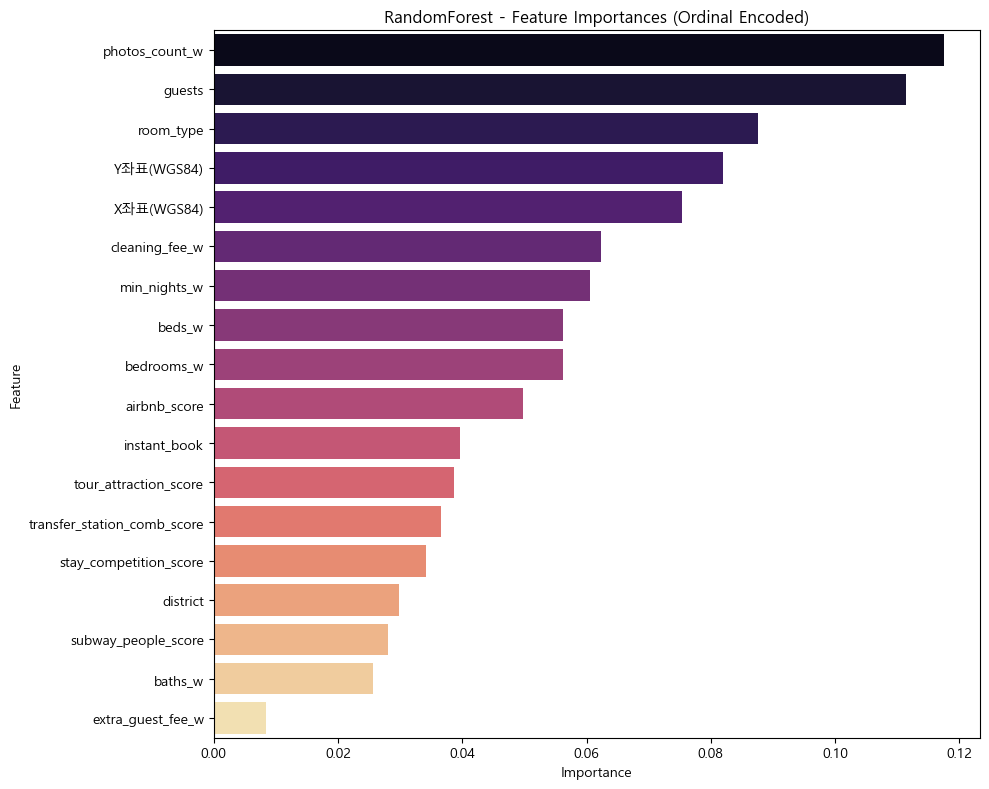

In [ ]:
# 변수 중요도(Feature Importance) 시각화
# Ordinal Encoding 덕분에 피처 이름이 그대로 유지됨.
importances = best_model.named_steps['regressor'].feature_importances_
feature_names = all_numeric_features + categorical_features

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='magma')
plt.title("RandomForest - Feature Importances (Ordinal Encoded)")
plt.tight_layout()
plt.show()

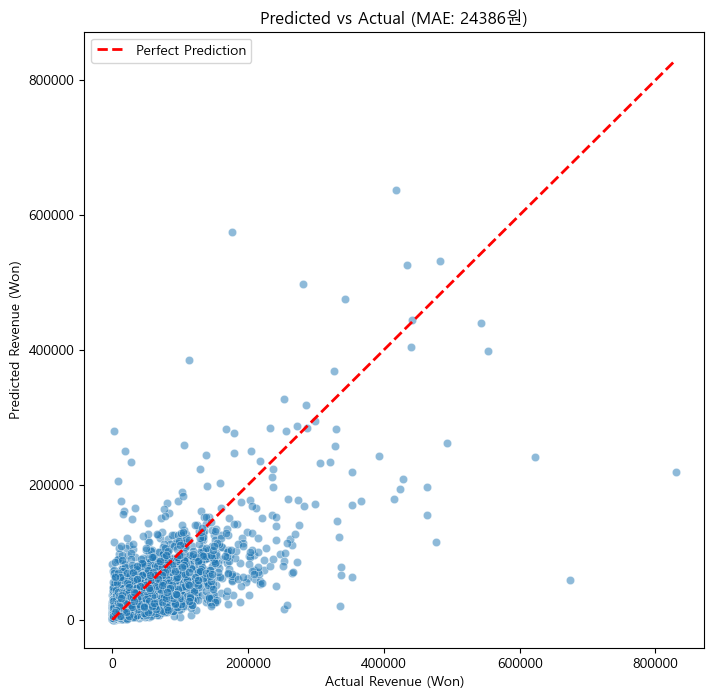

In [ ]:
plt.figure(figsize=(8, 8))
# 실제값(y_test_orig)과 예측값(y_pred_orig) 비교
sns.scatterplot(x=y_test_orig, y=y_pred_orig, alpha=0.5)
# 완벽한 예측을 의미하는 대각선 추가
plt.plot([y_test_orig.min(), y_test_orig.max()],
         [y_test_orig.min(), y_test_orig.max()],
         'r--',
         lw=2,
         label="Perfect Prediction")ㅁㅁ

plt.xlabel("Actual Revenue (Won)")
plt.ylabel("Predicted Revenue (Won)")
plt.title(f"Predicted vs Actual (MAE: {mae:.0f}원)")
plt.legend()
plt.show()

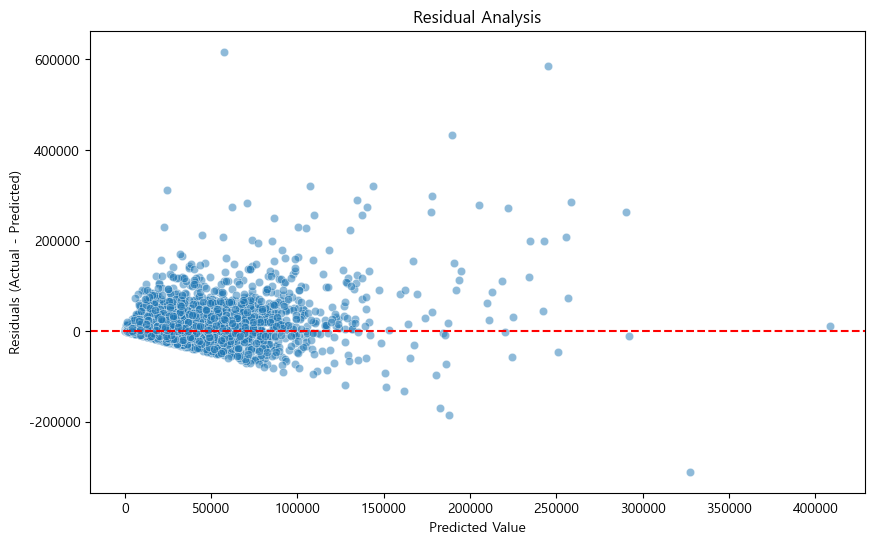

In [ ]:
residuals = y_test_orig - y_pred_orig

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_orig, y=residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--') # 오차 0인 선
plt.xlabel("Predicted Value")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Analysis")
plt.show()

In [ ]:
#### 특정 행정동 숙소 수익 예측 시뮬레이션
target_dong = '둔촌2동'

# 2. 원본 df에서 해당 동네인 인덱스들을 가져옴
dong_indices_in_df = df[df['dong'] == target_dong].index

# 3. 그 중에서 X_test에도 존재하는 인덱스만 골라냄 (교집합)
# X_test.index에 있는 번호들 중, df에서 찾은 '명동' 번호가 있는지 확인하는 과정입니다.
target_test_indices = X_test.index.intersection(dong_indices_in_df)

if len(target_test_indices) == 0:
    print(f"⚠️ 이런! X_test 세트에는 '{target_dong}' 데이터가 포함되지 않습니다.")

else:
    # 4. 후보 중 첫 번째 숙소를 선택
    sample_idx = target_test_indices[1]
    print(f"✅ {target_dong} 숙소 발견! 인덱스 번호: {sample_idx}")

    # 5. X_test에서 해당 인덱스의 피처 데이터 한 줄 추출
    single_listing_x = X_test.loc[[sample_idx]]

    print(f"\n--- [숙소 주요 피처 정보] ---")

    # 출력할 피처 리스트 (중요도 순으로 나열하면 더 좋습니다)
    features_to_show = all_numeric_features + categorical_features
    # 원본 df에서 해당 인덱스의 피처 값들만 가져오기
    display_info = df.loc[sample_idx, features_to_show]

    # 보기 좋게 한 줄씩 출력
    for feature, value in display_info.items():
        # 수치형 데이터는 소수점 정리, 문자열은 그대로 출력
        if isinstance(value, float):
            print(f"- {feature}: {value:,.2f}")
        else:
            print(f"- {feature}: {value}")

    # 6. 시뮬레이션: 현재 상태 그대로 예측해보기
    pred_log = best_model.predict(single_listing_x)
    pred_won = np.expm1(pred_log)[0]

    # 실제 수익(정답) 확인
    actual_won = np.expm1(y_test.loc[sample_idx])

    print(f"\n--- [{target_dong}] 숙소 시뮬레이션 결과 ---")
    print(f"실제 숙소 일평균 수익: {actual_won:,.0f}원")
    print(f"모델 예측: {pred_won:,.0f}원")
    print(f"오차: {abs(actual_won - pred_won):,.0f}원")

✅ 둔촌2동 숙소 발견! 인덱스 번호: 4836

--- [숙소 주요 피처 정보] ---
- baths_w: 1.00
- bedrooms_w: 2.00
- beds_w: 2.00
- guests: 6
- min_nights_w: 1.00
- cleaning_fee_w: 29,043.00
- extra_guest_fee_w: 0.00
- photos_count_w: 110.00
- X좌표(WGS84): 127.14
- Y좌표(WGS84): 37.53
- tour_attraction_score: 0.23
- stay_competition_score: 0.79
- airbnb_score: 0.62
- subway_people_score: 0.54
- transfer_station_comb_score: 0.33
- district: 강동구
- room_type: entire_home
- instant_book: True

--- [둔촌2동] 숙소 시뮬레이션 결과 ---
실제 숙소 일평균 수익: 66,529원
모델 예측: 55,547원
오차: 10,981원


In [ ]:
df.columns

Index(['index', 'baths', 'bedrooms', 'beds', 'cleaning_fee', 'country',
       'currency', 'extra_guest_fee', 'guests', 'instant_book',
       'l90d_avg_rate', 'l90d_occupancy', 'l90d_revenue', 'l90d_revpar',
       'listing_type', 'locality', 'min_nights', 'num_reviews', 'photos_count',
       'rating_overall', 'region', 'room_type', 'superhost', 'ttm_avg_rate',
       'ttm_occupancy', 'ttm_revenue', 'ttm_revpar', 'district', 'X좌표(WGS84)',
       'Y좌표(WGS84)', 'X좌표(GRS80TM)', 'Y좌표(GRS80TM)', 'geometry', 'baths_w',
       'bedrooms_w', 'beds_w', 'min_nights_w', 'cleaning_fee_w',
       'extra_guest_fee_w', 'num_reviews_w', 'photos_count_w',
       'l90d_avg_rate_w', 'l90d_revenue_w', 'l90d_revpar_w', 'ttm_avg_rate_w',
       'ttm_revenue_w', 'ttm_revpar_w', 'log_cleaning_fee',
       'log_extra_guest_fee', 'log_num_reviews', 'log_photos_count',
       'log_l90d_avg_rate', 'log_l90d_revenue', 'log_l90d_revpar',
       'log_ttm_avg_rate', 'log_ttm_revenue', 'log_ttm_revpar',
       'rati

### 수익 극대화는 **'입지의 특성을 이해한 최적의 숙소 세팅'**에서 나옴
"입지 선정의 중요성"
- 모델은 단순 구 이름(district)보다 교통 및 인구 지표를 수익 예측의 더 중요한 단서로 포착함. 이는 자치구보다 '실질적 인프라'에 더 큰 영향을 받는 것을 입증함.
- 위도·경도 좌표값이 중요도 상위권(3, 4위)에 포진했다는 점은 그만큼 숙소의 위치가 중요하다는 뜻

"운영 지표와 입지 지표의 시너지"
- 설명: "숙소 자체 지표(사진수, 최대 허용인원)가 1, 2위를 차지하고 그 뒤를 정밀 입지(좌표) - 숙소 지표 - 인프라(파생변수)가 받쳐주고 있음."
- 결과: 입지는 호스트가 숙소를 계약하는 순간 결정되는 **'상수'**이다. 입지 선정 후 숙소의 규모를 결정하는 최대허용 게스트와 방 타입은 숙소 시작전 전략적으로 결정할 수 있으며 이는 성공적인 에어비앤비 시작의 기본이 된다. 이후 사진 개수, 청소 요금 등 호스트가 언제든 개선할 수 있는 **'변수'**를 통해 수익의 상한선을 높일 수 있다. 해당 모델은 **'이미 결정된 상수(입지) 위에서, 수익을 극대화하기 위해 호스트가 통제할 수 있는 변수(운영)를 어떻게 최적화해야 하는가'**에 대한 답을 주고 있다.

1위 photos_count_w
- 온라인 마케팅의 힘: 게스트는 숙소의 실물을 보기 전 '사진'으로만 가치를 판단함. 사진이 많을수록 정보의 투명성이 높아지고 신뢰도가 상승해 수익(RevPAR)으로 직결됨.

2위 guests
- 규모의 경제: 수용 가능 인원이 많을수록 단가가 높아짐. 서울 시장에서 '다인원 수용 가능 숙소'가 수익 창출에 있어 매우 강력한 변별력을 가짐을 뜻함.

3~4위 위도/경도
- 초정밀 입지: 입지의 영향을 많이 받는다.

## 질의응답
1. 레버카드 지표 산출 시 priority 계산하실 때 기존에는 effect가 음수인 경우 제외하셨는데 effect가 얼마나 영향력이 큰지를 나타내는 지표이니 절대값으로 해야하지 않을까?
->
- effect = (상위 25%) - (나머지 75%) 는 **영향력의 크기 + 방향(부호)**를 같이 갖는 값입니다.
- **추천 우선순위(priority)는 “얼마나 크게 차이 나는가”**가 핵심이므로 |effect|로 계산해야 합니다.
- 대신 **액션 방향(올릴지/내릴지)**은 effect 부호(또는 target-current의 부호)로 결정해야 합니다.

최종 반영 규칙:
- delta = target - current (양수면 “증가”, 음수면 “감소”)
- priority = |effect| * |delta|
- 이렇게 하면 effect<0인 레버도 **“감소 방향 액션”**으로 정상 추천됩니다.

2. 레버카드 산출하실 때 ttm_avg_rate 랑 cleaning_fee도 추가하면 좋을 것 같습니다.
->
- ttm_avg_rate(ADR)는 “성과지표”이면서 동시에 가격 정책의 결과라서 완전한 레버로 단정은 금지지만,
- 카드에서 “가격(ADR)이 상위집단에서 더 높은/낮은 패턴”을 보여주는 건 충분히 가치가 있습니다.
- cleaning_fee는 명확한 정책 레버라 카드에 넣기 좋습니다.
- 구현에서는 컬럼이 존재할 때만 자동 포함되게 처리해야 합니다(데이터셋마다 cleaning_fee가 없을 수 있음).

3. opportunity_score 산출하실 때 가중치를 어떻게 하느냐에 따라서 최종 결과 행정동도 다르게 나와 추가로 수정하셔도 됩니다.
->
- 가중치 바꾸면 행정동 결과가 바뀌는 건 정상입니다.
- 그래서 “한 번 정하면 끝”이 아니라 가중치 파라미터를 노출하고, 발표/보고서 방어를 위해 민감도(sensitivity) 결과를 같이 저장하는 게 맞습니다.

권장 운영 방식:

- 기본(base): 성과 0.5 / 경쟁 0.3 / 운영 0.2

- 비교 시나리오 3개 정도만 추가:

- perf_heavy / comp_heavy / ops_heavy
- 각 시나리오에서 Top N이 얼마나 흔들리는지 표로 남겨서 “결과 안정성”을 보여주면 깔끔합니다.

4. (참고) 교통 점수를 기존에 교통편의 밀도 점수에서 환승역 밀도를 추가해 7:3 비율로 가중치를 줘서 점수를 재 산정한 뒤 step2에서 필터링 했습니다.
->
- transfer_station_comb_score = 0.7*transport_score + 0.3*subway_trans_score

Step2 필터 예시:

- 교통(환승결합) 상위 30% 이상 통과
- (있다면) 유동인구 점수는 “하위 20%만 아니면” 통과(유령동네 제거)
- 전제: 이걸 적용하려면 동 단위 데이터에 transport_score, subway_trans_score (옵션으로 subway_people_score) 컬럼이 실제로 있어야 합니다.
- 없으면 계산/필터는 자동으로 스킵되는 게 안전합니다.

아래 문구는 **레버카드/가격정책 파트에서 인과 오해를 막기 위한 “고정 템플릿”**입니다.  
(대시보드 툴팁/리포트 본문/발표 멘트에 동일하게 사용 권장)

- ✅ **“성과 상위 집단에서 더 자주 관측되는 운영 패턴이다(관측 기반).”**
- ✅ **“동일 구 내 비교로 지역빨을 일부 제거했지만, 인과는 단정하지 않는다.”**
- ✅ **“가격/청소비는 정책 변수이지만, 수요/경쟁/후기 등 복합 요인의 결과이기도 하다.”**

가중치 민감도(TopN) 파트 표준 문구:
- ✅ **“가중치가 바뀌면 TopN이 바뀌는 것은 정상이다.”**
- ✅ **“그래서 baseline + 3개 시나리오(perf/comp/ops heavy)에서 Top10 변동 폭을 표로 함께 제시한다.”**

Step2(교통) 필터 표준 문구:
- ✅ **“발표 버전에서는 강한 상위 컷을 피하고, 교통 결합 점수 하위 20%만 제거하는 안전한 필터를 사용했다.”**

-----------------------------------------정규화 정리-------------------------------------------

1) priority_raw (스펙 원형)

- 정규화 없는 원형은 다음입니다.
- priority_raw = |effect| × |gap|
- 문제점은 잘 아시듯이 지표 단위가 섞이면(원/장/박/%), 숫자 범위 큰 지표가 TOP3를 먹을 수 있다는 것입니다.

2) priority_norm(denom) — “수준(규모) 기반 비율 정규화”

- 이건무차원 비율화입니다.
- denom = max(|target|, |current|, eps)
- effect_norm = |effect| / denom
- gap_norm = |gap| / denom
- priority_norm = effect_norm × gap_norm

이 방식이 의미하는 것
- “이 지표가 현재 수준 대비 얼마나 차이 나는가(상대 차이)”를 봅니다.
- 구 내부 비교는 유지하되, **스케일을 ‘해당 지표의 값 크기’(수준)**로 맞춥니다.

장단점
- 장점: 단순/설명 쉬움/표본 적어도 잘 돌아감
- 단점: 그 구에서 원래 변동이 큰 지표인지 작은 지표인지(분포 폭)를 반영하지는 못함

3) priority_iqr(robust) — “구 내부 분포 폭(IQR) 기반 정규화”

이게 말씀하신 “IQR 방식”이고, TOP3 기본 기준입니다(불가 시 denom으로 fallback).

(1) 구별 IQR을 어떻게 잡는가? (중요)

- “리스팅 단위”가 아니라 동 단위(current 집계값) 분포로 IQR을 잡습니다.
- 먼저 구 안의 모든 동에 대해, 각 지표의 current(mean/median)를 만들고
- 그 동 단위 current 값들의 분포에서
- IQR = Q3 - Q1 를 계산합니다.
- 즉 “강남구에서 즉시예약율은 동들 사이에 보통 얼마나 벌어지나?” 같은 **구 내부 변동성(폭)**을 분모로 쓰는 겁니다.

(2) IQR 정규화 수식

- effect_iqr = |effect| / IQR
- gap_iqr = |gap| / IQR
- priority_iqr = effect_iqr × gap_iqr

(3) 언제 fallback 되나?
- IQR은 표본/분포가 빈약하면 불안정합니다.
- 해당 구에서 그 지표의 동 표본이 너무 적음(예: < 4)
- IQR이 너무 작거나 0에 가까움 (IQR <= EPS)
- 그래서 상위 문제가 생겼을 경우 IQR을 쓰지 않고 자동으로 denom으로 대체합니다.

이 방식이 의미하는 것
- “이 지표에서의 effect/gap이 그 구에서 흔한 변동 폭(IQR) 대비 얼마나 큰가?”
- → 즉 ‘이례성/강도’ 중심입니다.

장단점

- 장점: 단위 문제 해결 + 구마다 ‘원래 흔들리는 정도’가 다르다는 현실을 반영(robust)
- 단점: IQR이 작은 지표(거의 고정값, 이진 변수 등)는 값이 튈 수 있어 fallback/클램핑이 필요

4) 퍼센타일(순위) 정규화와의 차이

- effect_pct = pct_rank(|effect| within 구)
- gap_pct = pct_rank(|gap| within 구)
- priority_pct = effect_pct × gap_pct

퍼센타일의 본질
- “위치(순서)”만 남기고 거리(크기)를 버립니다.
- 그래서 “TopN 안정성 비교” 같은 방어표에는 좋지만,
- 레버카드가 목표/액션 크기를 말할 때는 ‘강도’가 뭉개져서 설득력이 떨어질 수 있음(사용자 판단 정확).

IQR vs 퍼센타일 핵심 차이
- 퍼센타일: “몇 등인가”
- IQR: “보통 변동 폭 대비 몇 배인가”
→ 크기 정보가 더 살아있음

5) denom vs IQR 방식

- denom 정규화: “수준(값 크기) 대비 얼마나 차이나?”
- IQR 정규화: “그 구에서 흔한 변동 폭 대비 얼마나 이례적이야?”

둘은 같은 정규화가 아니라, 서로 다른 질문에 답하는 스케일링입니다.

6) 추천 운영 방식(발표/Q&A 방어까지)

- TOP3 선정: priority_iqr (기본)
- IQR 불안정이면 자동으로 priority_norm로 fallback → “안정성” 확보
- 카드에 보여주는 수치: current → target은 원단위 그대로(액션 크기 전달)
- 필요하면 부록/디버그로 priority_raw/priority_norm/priority_iqr를 같이 남겨서 “정규화해도 결론이 크게 안 바뀐다” 방어 가능